# HiEn-TriDistillIE — Compact 2-Teacher, 3-Teacher, and 4-Teacher Notebook

This compact notebook keeps **one selected configuration for each teacher count** instead of including every teacher combination.

- **2-teacher:** MuRIL (Hindi) + BioBERT (English) → IndicBERTv2 student
- **3-teacher:** MuRIL (Hindi) + BioBERT + PubMedBERT (English) → IndicBERTv2 student (**T11_3**)
- **4-teacher:** MuRIL + XLM-R (Hindi) + BioBERT + XLM-R (English) → IndicBERTv2 student (**T12_5 / robust four-teacher setting**)

The heavy training cells preserve the original experimental code but their old outputs are cleared. A compact **Final Results** section is included near the top with manuscript-reported values and ready-to-view plots. The summary-result cells are descriptive/reporting cells; they do not replace rerunning the training/evaluation pipeline.


## Final Results — Selected Configurations

The following cells summarize the final values used for the selected configurations. The first table reports the controlled point estimates. A second table reports the available repeated-seed robustness results for the selected 3-teacher and 4-teacher settings.


In [ ]:
import pandas as pd
from IPython.display import display

# Final controlled point estimates reported for the selected configurations.
# These values are included for convenient inspection and are not recomputed
# unless the corresponding training/evaluation cells are run.
controlled_results = pd.DataFrame([
    {"Setting":"2-teacher", "Selected teachers":"MuRIL / BioBERT", "HI NER Macro-F1":0.9416, "HI Accuracy":0.9310, "EN NER Macro-F1":0.4576, "EN Accuracy":0.8500, "RE Macro-F1":0.7374, "RE Accuracy":0.8400},
    {"Setting":"3-teacher", "Selected teachers":"MuRIL / BioBERT + PubMedBERT", "HI NER Macro-F1":0.9504, "HI Accuracy":0.9500, "EN NER Macro-F1":0.4502, "EN Accuracy":0.8600, "RE Macro-F1":0.7354, "RE Accuracy":0.8600},
    {"Setting":"4-teacher", "Selected teachers":"MuRIL + XLM-R / BioBERT + XLM-R", "HI NER Macro-F1":0.9716, "HI Accuracy":0.9600, "EN NER Macro-F1":0.4700, "EN Accuracy":0.8700, "RE Macro-F1":0.7244, "RE Accuracy":0.8500},
])
display(controlled_results)


Setting,Selected teachers,HI NER Macro-F1,HI Accuracy,EN NER Macro-F1,EN Accuracy,RE Macro-F1,RE Accuracy
2-teacher,MuRIL / BioBERT,0.9416,0.931,0.4576,0.85,0.7374,0.84
3-teacher,MuRIL / BioBERT + PubMedBERT,0.9504,0.950,0.4502,0.86,0.7354,0.86
4-teacher,MuRIL + XLM-R / BioBERT + XLM-R,0.9716,0.960,0.4700,0.87,0.7244,0.85


In [ ]:
# Repeated-seed robustness results for the selected 3-teacher and 4-teacher settings.
robustness_results = pd.DataFrame([
    {"Configuration":"3-teacher T11_3", "Seed":123, "HI NER Macro-F1":0.9687, "HI Accuracy":0.9681, "EN NER Macro-F1":0.4701, "EN Accuracy":0.8824, "RE Macro-F1":0.7360, "RE Accuracy":0.8609},
    {"Configuration":"3-teacher T11_3", "Seed":2026, "HI NER Macro-F1":0.9704, "HI Accuracy":0.9703, "EN NER Macro-F1":0.4702, "EN Accuracy":0.8827, "RE Macro-F1":0.7354, "RE Accuracy":0.8621},
    {"Configuration":"4-teacher T12_5", "Seed":123, "HI NER Macro-F1":0.9700, "HI Accuracy":0.9686, "EN NER Macro-F1":0.4709, "EN Accuracy":0.8824, "RE Macro-F1":0.7355, "RE Accuracy":0.8631},
    {"Configuration":"4-teacher T12_5", "Seed":2026, "HI NER Macro-F1":0.9761, "HI Accuracy":0.9756, "EN NER Macro-F1":0.4719, "EN Accuracy":0.8852, "RE Macro-F1":0.7427, "RE Accuracy":0.8687},
])
display(robustness_results)

summary = robustness_results.groupby('Configuration')[['HI NER Macro-F1','HI Accuracy','EN NER Macro-F1','EN Accuracy','RE Macro-F1','RE Accuracy']].agg(['mean','std'])
display(summary)


Configuration,Seed,HI NER Macro-F1,HI Accuracy,EN NER Macro-F1,EN Accuracy,RE Macro-F1,RE Accuracy
3-teacher T11_3,123,0.9687,0.9681,0.4701,0.8824,0.7360,0.8609
3-teacher T11_3,2026,0.9704,0.9703,0.4702,0.8827,0.7354,0.8621
4-teacher T12_5,123,0.9700,0.9686,0.4709,0.8824,0.7355,0.8631
4-teacher T12_5,2026,0.9761,0.9756,0.4719,0.8852,0.7427,0.8687


HI NER Macro-F1           HI Accuracy           EN NER Macro-F1           EN Accuracy           RE Macro-F1           RE Accuracy          
                           mean       std        mean       std            mean       std        mean       std        mean       std        mean       std
Configuration                                                                                                                                              
3-teacher T11_3         0.96955  0.001202      0.9692  0.001556         0.47015  0.000071     0.88255  0.000212      0.7357  0.000424      0.8615  0.000849
4-teacher T12_5         0.97305  0.004313      0.9721  0.004950         0.47140  0.000707     0.88380  0.001980      0.7391  0.005091      0.8659  0.003960

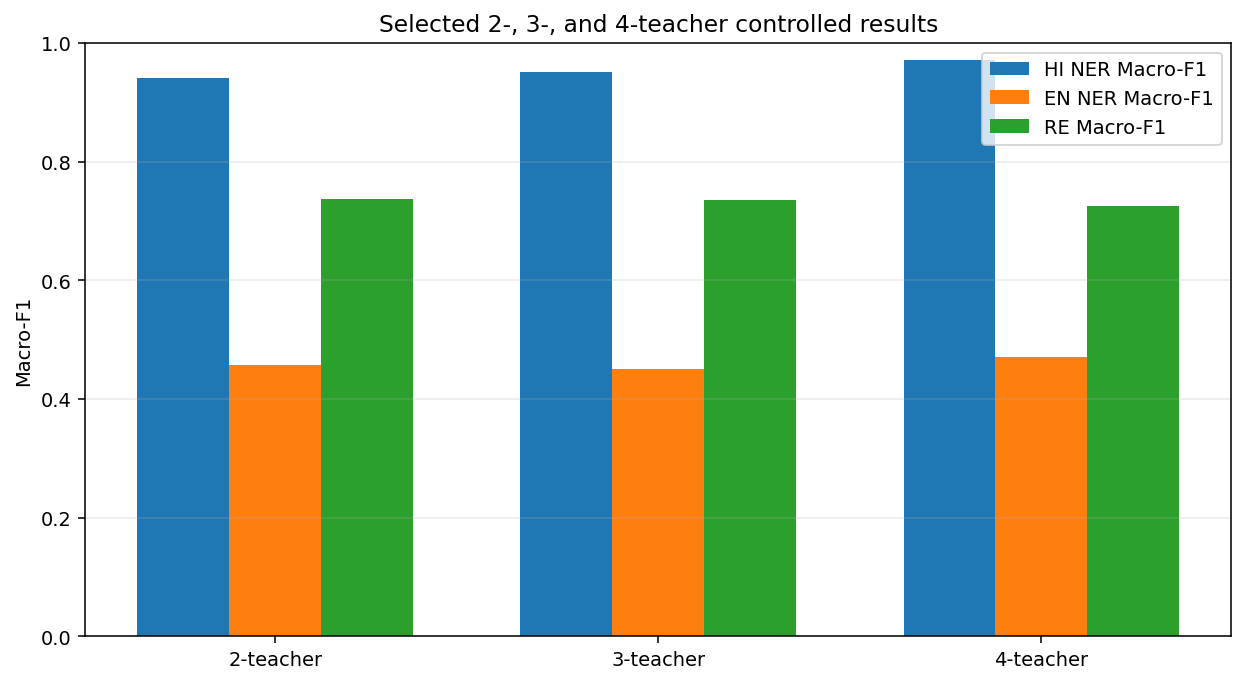

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

labels = controlled_results['Setting'].tolist()
x = np.arange(len(labels))
width = 0.24

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width, controlled_results['HI NER Macro-F1'], width, label='HI NER Macro-F1')
ax.bar(x, controlled_results['EN NER Macro-F1'], width, label='EN NER Macro-F1')
ax.bar(x + width, controlled_results['RE Macro-F1'], width, label='RE Macro-F1')
ax.set_ylabel('Macro-F1')
ax.set_title('Selected 2-, 3-, and 4-teacher controlled results')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.0)
ax.legend()
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()


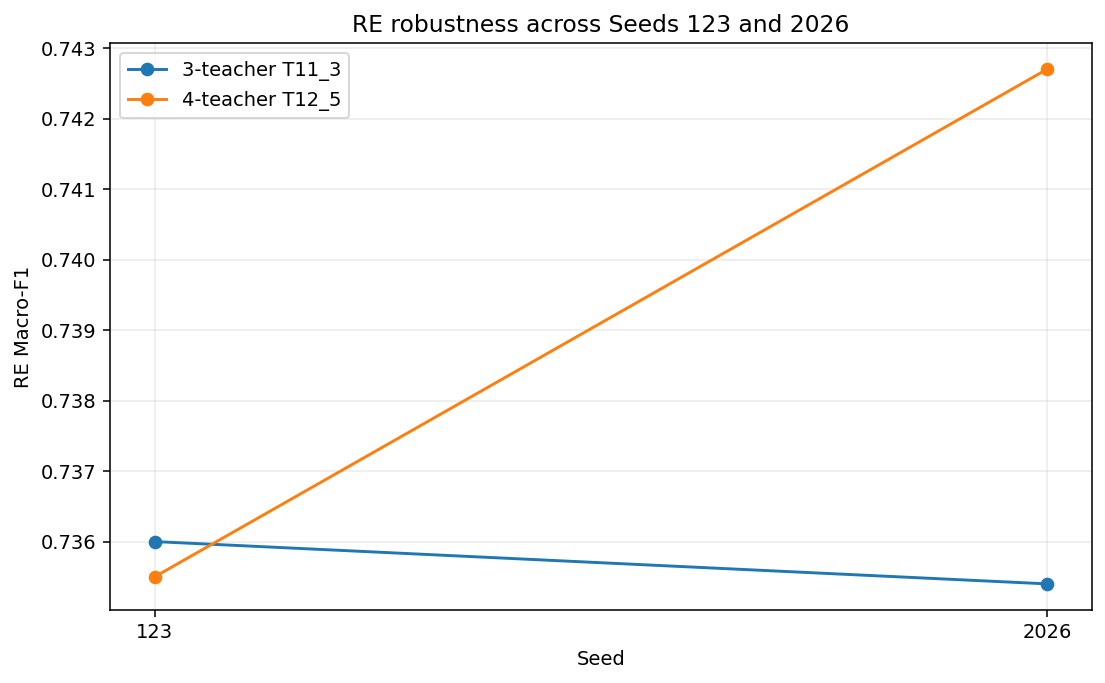

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
for config, group in robustness_results.groupby('Configuration'):
    group = group.sort_values('Seed')
    ax.plot(group['Seed'].astype(str), group['RE Macro-F1'], marker='o', label=config)
ax.set_xlabel('Seed')
ax.set_ylabel('RE Macro-F1')
ax.set_title('RE robustness across Seeds 123 and 2026')
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


---
## Extended Results and Diagnostic Analysis

This section adds compact result summaries and visual diagnostics for the selected **2-teacher, 3-teacher, and 4-teacher** experiments. It includes controlled cross-lingual comparisons, human-validated RE results, representation diagnostics, confusion matrices, t-SNE views, and the additional entity-level plots supplied with the experiment outputs.

### Cross-lingual controlled results

| Comparison          |   Reference |   Bilingual |   Difference_pp |
|:--------------------|------------:|------------:|----------------:|
| Hindi in-language   |      0.9616 |      0.9506 |         -1.1000 |
| English in-language |      0.8517 |      0.8521 |          0.0400 |
| HI_ONLY → English   |      0.6515 |      0.8521 |         20.0600 |
| EN_ONLY → Hindi     |      0.4574 |      0.9506 |         49.3200 |
| Human RE vs HI_ONLY |      0.5106 |      0.5754 |          6.4800 |
| Human RE vs EN_ONLY |      0.5710 |      0.5754 |          0.4300 |

### Representation diagnostics

| Metric                                     | Value   |
|:-------------------------------------------|:--------|
| Entity-type clustering (S_type)            | 0.6534  |
| Language clustering (S_lang)               | 0.098   |
| Semantic-language separation               | 0.5554  |
| Opposite-language top-1 type accuracy      | 96.10%  |
| Opposite-language top-5 type purity        | 95.95%  |
| Same-type HI-EN centroid cosine similarity | 0.7815  |
| Cross-language local-neighborhood mixing   | 0.22%   |

### Paired statistical checks

| Comparison                        | Test                    | Result            |
|:----------------------------------|:------------------------|:------------------|
| Human RE: Bilingual vs HI_ONLY    | McNemar p               | 0.0241            |
| Human RE: Bilingual vs EN_ONLY    | McNemar p               | 1.0               |
| Hindi NER: Bilingual vs HI_ONLY   | Paired-bootstrap 95% CI | [-1.49, -0.71] pp |
| English NER: Bilingual vs EN_ONLY | Paired-bootstrap 95% CI | [-0.46, 0.54] pp  |

**Interpretation.** The bilingual model substantially recovers performance relative to opposite-language monolingual transfer, while its in-language behavior remains close to the matched monolingual controls. Human-validated RE shows a larger gain over HI_ONLY than over EN_ONLY. These comparisons are reported for the matched Seed-2026 setting and are therefore treated as controlled evidence rather than a multi-seed claim of universal superiority.


In [ ]:
# Extended reported results: cross-lingual controls, representation diagnostics, and statistics
import pandas as pd
from IPython.display import display

crosslingual_results = pd.DataFrame([
    {"Comparison":"Hindi in-language", "Reference":0.9616, "Bilingual":0.9506, "Difference_pp":-1.10},
    {"Comparison":"English in-language", "Reference":0.8517, "Bilingual":0.8521, "Difference_pp":+0.04},
    {"Comparison":"HI_ONLY → English zero-shot", "Reference":0.6515, "Bilingual":0.8521, "Difference_pp":+20.06},
    {"Comparison":"EN_ONLY → Hindi zero-shot", "Reference":0.4574, "Bilingual":0.9506, "Difference_pp":+49.32},
    {"Comparison":"Human-validated RE vs HI_ONLY", "Reference":0.5106, "Bilingual":0.5754, "Difference_pp":+6.48},
    {"Comparison":"Human-validated RE vs EN_ONLY", "Reference":0.5710, "Bilingual":0.5754, "Difference_pp":+0.43},
])

representation_diagnostics = pd.DataFrame([
    {"Metric":"Entity-type clustering (S_type)", "Value":0.6534},
    {"Metric":"Language clustering (S_lang)", "Value":0.0980},
    {"Metric":"Semantic-language separation", "Value":0.5554},
    {"Metric":"Opposite-language top-1 type accuracy", "Value":"96.10%"},
    {"Metric":"Opposite-language top-5 type purity", "Value":"95.95%"},
    {"Metric":"Same-type HI-EN centroid cosine similarity", "Value":0.7815},
    {"Metric":"Cross-language local-neighborhood mixing", "Value":"0.22%"},
])

paired_statistics = pd.DataFrame([
    {"Comparison":"Human RE: Bilingual vs HI_ONLY", "Test":"Exact McNemar", "Result":"p = 0.0241"},
    {"Comparison":"Human RE: Bilingual vs EN_ONLY", "Test":"Exact McNemar", "Result":"p = 1.000"},
    {"Comparison":"Hindi NER: Bilingual vs HI_ONLY", "Test":"Paired bootstrap", "Result":"-1.10 pp; 95% CI [-1.49, -0.71]"},
    {"Comparison":"English NER: Bilingual vs EN_ONLY", "Test":"Paired bootstrap", "Result":"+0.04 pp; 95% CI [-0.46, 0.54]"},
])

display(crosslingual_results)
display(representation_diagnostics)
display(paired_statistics)


### Cross-lingual score comparison

Controlled monolingual/zero-shot references compared with the bilingual model.

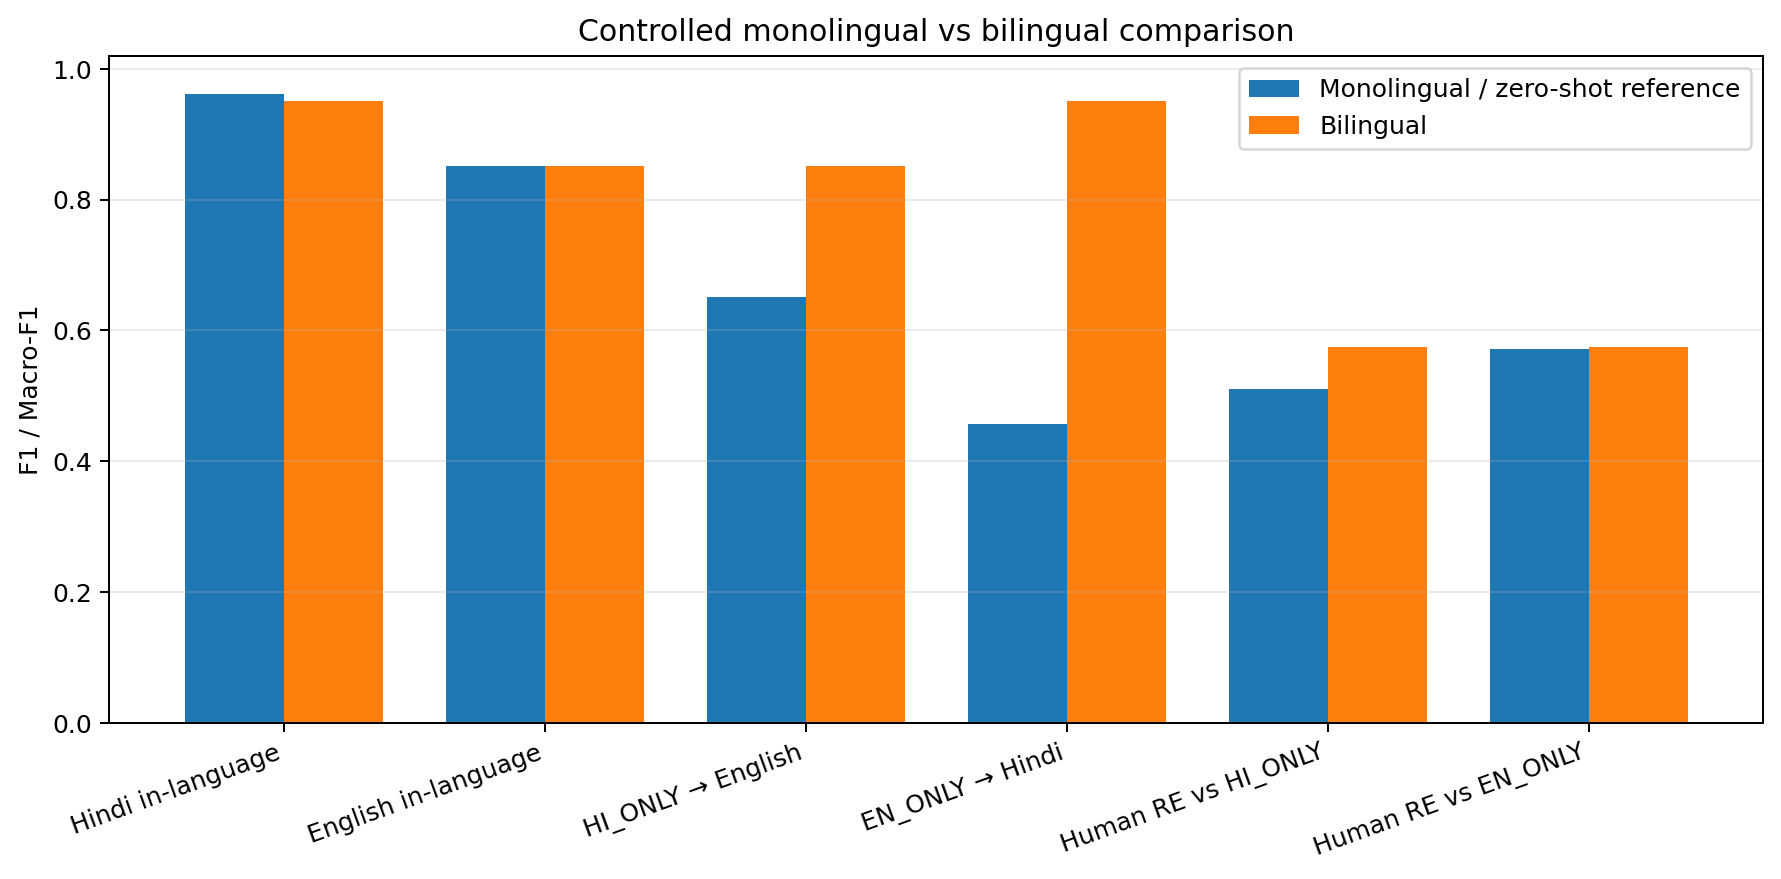

In [ ]:
# Recreate the cross-lingual score comparison
import matplotlib.pyplot as plt
import numpy as np

labels = ['Hindi in-language','English in-language','HI_ONLY → English',
          'EN_ONLY → Hindi','Human RE vs HI_ONLY','Human RE vs EN_ONLY']
reference = [0.9616,0.8517,0.6515,0.4574,0.5106,0.5710]
bilingual = [0.9506,0.8521,0.8521,0.9506,0.5754,0.5754]

x = np.arange(len(labels))
w = 0.38
fig, ax = plt.subplots(figsize=(10,5))
ax.bar(x-w/2, reference, w, label='Monolingual / zero-shot reference')
ax.bar(x+w/2, bilingual, w, label='Bilingual')
ax.set_ylabel('F1 / Macro-F1')
ax.set_title('Controlled monolingual vs bilingual comparison')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha='right')
ax.set_ylim(0,1.02)
ax.legend()
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()


### Entity-level cross-lingual generalization

Class-level comparison for DIS, SYM, PER, and CON under monolingual transfer and bilingual training.

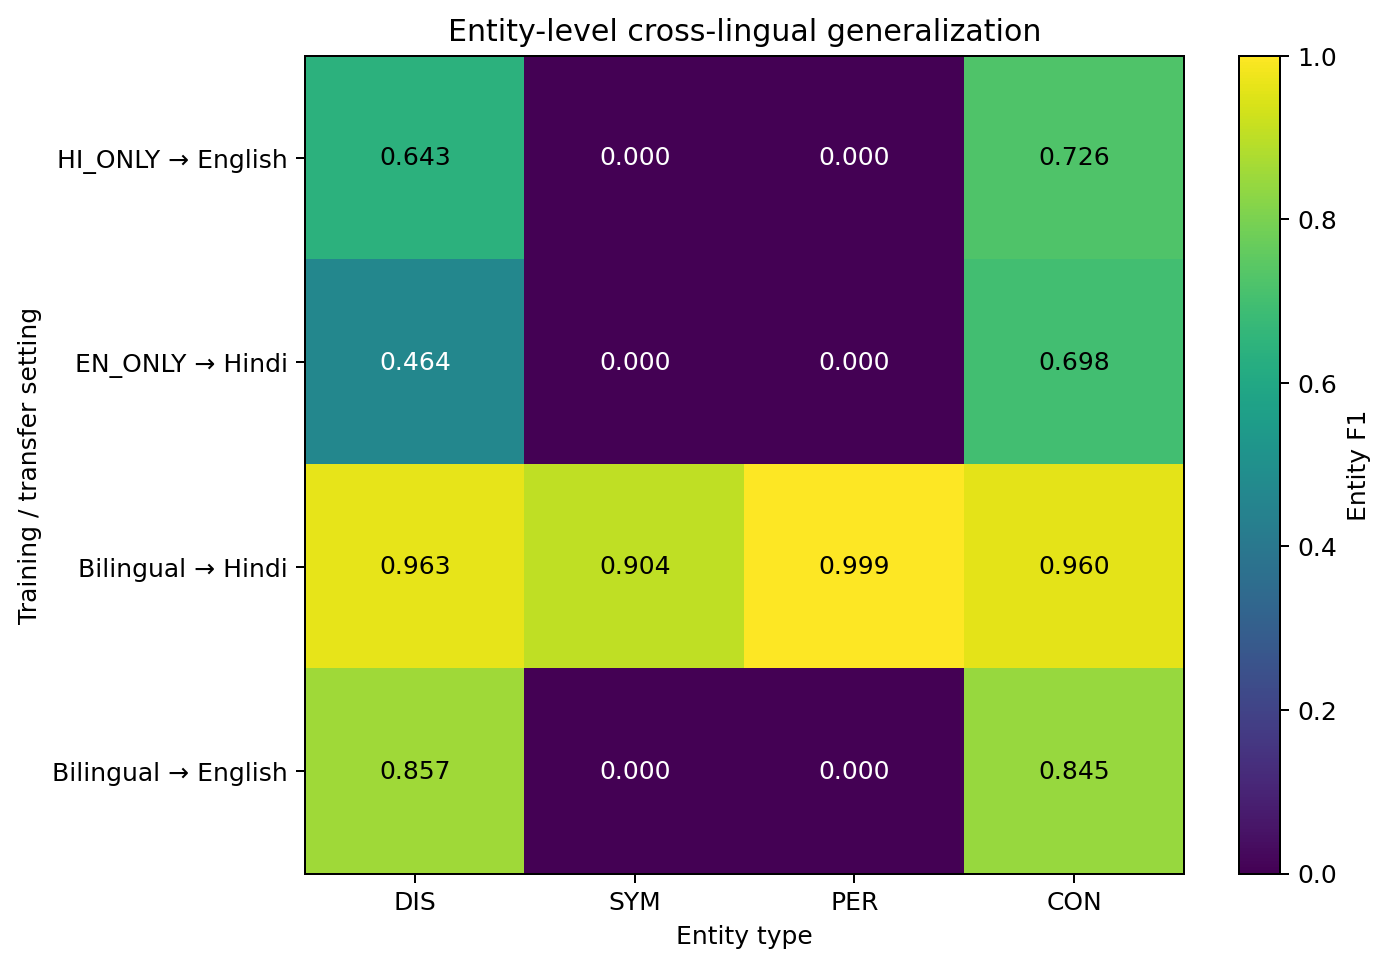

In [ ]:
# Recreate the entity-level cross-lingual heatmap
import numpy as np
import matplotlib.pyplot as plt

entity_matrix = np.array([
    [0.643,0.000,0.000,0.726],
    [0.464,0.000,0.000,0.698],
    [0.963,0.904,0.999,0.960],
    [0.857,0.000,0.000,0.845],
])
row_labels = ['HI_ONLY → English','EN_ONLY → Hindi','Bilingual → Hindi','Bilingual → English']
col_labels = ['DIS','SYM','PER','CON']

fig, ax = plt.subplots(figsize=(8,5.5))
im = ax.imshow(entity_matrix, vmin=0, vmax=1, aspect='auto')
for i in range(entity_matrix.shape[0]):
    for j in range(entity_matrix.shape[1]):
        val = entity_matrix[i,j]
        ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                color='white' if val < 0.55 else 'black')
ax.set_xticks(range(4)); ax.set_xticklabels(col_labels)
ax.set_yticks(range(4)); ax.set_yticklabels(row_labels)
ax.set_xlabel('Entity type'); ax.set_ylabel('Training / transfer setting')
ax.set_title('Entity-level cross-lingual generalization')
fig.colorbar(im, ax=ax, label='Entity F1')
plt.tight_layout()
plt.show()


### Relation-specific bilingual effect

Relation-wise F1 changes of the bilingual model relative to HI_ONLY and EN_ONLY controls.

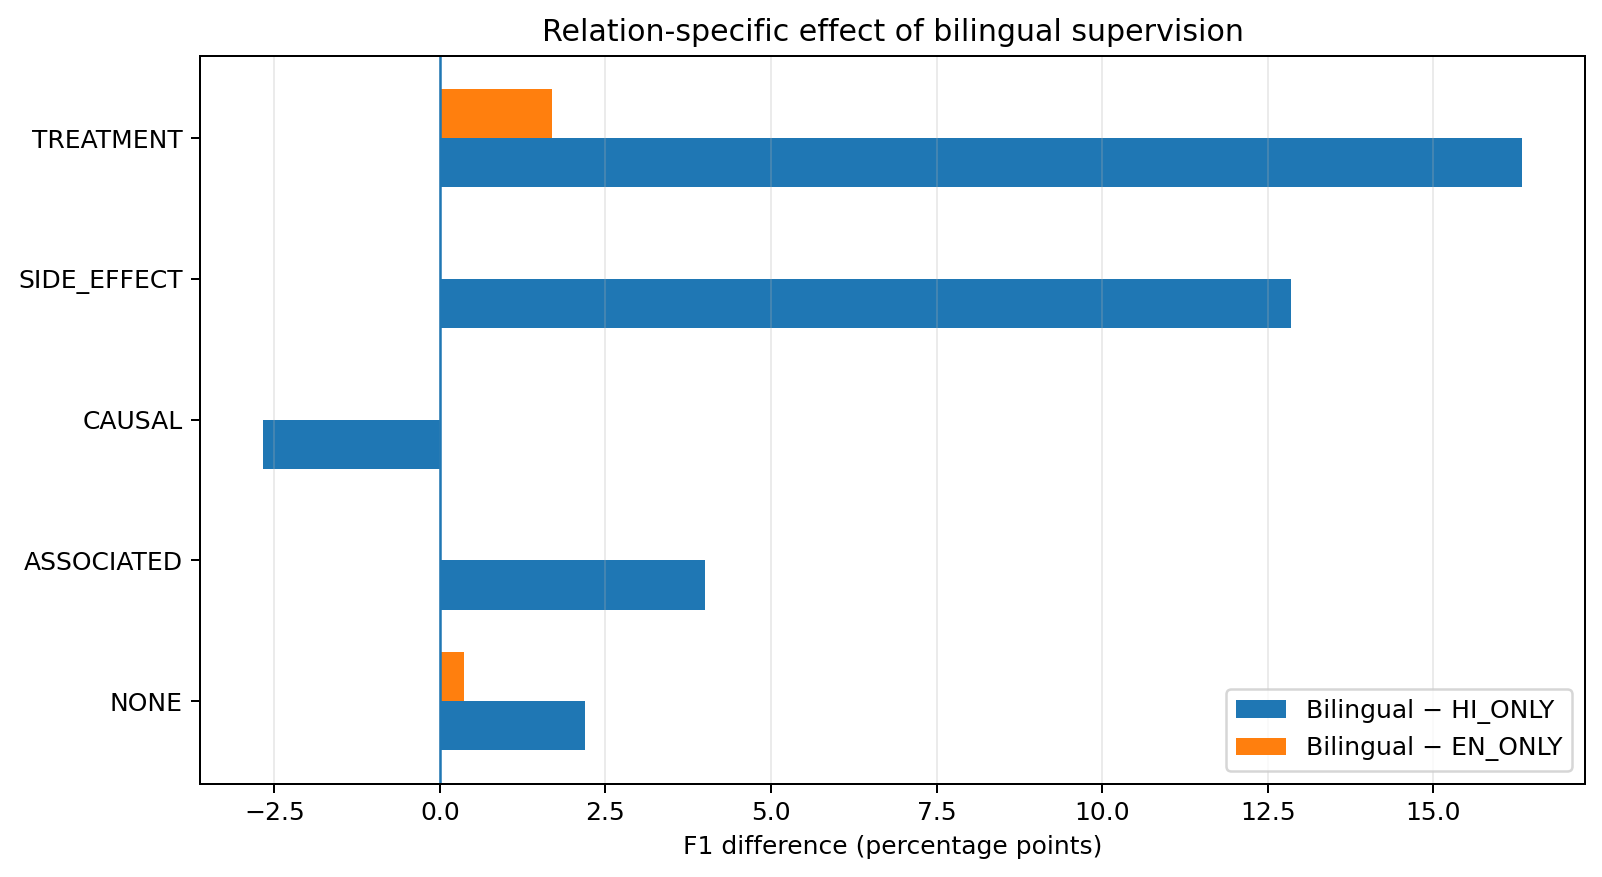

In [ ]:
# Recreate relation-specific RE deltas
import matplotlib.pyplot as plt
import numpy as np

relations = ['NONE','ASSOCIATED','CAUSAL','SIDE_EFFECT','TREATMENT']
vs_hi = [2.19,4.00,-2.67,12.86,16.34]
vs_en = [0.36,0.00,0.00,0.00,1.70]

y = np.arange(len(relations))
h = 0.35
fig, ax = plt.subplots(figsize=(9,5))
ax.barh(y-h/2, vs_hi, h, label='Bilingual − HI_ONLY')
ax.barh(y+h/2, vs_en, h, label='Bilingual − EN_ONLY')
ax.axvline(0, linewidth=1)
ax.set_yticks(y); ax.set_yticklabels(relations)
ax.set_xlabel('F1 difference (percentage points)')
ax.set_title('Relation-specific effect of bilingual supervision')
ax.legend()
ax.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()


### Representation-level diagnostics

Opposite-language semantic retrieval and silhouette-based organization across HI_ONLY, EN_ONLY, and bilingual training.

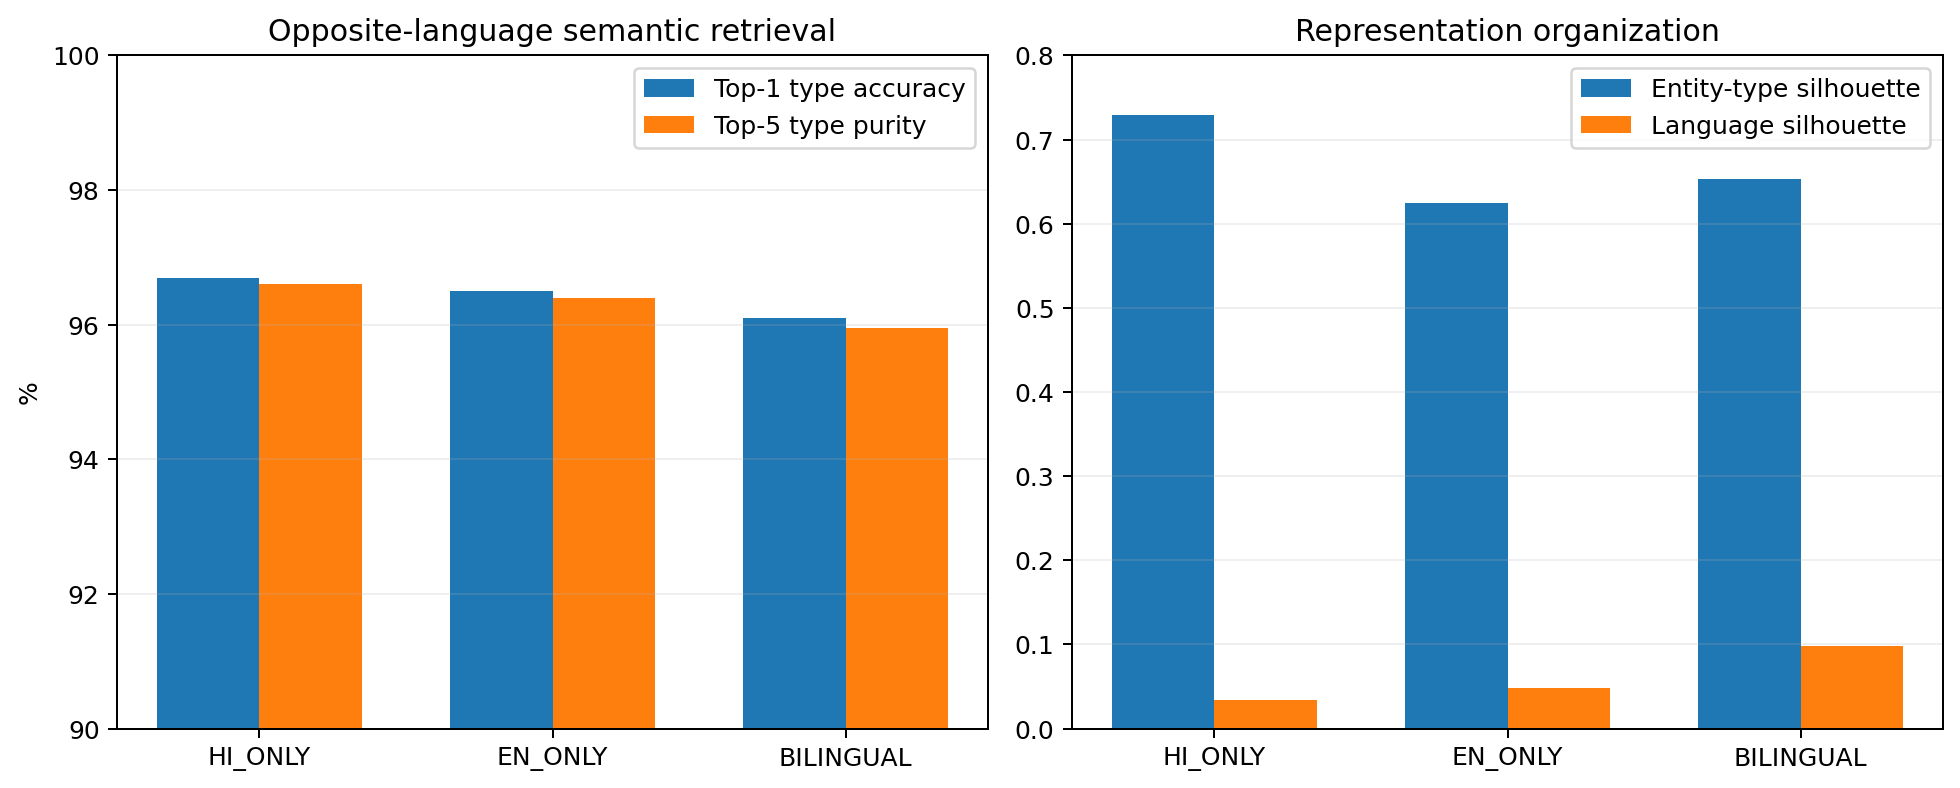

### RE confusion matrices

The next two matrices provide a compact diagnostic comparison for the selected three-teacher and four-teacher RE configurations. Both are row-normalized and use the same five coarse classes: **NONE, ASSOCIATED, CAUSAL, SIDE_EFFECT, and TREATMENT**.


### Three-teacher RE confusion matrix

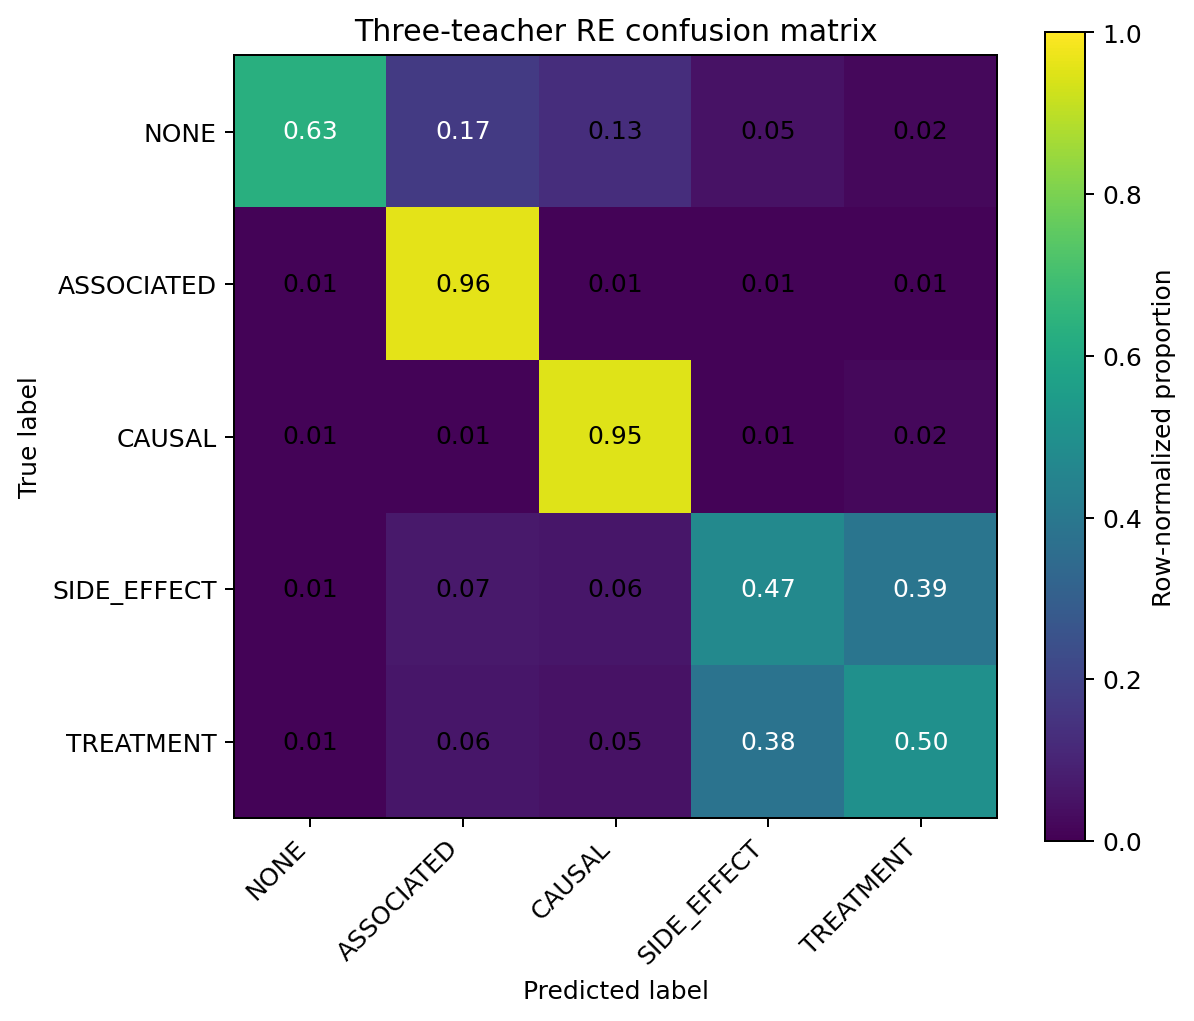

### Four-teacher RE confusion matrix

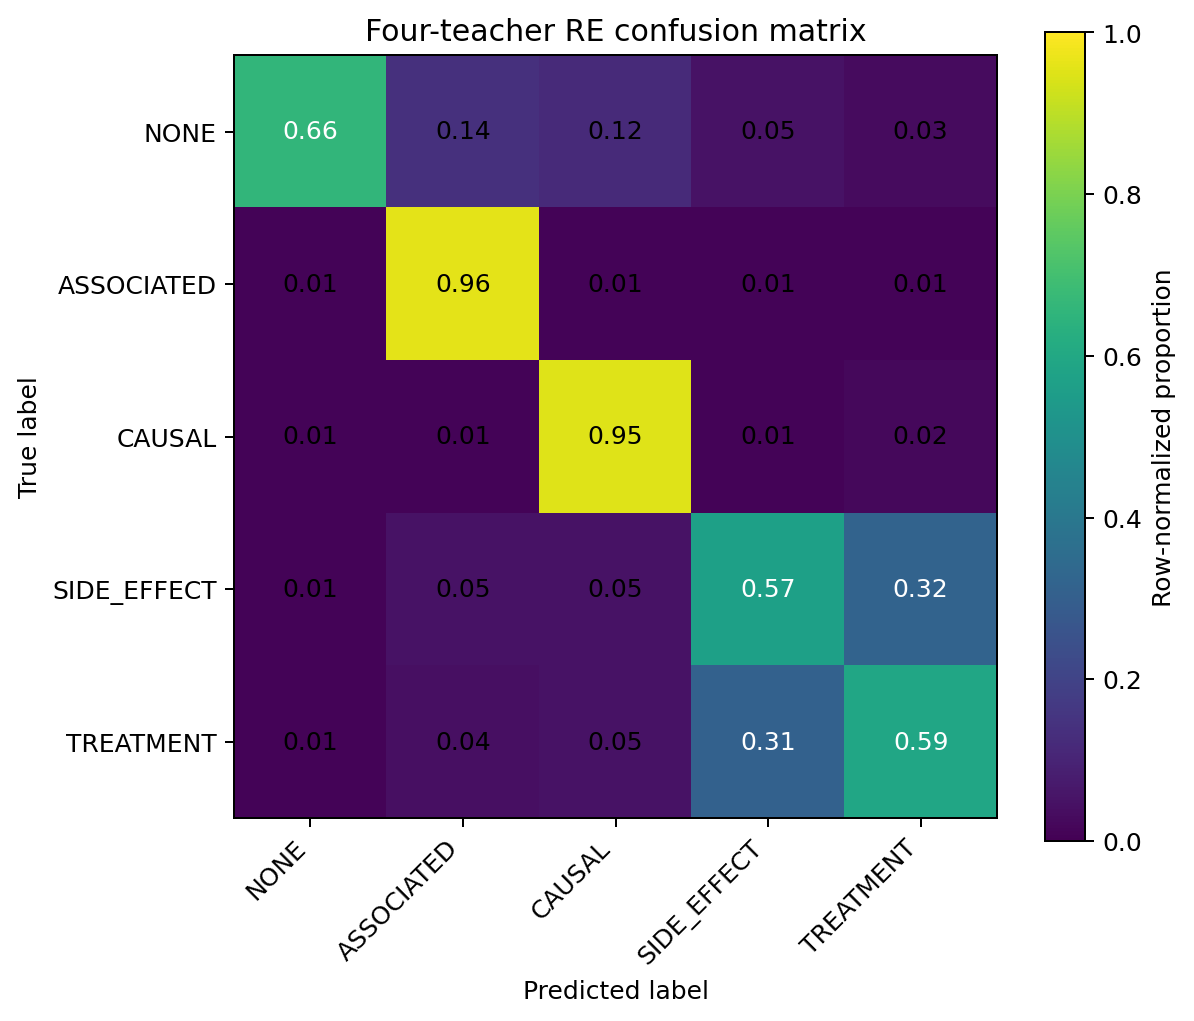

In [ ]:
# Recreate the selected 3-teacher and 4-teacher RE confusion matrices
import numpy as np
import matplotlib.pyplot as plt

relation_labels = ['NONE','ASSOCIATED','CAUSAL','SIDE_EFFECT','TREATMENT']
cm_three = np.array([
    [0.63,0.17,0.13,0.05,0.02],
    [0.01,0.96,0.01,0.01,0.01],
    [0.01,0.01,0.95,0.01,0.02],
    [0.01,0.07,0.06,0.47,0.39],
    [0.01,0.06,0.05,0.38,0.50],
])
cm_four = np.array([
    [0.66,0.14,0.12,0.05,0.03],
    [0.01,0.96,0.01,0.01,0.01],
    [0.01,0.01,0.95,0.01,0.02],
    [0.01,0.05,0.05,0.57,0.32],
    [0.01,0.04,0.05,0.31,0.59],
])

def plot_cm(cm, title):
    fig, ax = plt.subplots(figsize=(6.8,5.8))
    im = ax.imshow(cm, vmin=0, vmax=1)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            v = cm[i,j]
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                    color='white' if 0.15 < v < 0.75 else 'black')
    ax.set_xticks(range(len(relation_labels)))
    ax.set_xticklabels(relation_labels, rotation=45, ha='right')
    ax.set_yticks(range(len(relation_labels)))
    ax.set_yticklabels(relation_labels)
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label='Row-normalized proportion')
    plt.tight_layout()
    plt.show()

plot_cm(cm_three, 'Three-teacher RE confusion matrix')
plot_cm(cm_four, 'Four-teacher RE confusion matrix')


### Additional supplied result figures

The following plots are retained as **reported experimental/analysis outputs** from the supplied result files. They are embedded directly in the notebook so the notebook remains self-contained.


### Top 20 biomedical entities

![Top 20 biomedical entities](attachment:top 20 entities (1)(1).png)
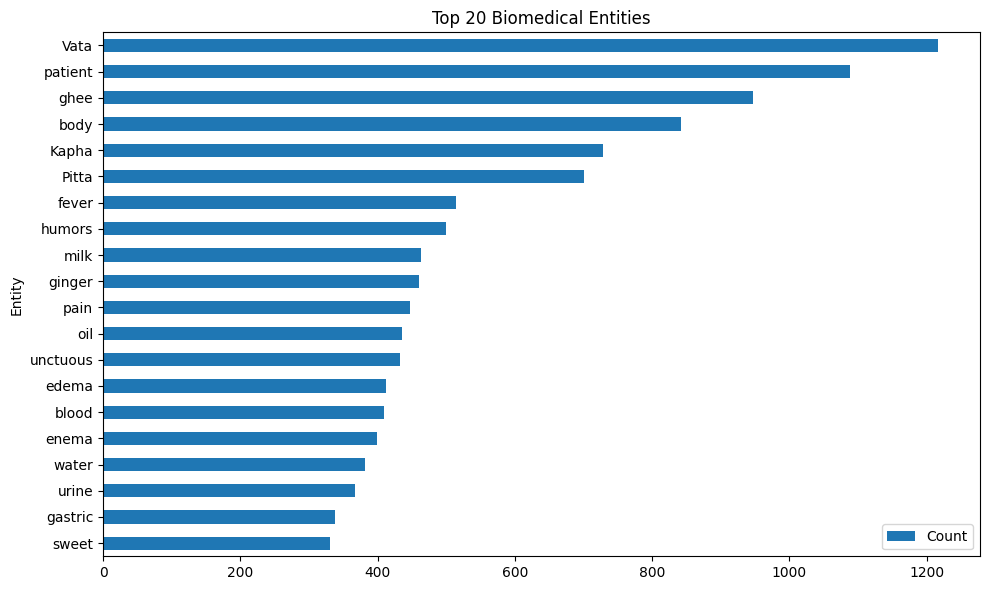

### Biomedical entity similarity heatmap

Pairwise entity-level heatmap supplied with the analysis outputs.

![Biomedical entity similarity heatmap](attachment:19(1).png)
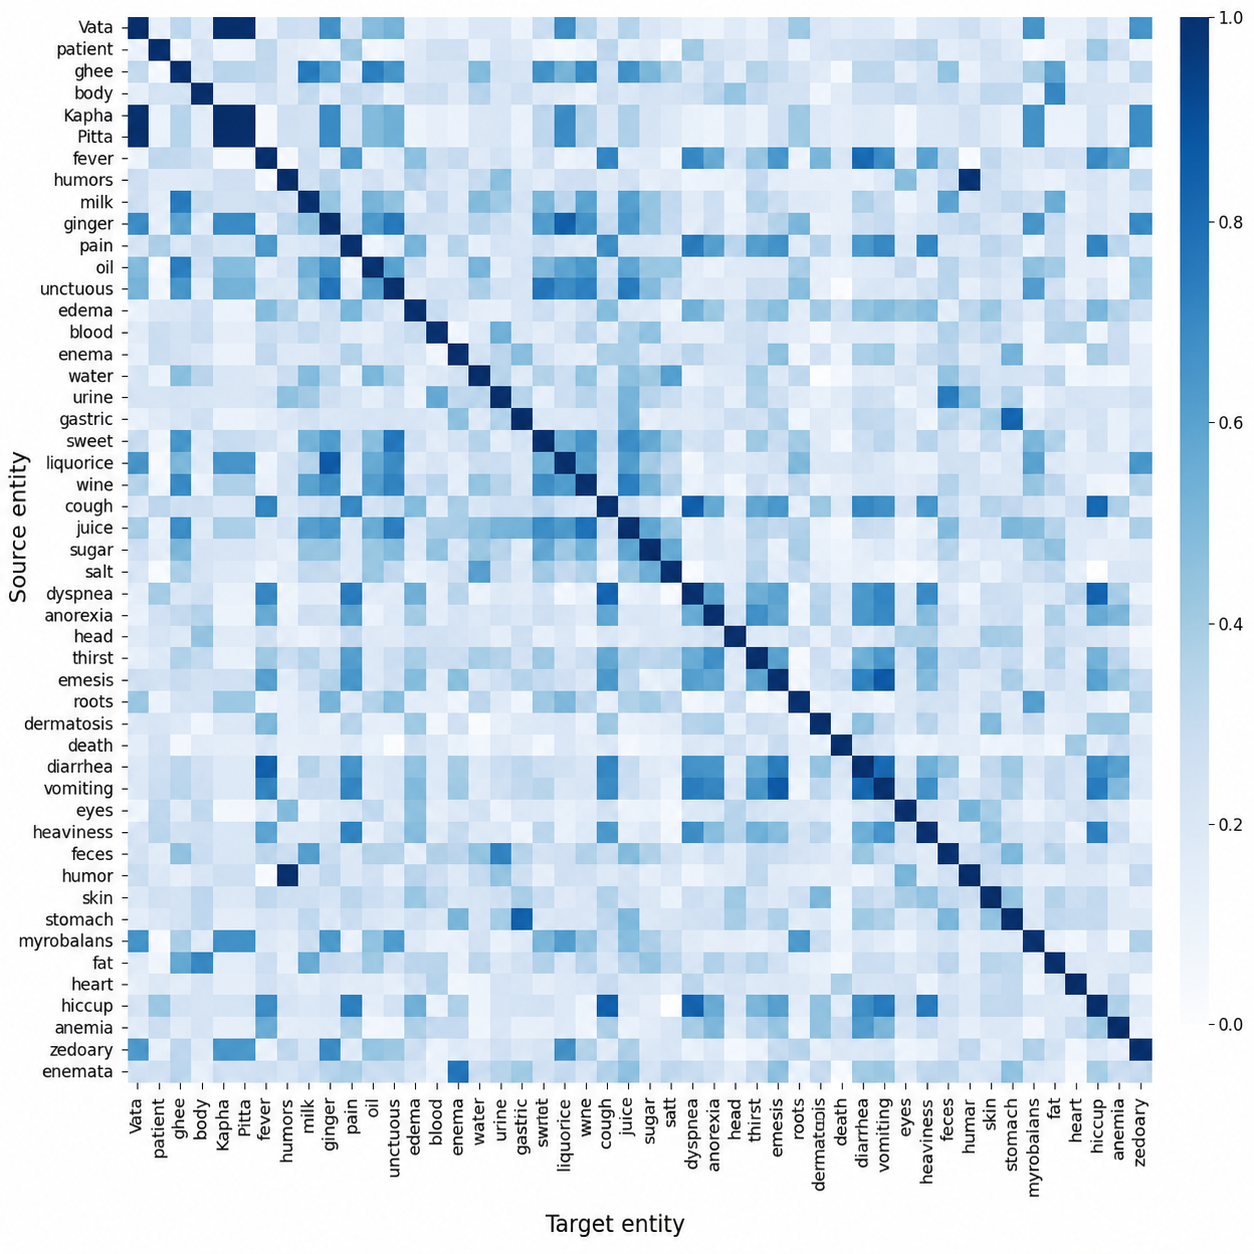

### Raw biomedical label heatmap

Raw-label source/target heatmap retained for detailed dataset-level inspection.

![Raw biomedical label heatmap](attachment:20(1).png)
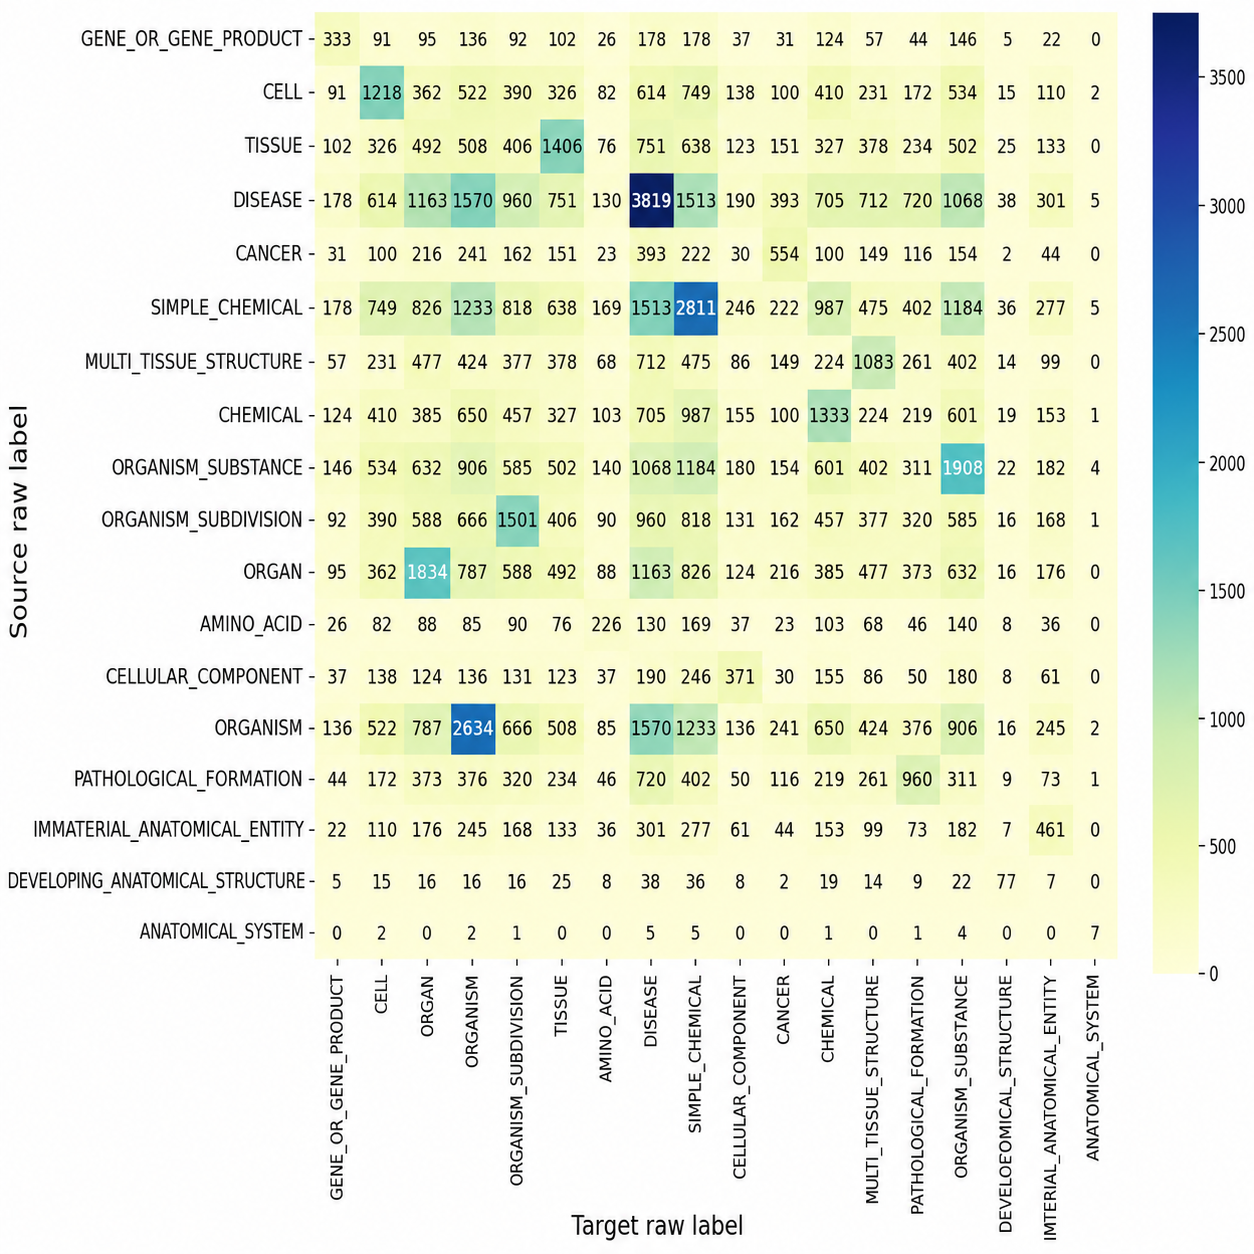

### t-SNE of RE pair embeddings

t-SNE projection of relation-pair embeddings across NONE, ASSOCIATED, CAUSAL, SIDE_EFFECT, and TREATMENT.

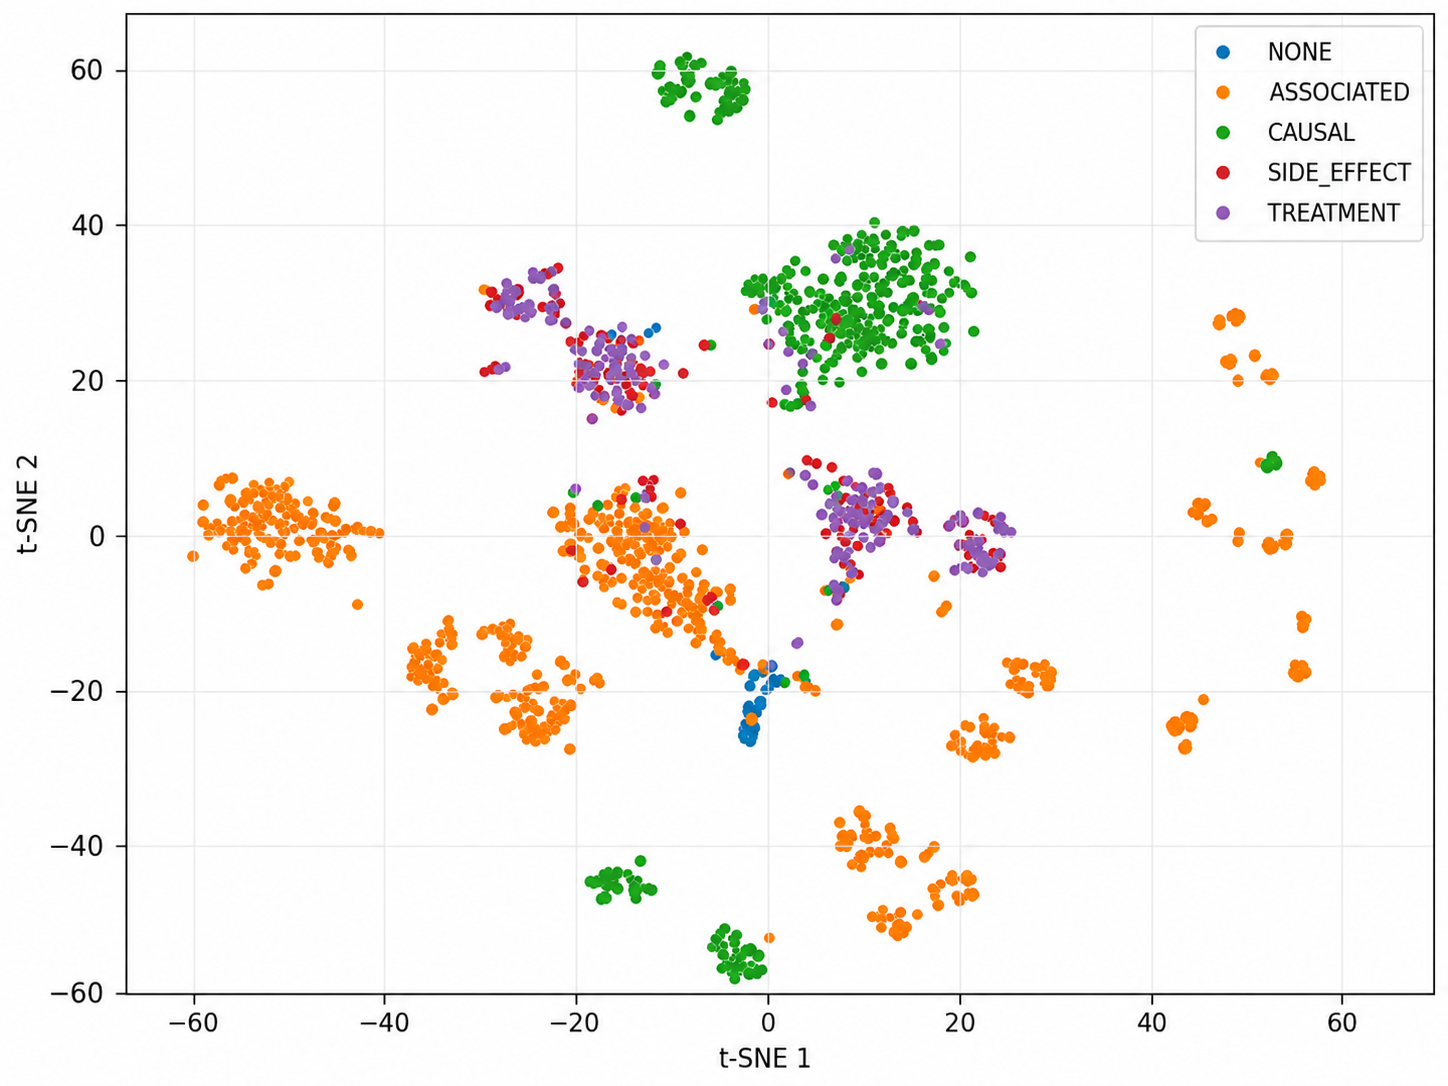

### t-SNE of biomedical entity types

t-SNE projection showing clustering for CON, DIS, PER, and SYM entity classes.

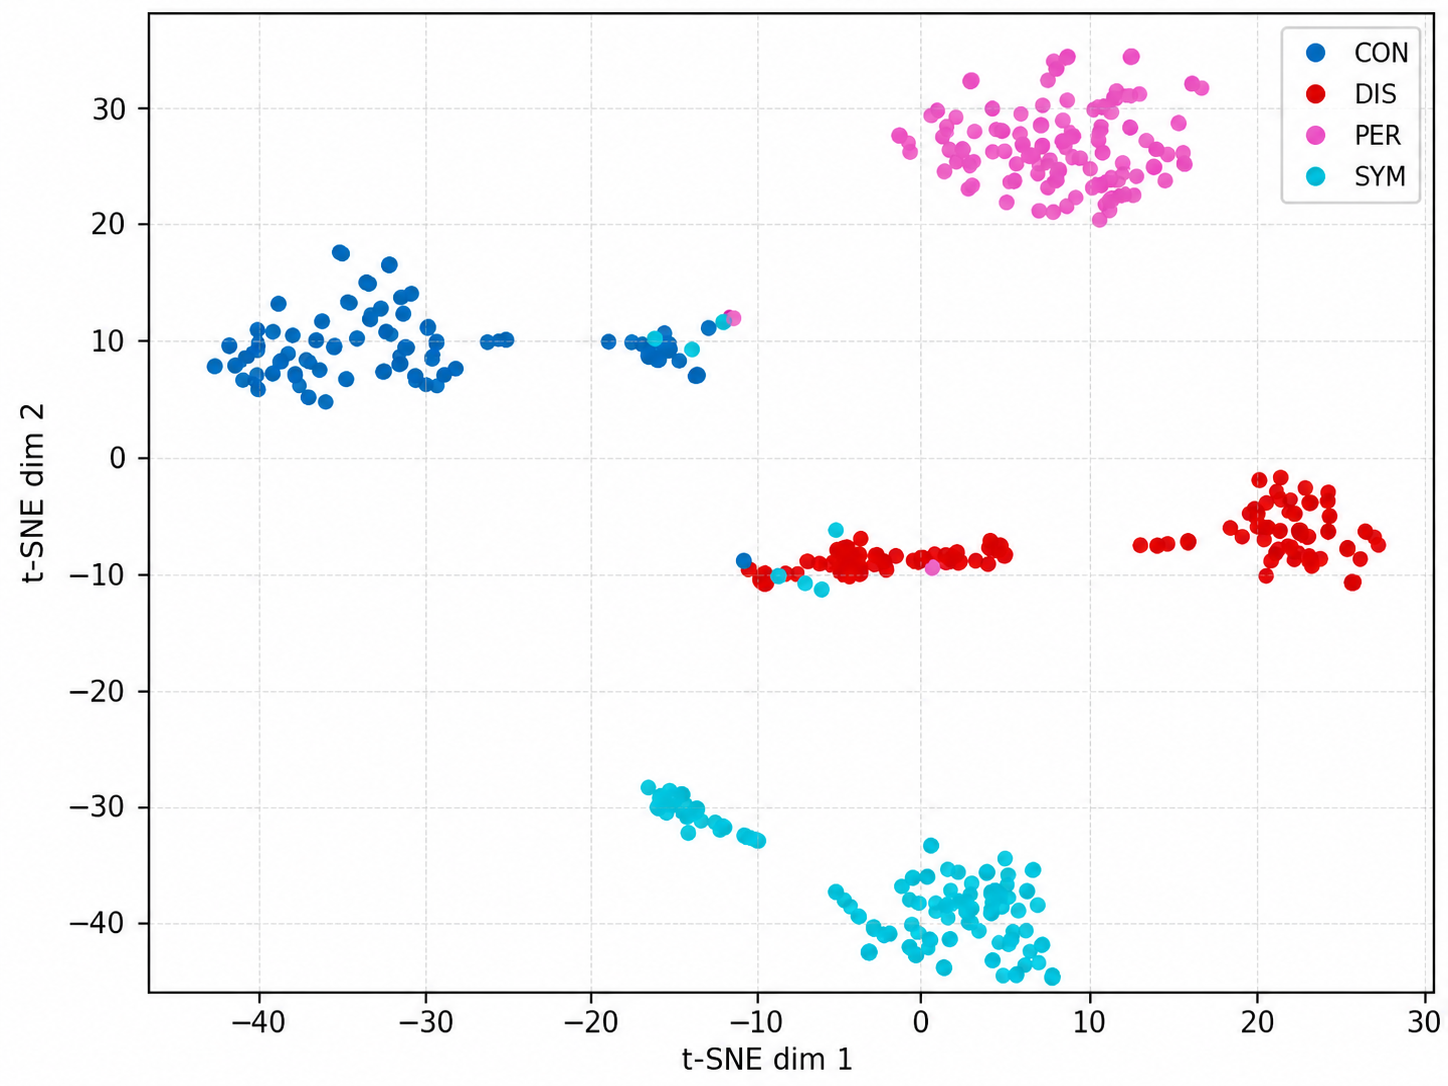

### Notes on interpretation

- The cross-lingual control comparisons are based on the matched **Seed 2026** setting.
- The human-validated RE comparison is strongest relative to HI_ONLY; the difference relative to EN_ONLY is small.
- The selected 3-teacher and 4-teacher confusion matrices show that ASSOCIATED and CAUSAL are comparatively well separated, while SIDE_EFFECT and TREATMENT retain greater mutual confusion.
- t-SNE plots are qualitative representation diagnostics and should not be interpreted as standalone statistical evidence.
- The supplied entity-frequency and heatmap figures are included as additional dataset/representation diagnostics rather than replacements for the primary task metrics.


---
## Part A — 2-Teacher Configuration

**Selected configuration:** MuRIL (Hindi teacher) + BioBERT (English teacher) → IndicBERTv2 student.  
The following cells keep the original data-preparation, training, and optional diagnostic code for this one dual-teacher configuration.


In [ ]:
# -*- coding: utf-8 -*-
# =========================================================
# Cross-lingual Hindi+English Medical NER (Part 1: Rebalanced NER)
#   - Load Hindi + English silver BIO data
#   - Normalize tags into shared BIO label space
#   - Build sentence-level examples
#   - TRAIN + VAL:
#       * Drop O-only sentences  (both HI + EN)
#       * Trim long O-runs inside sentences
#       * Randomly drop O tokens to reduce O dominance
#       * Hindi: greedy upsampling of entity sentences
#       * English: synthetic entity-only packs (DIS/CON) so
#                  coarse DIS/CON ≈ O
#   - Print final BIO counts (HI/EN, train/val)
# =========================================================

import random
import numpy as np
import pandas as pd
import torch

from sklearn.model_selection import train_test_split
from collections import Counter

# ---------------- Config ----------------
hi_csv   = "/content/hindi_bio_silver.csv"
en_csv   = "/content/english_bio_silver.csv"

VAL_SPLIT = 0.2   # 80/20 train/val split

# Downsample O-only sentence target: O ≈ target_ratio * entity_tokens
TARGET_O_PER_ENT_DOWN_HI_TRAIN = 1.0
TARGET_O_PER_ENT_DOWN_EN_TRAIN = 1.0
TARGET_O_PER_ENT_DOWN_HI_VAL   = 1.0
TARGET_O_PER_ENT_DOWN_EN_VAL   = 1.0

# Trim long O-runs
MAX_O_RUN_TRAIN = 2
MAX_O_RUN_VAL   = 2

# Drop O tokens (within entity sentences) to get O ≈ target_ratio * entity_tokens
TARGET_O_PER_ENT_DROP_HI_TRAIN = 0.30
TARGET_O_PER_ENT_DROP_EN_TRAIN = 0.30  # stronger drop for EN
TARGET_O_PER_ENT_DROP_HI_VAL   = 0.35
TARGET_O_PER_ENT_DROP_EN_VAL   = 0.35

# Greedy upsampling for HI (sentence duplicates)
MAX_EXTRA_FACTOR_HI_TRAIN = 3
MAX_EXTRA_FACTOR_HI_VAL   = 2

# Synthetic entity-only packs for EN (DIS, CON)
EN_PACK_TYPES = ["DIS", "CON"]
EN_PACK_TARGET_FACTOR_TRAIN = 1.0  # coarse(DIS/CON) ≈ 1.0 * O
EN_PACK_TARGET_FACTOR_VAL   = 1.0
EN_PACK_MAX_FACTOR_TRAIN    = 15
EN_PACK_MAX_FACTOR_VAL      = 10

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---------------- Reproducibility ----------------
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if device.type == "cuda":
    torch.cuda.manual_seed_all(42)

# =========================================================
# 1. Frozen NER label space (GLOBAL, shared HI + EN)
# =========================================================

BIO_LABELS = [
    "O",
    "B-DIS", "I-DIS",
    "B-SYM", "I-SYM",
    "B-PER", "I-PER",
    "B-CON", "I-CON",
]
bio2id = {lab: i for i, lab in enumerate(BIO_LABELS)}
id2bio = {i: lab for lab, i in bio2id.items()}
num_ner_labels = len(BIO_LABELS)

print("BIO_LABELS:", BIO_LABELS)
print("bio2id:", bio2id)

def normalize_tag(tag: str) -> str:
    """Map any unexpected tag into 'O'."""
    return tag if tag in BIO_LABELS else "O"

def bio_to_coarse(tag: str) -> str:
    if tag == "O":
        return "O"
    return tag.split("-")[1]    # 'B-DIS' -> 'DIS'

# =========================================================
# 2. Relation label space (kept here for later stages)
# =========================================================

REL_LABELS = [
    "NONE",
    "TREATS",
    "CAUSES",
    "PREVENTS",
    "ALLEVATES",
    "AGGRAVATES",
    "CONTRAINDICATED_FOR",
    "HAS_SIDE_EFFECT",
    "ASSOCIATED_WITH",
    "CO_OCCURS_WITH",
    "SYMPTOM_OF",
    "RISK_FACTOR_FOR",
    "MANIFESTATION_OF",
    "COMPLICATION_OF",
    "PART_OF",
]

rel2id = {lab: i for i, lab in enumerate(REL_LABELS)}
id2rel = {i: lab for lab, i in rel2id.items()}
num_rel_labels = len(REL_LABELS)

print("REL_LABELS:", REL_LABELS)
print("rel2id:", rel2id)

# =========================================================
# 3. Load Hindi & English NER silver, inspect, normalize
# =========================================================

df_hi = pd.read_csv(hi_csv)
df_en = pd.read_csv(en_csv)

def inspect_dataset(name, df, head_n=5):
    print(f"\n==================== {name} (raw) ====================")
    print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
    print("Columns:", list(df.columns))
    print(f"\nFirst {head_n} rows:")
    print(df.head(head_n))
    if "tag" in df.columns:
        print("\nTag counts (top 20):")
        print(df["tag"].value_counts().head(20))
    else:
        print("\nNo 'tag' column found.")

inspect_dataset("Hindi silver", df_hi)
inspect_dataset("English silver", df_en)

df_hi["tag"] = df_hi["tag"].astype(str).apply(normalize_tag)
df_en["tag"] = df_en["tag"].astype(str).apply(normalize_tag)

df_hi["coarse"] = df_hi["tag"].apply(bio_to_coarse)
df_en["coarse"] = df_en["tag"].apply(bio_to_coarse)

def inspect_after(name, df):
    print(f"\n===== {name} AFTER NORMALIZATION =====")
    print("BIO tags   :", sorted(df["tag"].unique()))
    print("Coarse tags:", sorted(df["coarse"].unique()))
    print("\nCoarse counts:")
    print(df["coarse"].value_counts())

inspect_after("Hindi silver", df_hi)
inspect_after("English silver", df_en)

# =========================================================
# 4. DF → sentence-level NER examples
# =========================================================

def build_examples_from_df(df, lang_name=""):
    """
    Turn BIO dataframe into list of {"tokens": [...], "labels": [...], "sid": sentence_id}
    - English: group by 'sentence_id'
    - Hindi  : group by 'sentence'
    """
    if "sentence_id" in df.columns:
        group_col = "sentence_id"
    elif "sentence" in df.columns:
        group_col = "sentence"
    else:
        raise ValueError(
            f"{lang_name}: No 'sentence_id' or 'sentence' column found. "
            f"Columns: {list(df.columns)}"
        )

    examples = []
    for sid, g in df.groupby(group_col, sort=False):
        toks = g["token"].astype(str).tolist()
        labs = g["tag"].astype(str).tolist()
        if len(toks) == 0 or len(toks) != len(labs):
            continue
        examples.append({"tokens": toks, "labels": labs, "sid": sid})

    print(f"{lang_name} examples: {len(examples)} sentences")
    return examples

hi_examples_all = build_examples_from_df(df_hi, "Hindi")
en_examples_all = build_examples_from_df(df_en, "English")

# For later stages (RE etc.), we keep original maps
hi_sent_map = {ex["sid"]: {"tokens": ex["tokens"], "labels": ex["labels"]}
               for ex in hi_examples_all}
en_sent_map = {ex["sid"]: {"tokens": ex["tokens"], "labels": ex["labels"]}
               for ex in en_examples_all}

# =========================================================
# 5. Utility functions
# =========================================================

def print_bio_counts_for_examples(examples, name=""):
    counter = Counter()
    for ex in examples:
        counter.update(ex["labels"])
    print(f"\n{name} BIO tag counts (tokens):")
    for lab in BIO_LABELS:
        print(f"  {lab:5s}: {counter[lab]}")
    return counter

def print_coarse_counts_from_examples(examples, name=""):
    coarse_counter = Counter()
    for ex in examples:
        for lab in ex["labels"]:
            if lab == "O":
                coarse_counter["O"] += 1
            else:
                coarse_counter[lab.split("-")[1]] += 1
    print(f"\n{name} COARSE tag counts (tokens):")
    for lab in ["O", "DIS", "SYM", "PER", "CON"]:
        print(f"  {lab:4s}: {coarse_counter[lab]}")
    return coarse_counter

def downsample_o_only_sentences(examples,
                                target_ratio=1.0,
                                seed=13,
                                name=""):
    """
    Downsample O-only sentences so that total_O ≤ target_ratio * total_entity_tokens.
    - Keeps all sentences with at least one entity (non-O).
    - Randomly keeps some O-only sentences if needed.
    """
    if not examples:
        print(f"[DOWN-O-{name}] Empty set, skipping.")
        return examples

    ent_sents = []
    o_only_sents = []
    for ex in examples:
        if any(lab != "O" for lab in ex["labels"]):
            ent_sents.append(ex)
        else:
            o_only_sents.append(ex)

    print(f"[DOWN-O-{name}] entity sents: {len(ent_sents)}, O-only sents: {len(o_only_sents)}")

    def count_tokens(ex_list):
        c = Counter()
        for ex in ex_list:
            c.update(ex["labels"])
        return c

    c_ent = count_tokens(ent_sents)
    c_oonly = count_tokens(o_only_sents)

    total_entity_tokens = sum(cnt for lab, cnt in (c_ent + c_oonly).items() if lab != "O")
    tokens_O_ent = c_ent["O"]
    tokens_O_oonly = c_oonly["O"]

    if total_entity_tokens == 0:
        print(f"[DOWN-O-{name}] No entities at all, cannot balance O. Returning original.")
        return examples

    desired_total_O = int(target_ratio * total_entity_tokens)
    max_O_from_oonly = max(desired_total_O - tokens_O_ent, 0)

    print(f"[DOWN-O-{name}] total_entity_tokens={total_entity_tokens}, "
          f"O(ent_sents)={tokens_O_ent}, O(o_only_sents)={tokens_O_oonly}, "
          f"desired_total_O≈{desired_total_O}, max_O_from_oonly≈{max_O_from_oonly}")

    if tokens_O_oonly <= max_O_from_oonly:
        kept_o_only = o_only_sents
        print(f"[DOWN-O-{name}] Keeping all O-only sentences.")
    else:
        rng = random.Random(seed)
        rng.shuffle(o_only_sents)
        kept_o_only = []
        cur_O = 0
        for ex in o_only_sents:
            o_in_ex = len(ex["labels"])  # all O
            if cur_O + o_in_ex > max_O_from_oonly:
                break
            kept_o_only.append(ex)
            cur_O += o_in_ex
        print(f"[DOWN-O-{name}] Kept {len(kept_o_only)} O-only sentences (out of {len(o_only_sents)}).")

    new_examples = ent_sents + kept_o_only

    cnt_new = Counter()
    for ex in new_examples:
        cnt_new.update(ex["labels"])

    print(f"[DOWN-O-{name}] BIO tag counts after downsampling:")
    for lab in BIO_LABELS:
        print(f"  {lab:5s}: {cnt_new[lab]}")

    return new_examples

def trim_long_o_runs(examples, max_o_run=2, name=""):
    """
    Within each sentence, if there are long consecutive runs of O tokens,
    trim them to length <= max_o_run by removing extra O's in the middle.
    """
    new_examples = []
    trimmed_sents = 0

    for ex in examples:
        toks = ex["tokens"]
        labs = ex["labels"]
        assert len(toks) == len(labs)

        new_toks = []
        new_labs = []

        i = 0
        modified = False
        while i < len(labs):
            if labs[i] != "O":
                new_toks.append(toks[i])
                new_labs.append(labs[i])
                i += 1
            else:
                # start of O run
                j = i
                while j < len(labs) and labs[j] == "O":
                    j += 1
                run_len = j - i
                keep_len = min(run_len, max_o_run)
                if run_len > keep_len:
                    modified = True
                # keep first keep_len O's
                new_toks.extend(toks[i:i+keep_len])
                new_labs.extend(labs[i:i+keep_len])
                i = j

        if modified:
            trimmed_sents += 1

        new_ex = {
            "tokens": new_toks,
            "labels": new_labs,
        }
        if "sid" in ex:
            new_ex["sid"] = ex["sid"]
        new_examples.append(new_ex)

    print(f"[TRIM-O-{name}] Applied O-run trimming (max_o_run={max_o_run}) on {len(examples)} sentences.")
    return new_examples

def drop_O_tokens_in_examples(examples, target_ratio=0.5, seed=13, name=""):
    """
    Drop some O tokens (within existing sentences) so that:
        total_O ≈ target_ratio * total_entity_tokens
    - Only drops inside sentences; entities remain untouched.
    """
    if not examples:
        print(f"[DROP-O-{name}] Empty set, skipping.")
        return examples

    # Count current tokens
    cnt = Counter()
    for ex in examples:
        cnt.update(ex["labels"])

    total_entity_tokens = sum(v for k, v in cnt.items() if k != "O")
    current_O = cnt["O"]
    desired_O = int(target_ratio * total_entity_tokens)

    if current_O == 0 or total_entity_tokens == 0:
        print(f"[DROP-O-{name}] No O or no entities, skipping.")
        return examples

    keep_prob = min(1.0, desired_O / float(max(current_O, 1)))
    print(f"[DROP-O-{name}] Dropped O tokens with keep_prob={keep_prob:.3f} "
          f"({current_O} -> ~{int(current_O * keep_prob)}).")

    rng = random.Random(seed)
    new_examples = []
    for ex in examples:
        toks = ex["tokens"]
        labs = ex["labels"]
        assert len(toks) == len(labs)

        new_toks = []
        new_labs = []
        for t, l in zip(toks, labs):
            if l == "O":
                if rng.random() < keep_prob:
                    new_toks.append(t)
                    new_labs.append(l)
            else:
                new_toks.append(t)
                new_labs.append(l)

        if len(new_toks) == 0:
            # avoid empty sentence -> keep at least one token (even O)
            new_toks = [toks[0]]
            new_labs = [labs[0]]

        new_ex = {"tokens": new_toks, "labels": new_labs}
        if "sid" in ex:
            new_ex["sid"] = ex["sid"]
        new_examples.append(new_ex)

    # Recount
    cnt_new = Counter()
    for ex in new_examples:
        cnt_new.update(ex["labels"])

    print(f"[DROP-O-{name}] BIO tag counts after random O-drop:")
    for lab in BIO_LABELS:
        print(f"  {lab:5s}: {cnt_new[lab]}")

    return new_examples

def greedy_upsample_ner_examples(train_examples,
                                 labels_to_balance=None,
                                 max_extra_factor=3,
                                 seed=13,
                                 name=""):
    """
    Mild greedy upsampling on sentence level (used for HINDI).
    - Uses current O count as reference: target_count[label] = current_O.
    - Repeatedly duplicates sentences that contain the most under-represented
      label (among labels_to_balance) until:
        * we added max_extra_factor * len(train_examples) sentences,
          OR deficits become small/negative.
    """
    if not train_examples:
        print(f"[NER-UP-{name}] Empty train set, skipping.")
        return train_examples

    if labels_to_balance is None:
        labels_to_balance = [lab for lab in BIO_LABELS if lab != "O"]

    token_counts = Counter()
    ex_entity_sets = []
    for ex in train_examples:
        labs = ex["labels"]
        token_counts.update(labs)
        ent_labs = set(l for l in labs if l != "O")
        ex_entity_sets.append(ent_labs)

    o_count = token_counts["O"]
    print(f"[NER-UP-{name}] Current O token count: {o_count}")

    real_labels = []
    for lab in labels_to_balance:
        if token_counts[lab] > 0:
            real_labels.append(lab)
        else:
            print(f"[NER-UP-{name}] Label {lab} has 0 tokens -> cannot upsample it (skipping).")
    labels_to_balance = real_labels

    if not labels_to_balance:
        print(f"[NER-UP-{name}] No entity labels to balance (all zero) -> skipping.")
        return train_examples

    target_counts = {lab: o_count for lab in labels_to_balance}

    label_to_indices = {lab: [] for lab in labels_to_balance}
    for i, ent_labs in enumerate(ex_entity_sets):
        for lab in ent_labs:
            if lab in label_to_indices:
                label_to_indices[lab].append(i)

    new_examples = list(train_examples)
    cur_counts = token_counts.copy()
    rng = random.Random(seed)

    max_new = max_extra_factor * len(train_examples)
    added = 0

    while labels_to_balance and added < max_new:
        deficits = {
            lab: target_counts[lab] - cur_counts[lab]
            for lab in labels_to_balance
        }
        lab, deficit = max(deficits.items(), key=lambda kv: kv[1])

        if deficit <= 0:
            labels_to_balance = [l for l in labels_to_balance if l != lab]
            continue

        if not label_to_indices[lab]:
            labels_to_balance = [l for l in labels_to_balance if l != lab]
            continue

        ex_idx = rng.choice(label_to_indices[lab])
        ex = train_examples[ex_idx]

        new_ex = {
            "tokens": ex["tokens"][:],
            "labels": ex["labels"][:],
        }
        if "sid" in ex:
            new_ex["sid"] = ex["sid"]
        new_examples.append(new_ex)

        cur_counts.update(ex["labels"])
        added += 1

    print(f"[NER-UP-{name}] Added {added} sentences "
          f"({len(train_examples)} -> {len(new_examples)})")
    print(f"[NER-UP-{name}] Final BIO tag counts (after upsampling):")
    for lab in BIO_LABELS:
        print(f"  {lab:5s}: {cur_counts[lab]}")
    return new_examples

def augment_with_entity_packs(examples,
                              coarse_types=("DIS", "CON"),
                              target_factor=1.0,
                              max_packs_factor=15,
                              seed=17,
                              name=""):
    """
    Synthetic entity-only packs (used for ENGLISH):
    - Extract contiguous entity spans for the given coarse_types.
    - Each pack is a mini-sentence containing ONLY that span (no O).
    - We add packs so that, for each coarse type T:
         coarse_count[T] >= target_factor * O_count
      where coarse_count[T] = count(B-T) + count(I-T) over all examples.
    """
    if not examples:
        print(f"[PACK-{name}] Empty set, skipping.")
        return examples

    base_counts = Counter()
    for ex in examples:
        base_counts.update(ex["labels"])

    o_count = base_counts["O"]
    if o_count == 0:
        print(f"[PACK-{name}] O=0 → nothing to match, skipping.")
        return examples

    coarse_counts = {}
    for t in coarse_types:
        b = f"B-{t}"
        i = f"I-{t}"
        coarse_counts[t] = base_counts[b] + base_counts[i]

    print(f"\n[PACK-{name}] Before packs:")
    print(f"  O: {o_count}")
    for t in coarse_types:
        print(f"  {t}: {coarse_counts[t]}")

    # Needed tokens per coarse type
    target_per_type = {t: int(target_factor * o_count) for t in coarse_types}
    needed = {t: max(target_per_type[t] - coarse_counts[t], 0) for t in coarse_types}

    if all(v <= 0 for v in needed.values()):
        print(f"[PACK-{name}] All coarse types already >= target, no packs needed.")
        return examples

    # Extract spans by type
    spans_by_type = {t: [] for t in coarse_types}
    for ex in examples:
        toks = ex["tokens"]
        labs = ex["labels"]
        i = 0
        while i < len(labs):
            lab = labs[i]
            if lab.startswith("B-"):
                t = lab.split("-")[1]
                if t in coarse_types:
                    j = i + 1
                    while j < len(labs) and labs[j] == f"I-{t}":
                        j += 1
                    span_tokens = toks[i:j]
                    span_labels = labs[i:j]
                    spans_by_type[t].append({"tokens": span_tokens, "labels": span_labels})
                    i = j
                    continue
            i += 1

    for t in coarse_types:
        if not spans_by_type[t]:
            print(f"[PACK-{name}] WARNING: no spans for type {t}; cannot augment it.")

    total_spans = sum(len(v) for v in spans_by_type.values())
    if total_spans == 0:
        print(f"[PACK-{name}] No spans for any given type, skipping.")
        return examples

    max_packs = max_packs_factor * total_spans
    rng = random.Random(seed)
    new_examples = list(examples)
    added_counts = Counter()
    packs_added = 0

    while packs_added < max_packs and any(needed[t] > 0 for t in coarse_types):
        # type with largest remaining need
        t = max(coarse_types, key=lambda x: needed[x])
        if needed[t] <= 0:
            break
        if not spans_by_type[t]:
            # can't help this type anymore
            needed[t] = 0
            continue

        span = rng.choice(spans_by_type[t])
        pack_tokens = span["tokens"][:]
        pack_labels = span["labels"][:]

        new_examples.append({"tokens": pack_tokens, "labels": pack_labels})
        packs_added += 1
        added_counts.update(pack_labels)
        needed[t] -= len(pack_labels)

    final_counts = base_counts + added_counts
    final_coarse = {}
    for t in coarse_types:
        final_coarse[t] = final_counts[f"B-{t}"] + final_counts[f"I-{t}"]

    print(f"[PACK-{name}] Added {packs_added} entity-only packs "
          f"(max allowed ~{max_packs}).")
    print("[PACK-{name}] Final BIO tag counts (after packs):")
    for lab in BIO_LABELS:
        print(f"  {lab:5s}: {final_counts[lab]}")

    print(f"\n[PACK-{name}] Final COARSE counts:")
    print(f"  O: {final_counts['O']}")
    for t in coarse_types:
        print(f"  {t}: {final_coarse[t]}  (target ≥ {target_per_type[t]})")

    return new_examples

# =========================================================
# 6. Train/val split
# =========================================================

hi_train_ex, hi_val_ex = train_test_split(
    hi_examples_all, test_size=VAL_SPLIT, random_state=42, shuffle=True
)
en_train_ex, en_val_ex = train_test_split(
    en_examples_all, test_size=VAL_SPLIT, random_state=42, shuffle=True
)

print(f"\nInitial sizes: HI train={len(hi_train_ex)}, val={len(hi_val_ex)}")
print(f"               EN train={len(en_train_ex)}, val={len(en_val_ex)}")

# =========================================================
# 7. Apply pipeline: HI + EN, TRAIN and VAL
# =========================================================

# ---------- HINDI TRAIN ----------
hi_train_ex = downsample_o_only_sentences(
    hi_train_ex,
    target_ratio=TARGET_O_PER_ENT_DOWN_HI_TRAIN,
    seed=13,
    name="HI-TRAIN",
)

hi_train_ex = trim_long_o_runs(
    hi_train_ex,
    max_o_run=MAX_O_RUN_TRAIN,
    name="HI-TRAIN",
)

hi_train_ex = drop_O_tokens_in_examples(
    hi_train_ex,
    target_ratio=TARGET_O_PER_ENT_DROP_HI_TRAIN,
    seed=13,
    name="HI-TRAIN",
)

hi_train_ex = greedy_upsample_ner_examples(
    hi_train_ex,
    max_extra_factor=MAX_EXTRA_FACTOR_HI_TRAIN,
    seed=17,
    name="HI-TRAIN",
)

# ---------- ENGLISH TRAIN ----------
en_train_ex = downsample_o_only_sentences(
    en_train_ex,
    target_ratio=TARGET_O_PER_ENT_DOWN_EN_TRAIN,
    seed=13,
    name="EN-TRAIN",
)

en_train_ex = trim_long_o_runs(
    en_train_ex,
    max_o_run=MAX_O_RUN_TRAIN,
    name="EN-TRAIN",
)

en_train_ex = drop_O_tokens_in_examples(
    en_train_ex,
    target_ratio=TARGET_O_PER_ENT_DROP_EN_TRAIN,
    seed=13,
    name="EN-TRAIN",
)

# Instead of greedy upsampling for EN, use synthetic entity-only packs
en_train_ex = augment_with_entity_packs(
    en_train_ex,
    coarse_types=EN_PACK_TYPES,
    target_factor=EN_PACK_TARGET_FACTOR_TRAIN,
    max_packs_factor=EN_PACK_MAX_FACTOR_TRAIN,
    seed=19,
    name="EN-TRAIN",
)

# ---------- HINDI VAL ----------
hi_val_ex = downsample_o_only_sentences(
    hi_val_ex,
    target_ratio=TARGET_O_PER_ENT_DOWN_HI_VAL,
    seed=21,
    name="HI-VAL",
)

hi_val_ex = trim_long_o_runs(
    hi_val_ex,
    max_o_run=MAX_O_RUN_VAL,
    name="HI-VAL",
)

hi_val_ex = drop_O_tokens_in_examples(
    hi_val_ex,
    target_ratio=TARGET_O_PER_ENT_DROP_HI_VAL,
    seed=21,
    name="HI-VAL",
)

hi_val_ex = greedy_upsample_ner_examples(
    hi_val_ex,
    max_extra_factor=MAX_EXTRA_FACTOR_HI_VAL,
    seed=23,
    name="HI-VAL",
)

# ---------- ENGLISH VAL ----------
en_val_ex = downsample_o_only_sentences(
    en_val_ex,
    target_ratio=TARGET_O_PER_ENT_DOWN_EN_VAL,
    seed=21,
    name="EN-VAL",
)

en_val_ex = trim_long_o_runs(
    en_val_ex,
    max_o_run=MAX_O_RUN_VAL,
    name="EN-VAL",
)

en_val_ex = drop_O_tokens_in_examples(
    en_val_ex,
    target_ratio=TARGET_O_PER_ENT_DROP_EN_VAL,
    seed=21,
    name="EN-VAL",
)

en_val_ex = augment_with_entity_packs(
    en_val_ex,
    coarse_types=EN_PACK_TYPES,
    target_factor=EN_PACK_TARGET_FACTOR_VAL,
    max_packs_factor=EN_PACK_MAX_FACTOR_VAL,
    seed=25,
    name="EN-VAL",
)

# =========================================================
# 8. Final stats
# =========================================================

print(f"\nHindi NER (after full rebalance): train={len(hi_train_ex)}, val={len(hi_val_ex)}")
hi_train_counts = print_bio_counts_for_examples(hi_train_ex, name="Hindi TRAIN FINAL")
hi_train_coarse = print_coarse_counts_from_examples(hi_train_ex, name="Hindi TRAIN FINAL")
hi_val_counts   = print_bio_counts_for_examples(hi_val_ex,   name="Hindi VAL FINAL")
hi_val_coarse   = print_coarse_counts_from_examples(hi_val_ex,   name="Hindi VAL FINAL")

print(f"\nEnglish NER (after full rebalance): train={len(en_train_ex)}, val={len(en_val_ex)}")
en_train_counts = print_bio_counts_for_examples(en_train_ex, name="English TRAIN FINAL")
en_train_coarse = print_coarse_counts_from_examples(en_train_ex, name="English TRAIN FINAL")
en_val_counts   = print_bio_counts_for_examples(en_val_ex,   name="English VAL FINAL")
en_val_coarse   = print_coarse_counts_from_examples(en_val_ex,   name="English VAL FINAL")


In [ ]:
# -*- coding: utf-8 -*-
# =========================================================
# Cross-lingual Hindi+English Medical NER+RE with Dual Teachers
#
# Student: multilingual encoder (IndicBERTv2)
#   ENCODER_NAME / STUDENT_ENCODER = "ai4bharat/IndicBERTv2-MLM-only"
#
# Hindi NER teacher: MuRIL (or IndicBERTv2)
#   HI_TEACHER_ENCODER = "google/muril-base-cased"
#
# English biomedical NER teacher: BioBERT / PubMedBERT
#   EN_TEACHER_ENCODER = "dmis-lab/biobert-base-cased-v1.1"
#   (you can swap to PubMedBERT if you like)
#
# Dual-teacher KD:
#   For each Hindi batch, minimize KL(student || Hindi teacher)
#   For each English batch, minimize KL(student || English teacher)
#   in addition to gold NER CE + RE CE.
#
# Requirements (from Part 1 – Rebalanced NER):
#   - hi_train_ex, hi_val_ex, en_train_ex, en_val_ex
#   - BIO_LABELS, bio2id, id2bio
# =========================================================

import os
import time
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForTokenClassification,
    get_linear_schedule_with_warmup,
)

import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from collections import Counter

# ---------- Sanity check: Part 1 must have run ----------
try:
    _ = hi_train_ex, hi_val_ex, en_train_ex, en_val_ex
    _ = BIO_LABELS, bio2id, id2bio
except NameError:
    raise RuntimeError(
        "Part 1 (Rebalanced NER) not found. "
        "You must first run the script that builds hi_train_ex, hi_val_ex, "
        "en_train_ex, en_val_ex and defines BIO_LABELS/bio2id/id2bio."
    )

# =========================================================
# 0. Global config & seeds
# =========================================================

# Student encoder (multilingual)
ENCODER_NAME   = "ai4bharat/IndicBERTv2-MLM-only"
STUDENT_ENCODER = ENCODER_NAME

# Dual teachers
HI_TEACHER_ENCODER = "google/muril-base-cased"  # Hindi teacher
EN_TEACHER_ENCODER = "dmis-lab/biobert-base-cased-v1.1"  # English biomedical teacher
# Alternative EN teacher:
# EN_TEACHER_ENCODER = "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext"

BATCH_SIZE   = 16
MAX_LEN      = 256

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if device.type == "cuda":
    torch.cuda.manual_seed_all(42)

num_ner_labels = len(BIO_LABELS)

# Teacher hyperparams
TEACHER_LR       = 2e-5
TEACHER_EPOCH_HI = 4
TEACHER_EPOCH_EN = 4

# Student config: indicbertv2_ep5_lr1p5e-5_longRE
STUDENT_LR      = 1.5e-5
STUDENT_EPOCHS  = 5

# Dual-teacher KD hyperparams
KD_T        = 2.0
KD_ALPHA_HI = 0.7   # weight of KD loss for Hindi
KD_ALPHA_EN = 0.7   # weight of KD loss for English

MAX_REL_DIST       = 15   # long relation window
MAX_PAIRS_PER_SENT = 30   # more pairs per sentence

# =========================================================
# 1. NER Dataset & collate (encoder-specific tokenizer)
#    (used for training/evaluating teacher models and
#     for student NER evaluation)
# =========================================================

class SilverNERDataset(Dataset):
    def __init__(self, examples, tokenizer, max_len=256):
        """
        examples: list of dicts {"tokens": [...], "labels": [...], "sid": optional}
        """
        self.examples = examples
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        ex = self.examples[idx]
        tokens = ex["tokens"]
        labels = ex["labels"]

        enc = self.tokenizer(
            tokens,
            is_split_into_words=True,
            return_offsets_mapping=False,
            return_tensors="pt",
            truncation=True,
            max_length=self.max_len,
        )

        input_ids = enc["input_ids"][0]             # [L]
        attention_mask = enc["attention_mask"][0]   # [L]
        word_ids = enc.word_ids(0)

        tag_ids = torch.full_like(input_ids, fill_value=-100)
        prev_w = None
        for i, w_id in enumerate(word_ids):
            if w_id is None:
                continue
            if w_id != prev_w:
                lab = labels[w_id]
                tag_ids[i] = bio2id[lab]
                prev_w = w_id

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": tag_ids,
        }

def make_ner_collate_fn(tokenizer):
    def ner_collate_fn(batch):
        input_ids_list = [item["input_ids"] for item in batch]
        attn_list      = [item["attention_mask"] for item in batch]
        labels_list    = [item["labels"] for item in batch]

        padded = tokenizer.pad(
            {"input_ids": input_ids_list, "attention_mask": attn_list},
            padding=True,
            return_tensors="pt",
        )
        batch_input_ids = padded["input_ids"]        # [B, T]
        batch_attention = padded["attention_mask"]   # [B, T]

        max_len = batch_input_ids.size(1)
        batch_labels = torch.full(
            (len(labels_list), max_len),
            fill_value=-100,
            dtype=torch.long,
        )
        for i, lab in enumerate(labels_list):
            L = lab.size(0)
            batch_labels[i, :L] = lab

        return {
            "input_ids": batch_input_ids,
            "attention_mask": batch_attention,
            "labels": batch_labels,
        }
    return ner_collate_fn

def build_ner_dataloaders(encoder_name, max_len=256, batch_size=16):
    """
    Generic helper: build NER loaders for a given encoder/tokenizer.
    Used for:
        - teacher training/eval (with teacher encoders)
        - student NER eval (with student encoder)
    """
    tokenizer = AutoTokenizer.from_pretrained(encoder_name)

    hi_train_ds = SilverNERDataset(hi_train_ex, tokenizer, max_len=max_len)
    hi_val_ds   = SilverNERDataset(hi_val_ex,   tokenizer, max_len=max_len)
    en_train_ds = SilverNERDataset(en_train_ex, tokenizer, max_len=max_len)
    en_val_ds   = SilverNERDataset(en_val_ex,   tokenizer, max_len=max_len)

    collate_fn = make_ner_collate_fn(tokenizer)

    hi_train_loader = DataLoader(
        hi_train_ds, batch_size=batch_size, shuffle=True,  collate_fn=collate_fn
    )
    hi_val_loader = DataLoader(
        hi_val_ds,   batch_size=batch_size, shuffle=False, collate_fn=collate_fn
    )
    en_train_loader = DataLoader(
        en_train_ds, batch_size=batch_size, shuffle=True,  collate_fn=collate_fn
    )
    en_val_loader = DataLoader(
        en_val_ds,   batch_size=batch_size, shuffle=False, collate_fn=collate_fn
    )

    print(f"\n[NER] {encoder_name}")
    print("  HI train batches:", len(hi_train_loader))
    print("  HI val batches  :", len(hi_val_loader))
    print("  EN train batches:", len(en_train_loader))
    print("  EN val batches  :", len(en_val_loader))

    return tokenizer, hi_train_loader, hi_val_loader, en_train_loader, en_val_loader


# =========================================================
# 1B. Word-level NER dataset for student + KD
#     (returns raw tokens + word-level label ids)
# =========================================================

class WordLevelNERDataset(Dataset):
    """
    For student KD training:
      returns only raw tokens and word-level BIO ids.
    We will tokenize inside the training loop with:
      - student tokenizer
      - Hindi teacher tokenizer
      - English teacher tokenizer
    """
    def __init__(self, examples):
        self.examples = examples

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        ex = self.examples[idx]
        tokens = ex["tokens"]
        labels = ex["labels"]
        label_ids = torch.tensor([bio2id[lab] for lab in labels], dtype=torch.long)
        return {
            "tokens": tokens,
            "label_ids": label_ids,
        }

def word_ner_collate_fn(batch):
    tokens_batch = [b["tokens"] for b in batch]
    label_ids_batch = [b["label_ids"] for b in batch]
    return {
        "tokens": tokens_batch,
        "label_ids": label_ids_batch,
    }


# =========================================================
# 2. Teacher models (generic)
# =========================================================

def build_teacher_model(encoder_name):
    model = AutoModelForTokenClassification.from_pretrained(
        encoder_name,
        num_labels=num_ner_labels,
    )
    return model.to(device)

def train_teacher_one_side(
    encoder_name,
    dataloader,
    num_epochs,
    lr,
    save_path,
    prefix="[TEACHER]",
):
    model = build_teacher_model(encoder_name)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    num_training_steps = num_epochs * len(dataloader)
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * num_training_steps),
        num_training_steps=num_training_steps,
    )

    model.train()
    for epoch in range(num_epochs):
        epoch_loss = 0.0
        for batch in dataloader:
            optimizer.zero_grad()
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels,
            )
            loss = outputs.loss
            loss.backward()
            optimizer.step()
            scheduler.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(dataloader)
        print(f"{prefix} Epoch {epoch+1}/{num_epochs} - loss {avg_loss:.4f}")

    torch.save(model.state_dict(), save_path)
    print(f"{prefix} Saved to {save_path}")
    return model

def eval_ner_teacher(model, dataloader, name="TEACHER"):
    model.eval()
    all_gold = []
    all_pred = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
            )
            logits = outputs.logits
            preds = logits.argmax(-1)

            mask = (labels != -100)
            gold_flat = labels[mask].cpu().numpy()
            pred_flat = preds[mask].cpu().numpy()

            all_gold.append(gold_flat)
            all_pred.append(pred_flat)

    if not all_gold:
        print(f"[{name}] No tokens to evaluate.")
        return 0.0

    all_gold = np.concatenate(all_gold, axis=0)
    all_pred = np.concatenate(all_pred, axis=0)

    gold_labels_str = [id2bio[i] for i in all_gold]
    pred_labels_str = [id2bio[i] for i in all_pred]

    print(f"\n[{name}] NER classification report:")
    print(classification_report(
        gold_labels_str,
        pred_labels_str,
        labels=BIO_LABELS,
        zero_division=0,
    ))

    macro_f1 = precision_recall_fscore_support(
        gold_labels_str,
        pred_labels_str,
        labels=BIO_LABELS,
        average="macro",
        zero_division=0,
    )[2]
    print(f"[{name}] Macro-F1: {macro_f1:.4f}")
    return macro_f1

def get_teacher_path(encoder_name, lang_tag, base_dir="/content"):
    short = encoder_name.split("/")[-1].replace("/", "_").replace("-", "_")
    path = os.path.join(base_dir, f"teacher_{lang_tag}_{short}.pt")
    return path

def get_or_train_teacher(
    encoder_name,
    train_loader,
    val_loader,
    num_epochs,
    lr,
    lang_tag="hi",
):
    path = get_teacher_path(encoder_name, lang_tag)
    prefix = f"[{lang_tag.upper()}-TEACHER]"

    if os.path.exists(path):
        print(f"{prefix} Loading from {path}")
        model = build_teacher_model(encoder_name)
        model.load_state_dict(torch.load(path, map_location=device))
        model.to(device)
    else:
        print(f"{prefix} Training new teacher ({encoder_name})...")
        model = train_teacher_one_side(
            encoder_name,
            train_loader,
            num_epochs=num_epochs,
            lr=lr,
            save_path=path,
            prefix=prefix,
        )

    model.eval()
    for p in model.parameters():
        p.requires_grad = False

    if val_loader is not None:
        eval_ner_teacher(model, val_loader, name=f"{lang_tag.upper()}-TEACHER-{encoder_name.split('/')[-1]}")

    return model


# =========================================================
# 3. Silver RE – collapse 15 → ~5 coarse classes
# =========================================================

# 15 fine-grained labels (for reference)
REL_LABELS_FULL = [
    "NONE",
    "TREATS",
    "CAUSES",
    "PREVENTS",
    "ALLEVATES",
    "AGGRAVATES",
    "CONTRAINDICATED_FOR",
    "HAS_SIDE_EFFECT",
    "ASSOCIATED_WITH",
    "CO_OCCURS_WITH",
    "SYMPTOM_OF",
    "RISK_FACTOR_FOR",
    "MANIFESTATION_OF",
    "COMPLICATION_OF",
    "PART_OF",
]

# Coarse label set (we want these, but will drop ones with 0 train support)
COARSE_LABELS_BASE = ["NONE", "TREATMENT", "CAUSAL", "ASSOCIATED", "SIDE_EFFECT"]

# Fine → coarse collapsing
REL_COLLAPSE_MAP = {
    # treatment-like
    "TREATS":              "TREATMENT",
    "PREVENTS":            "TREATMENT",
    "ALLEVATES":           "TREATMENT",
    "CONTRAINDICATED_FOR": "TREATMENT",

    # causal / risk / symptom / progression
    "CAUSES":           "CAUSAL",
    "RISK_FACTOR_FOR":  "CAUSAL",
    "SYMPTOM_OF":       "CAUSAL",
    "MANIFESTATION_OF": "CAUSAL",
    "COMPLICATION_OF":  "CAUSAL",
    "AGGRAVATES":       "CAUSAL",

    # side effects
    "HAS_SIDE_EFFECT": "SIDE_EFFECT",

    # associations / co-occurrence / part-of
    "ASSOCIATED_WITH": "ASSOCIATED",
    "CO_OCCURS_WITH":  "ASSOCIATED",
    "PART_OF":         "ASSOCIATED",
}

# Entity-type pair → fine labels (then collapsed to coarse)
PAIR2RELS = {
    ("CON", "DIS"): ["TREATS", "PREVENTS", "CAUSES",
                     "HAS_SIDE_EFFECT", "AGGRAVATES",
                     "CONTRAINDICATED_FOR"],
    ("DIS", "CON"): ["TREATS", "PREVENTS", "CAUSES",
                     "HAS_SIDE_EFFECT", "AGGRAVATES",
                     "CONTRAINDICATED_FOR"],
    ("SYM", "DIS"): ["SYMPTOM_OF", "MANIFESTATION_OF", "ASSOCIATED_WITH"],
    ("DIS", "SYM"): ["SYMPTOM_OF", "MANIFESTATION_OF", "ASSOCIATED_WITH"],
    ("DIS", "DIS"): ["CO_OCCURS_WITH", "RISK_FACTOR_FOR",
                     "COMPLICATION_OF", "PART_OF", "ASSOCIATED_WITH"],
    ("CON", "CON"): ["CO_OCCURS_WITH", "PART_OF", "ASSOCIATED_WITH"],
    ("PER", "DIS"): ["RISK_FACTOR_FOR", "ASSOCIATED_WITH"],
    ("PER", "CON"): ["HAS_SIDE_EFFECT", "CONTRAINDICATED_FOR", "ASSOCIATED_WITH"],
}

def bio_to_spans(tags):
    """
    BIO tags → list of (start_idx, end_idx, type) in token indices.
    """
    spans = []
    start = None
    cur_type = None
    for i, tag in enumerate(tags):
        if tag.startswith("B-"):
            if start is not None:
                spans.append((start, i-1, cur_type))
            cur_type = tag[2:]
            start = i
        elif tag.startswith("I-") and cur_type == tag[2:]:
            continue
        else:
            if start is not None:
                spans.append((start, i-1, cur_type))
                start = None
                cur_type = None
    if start is not None:
        spans.append((start, len(tags)-1, cur_type))
    return spans

def coarse_of_bio(tag):
    if tag == "O":
        return "O"
    return tag.split("-")[1]

def assign_coarse_rel(h_type, t_type, coarse_counts):
    key = (h_type, t_type)
    if key in PAIR2RELS:
        fine_candidates = PAIR2RELS[key]
    else:
        fine_candidates = ["ASSOCIATED_WITH"]  # fallback

    # Map fine candidates to coarse labels, deduplicate
    coarse_candidates = []
    for f in fine_candidates:
        coarse = REL_COLLAPSE_MAP.get(f, "ASSOCIATED")
        if coarse not in coarse_candidates:
            coarse_candidates.append(coarse)

    if not coarse_candidates:
        coarse_candidates = ["ASSOCIATED"]

    best = min(coarse_candidates, key=lambda c: coarse_counts.get(c, 0))
    coarse_counts[best] = coarse_counts.get(best, 0) + 1
    return best

def build_bilingual_rel_items_coarse(
    hi_examples,
    en_examples,
    max_rel_dist=10,
    max_pairs_per_sent=20,
    none_pos_ratio=1.0,
    max_upsample_factor=5,
    name="TRAIN",
):
    """
    Build silver RE for BOTH languages and collapse into coarse labels.
    Steps:
      - collect entity spans of types {DIS, SYM, PER, CON}
      - for each ordered pair:
           if distance <= max_rel_dist -> coarse positive label
           else -> NONE
      - downsample NONE to ≈ none_pos_ratio * #positive
      - upsample positives up to max_upsample_factor and balance counts
      - drop any coarse label with 0 support from REL_LABELS
    Returns:
      items, REL_LABELS, rel2id, id2rel
    """
    valid_coarse = {"DIS", "SYM", "PER", "CON"}

    pos_items = []
    none_items = []

    # Track positive coarse counts
    coarse_counts = {c: 0 for c in COARSE_LABELS_BASE if c != "NONE"}

    def process_examples(examples, lang_name=""):
        nonlocal pos_items, none_items, coarse_counts
        for ex in examples:
            tokens = ex["tokens"]
            labels = ex["labels"]
            spans = bio_to_spans(labels)

            ents = []
            for (s, e, t) in spans:
                ct = t  # 'DIS', 'SYM', ...
                if ct in valid_coarse:
                    ents.append((s, e, ct))

            if len(ents) < 2:
                continue

            pairs_added = 0
            for i in range(len(ents)):
                for j in range(len(ents)):
                    if i == j:
                        continue
                    if pairs_added >= max_pairs_per_sent:
                        break
                    hs, he, ht = ents[i]
                    ts, te, tt = ents[j]
                    dist = abs(hs - ts)

                    if dist <= max_rel_dist:
                        rel_label = assign_coarse_rel(ht, tt, coarse_counts)
                        pos_items.append({
                            "tokens": tokens,
                            "h_start": hs, "h_end": he,
                            "t_start": ts, "t_end": te,
                            "rel_label": rel_label,
                        })
                    else:
                        none_items.append({
                            "tokens": tokens,
                            "h_start": hs, "h_end": he,
                            "t_start": ts, "t_end": te,
                            "rel_label": "NONE",
                        })
                    pairs_added += 1

    print(f"\n[RE-BUILD-{name}] Processing HI examples...")
    process_examples(hi_examples, lang_name="HI")
    print(f"[RE-BUILD-{name}] Processing EN examples...")
    process_examples(en_examples, lang_name="EN")

    print(f"[RE-BUILD-{name}] Raw positives: {len(pos_items)}")
    print(f"[RE-BUILD-{name}] Raw NONEs    : {len(none_items)}")
    print(f"[RE-BUILD-{name}] Positive coarse counts:")
    for c in sorted(coarse_counts.keys()):
        print(f"  {c:12s}: {coarse_counts[c]}")

    if len(pos_items) == 0:
        print(f"[RE-BUILD-{name}] No positive pairs; returning ONLY NONE pairs.")
        items = none_items
        final_labels = ["NONE"]
    else:
        # 1) Downsample NONE
        rng = random.Random(123 + (1 if name == "VAL" else 0))
        pos_total = len(pos_items)
        max_none = int(none_pos_ratio * pos_total)
        rng.shuffle(none_items)
        none_items_bal = none_items[:max_none]

        # 2) Upsample positives to balance them (TRAIN only)
        if name == "TRAIN":
            pos_counts = Counter(it["rel_label"] for it in pos_items if it["rel_label"] != "NONE")
            print(f"[RE-BUILD-{name}] Positive counts before upsampling:")
            for lab in sorted(pos_counts.keys()):
                print(f"  {lab:12s}: {pos_counts[lab]}")

            max_pos = max(pos_counts.values()) if pos_counts else 0
            index_by_label = {lab: [] for lab in pos_counts.keys()}
            for i, it in enumerate(pos_items):
                lab = it["rel_label"]
                if lab != "NONE":
                    index_by_label[lab].append(i)

            balanced_pos = list(pos_items)
            counts_balanced = pos_counts.copy()

            for lab in pos_counts.keys():
                cur = counts_balanced[lab]
                allowed_max = int(max_upsample_factor * cur)
                target = min(max_pos, allowed_max)
                if target <= cur:
                    continue
                needed = target - cur
                print(f"[RE-BUILD-{name}] Upsampling {lab}: {cur} → {target} (+{needed})")
                for _ in range(needed):
                    base_idx = rng.choice(index_by_label[lab])
                    dup = dict(pos_items[base_idx])
                    balanced_pos.append(dup)
                    counts_balanced[lab] += 1
            pos_items_bal = balanced_pos
        else:
            pos_items_bal = pos_items

        items = pos_items_bal + none_items_bal
        rng.shuffle(items)

        # Final label set: NONE + all coarse labels with >0 support
        final_counts = Counter(it["rel_label"] for it in items)
        print(f"[RE-BUILD-{name}] FINAL coarse counts (after balance):")
        for lab in sorted(final_counts.keys()):
            print(f"  {lab:12s}: {final_counts[lab]}")

        pos_labels = [lab for lab in final_counts.keys() if lab != "NONE" and final_counts[lab] > 0]
        final_labels = ["NONE"] + sorted(pos_labels)

    # Build mapping and attach rel_id
    rel2id = {lab: i for i, lab in enumerate(final_labels)}
    id2rel = {i: lab for lab, i in rel2id.items()}
    for it in items:
        it["rel_id"] = rel2id[it["rel_label"]]

    print(f"[RE-BUILD-{name}] REL_LABELS (coarse, >0 support in {name}):", final_labels)

    return items, final_labels, rel2id, id2rel

class RelationDataset(Dataset):
    def __init__(self, items, tokenizer, max_len=256):
        self.items = items
        self.tokenizer = tokenizer
        self.max_len = max_len
        print("  RelationDataset size:", len(self.items))

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        ex = self.items[idx]
        tokens = ex["tokens"]

        enc = self.tokenizer(
            tokens,
            is_split_into_words=True,
            return_offsets_mapping=False,
            return_tensors="pt",
            truncation=True,
            max_length=self.max_len,
        )

        input_ids = enc["input_ids"][0]
        attention_mask = enc["attention_mask"][0]
        word_ids = enc.word_ids(0)

        def word_span_to_subtoken_span(start_w, end_w):
            sub_positions = [
                i for i, w_id in enumerate(word_ids)
                if w_id is not None and start_w <= w_id <= end_w
            ]
            if not sub_positions:
                return 0, 0
            return min(sub_positions), max(sub_positions)

        h_s, h_e = word_span_to_subtoken_span(ex["h_start"], ex["h_end"])
        t_s, t_e = word_span_to_subtoken_span(ex["t_start"], ex["t_end"])

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "head_span": torch.tensor([h_s, h_e], dtype=torch.long),
            "tail_span": torch.tensor([t_s, t_e], dtype=torch.long),
            "rel_id": torch.tensor(ex["rel_id"], dtype=torch.long),
        }

def make_rel_collate_fn(tokenizer):
    def rel_collate_fn(batch):
        input_ids_list  = [b["input_ids"] for b in batch]
        attn_list       = [b["attention_mask"] for b in batch]
        head_list       = [b["head_span"] for b in batch]
        tail_list       = [b["tail_span"] for b in batch]
        rel_id_list     = [b["rel_id"] for b in batch]

        padded = tokenizer.pad(
            {"input_ids": input_ids_list, "attention_mask": attn_list},
            padding=True,
            return_tensors="pt",
        )
        batch_input_ids = padded["input_ids"]
        batch_attention = padded["attention_mask"]

        head_spans = torch.stack(head_list, dim=0)
        tail_spans = torch.stack(tail_list, dim=0)
        rel_ids    = torch.stack(rel_id_list, dim=0)

        return {
            "input_ids": batch_input_ids,
            "attention_mask": batch_attention,
            "head_spans": head_spans,
            "tail_spans": tail_spans,
            "rel_ids": rel_ids,
        }
    return rel_collate_fn

def build_bilingual_re_dataloaders_coarse(
    tokenizer,
    max_rel_dist,
    max_pairs_per_sent,
    batch_size=16,
):
    print(f"\n[RE] Building bilingual RE loaders (coarse, max_rel_dist={max_rel_dist}, max_pairs={max_pairs_per_sent})")

    # TRAIN: full rebalance (NONE down + positive upsample)
    train_items, rel_labels_train, rel2id_train, id2rel_train = build_bilingual_rel_items_coarse(
        hi_train_ex,
        en_train_ex,
        max_rel_dist=max_rel_dist,
        max_pairs_per_sent=max_pairs_per_sent,
        none_pos_ratio=1.0,
        max_upsample_factor=5,
        name="TRAIN",
    )

    # VAL: only NONE downsampling, no upsample
    val_items, rel_labels_val, rel2id_val, id2rel_val = build_bilingual_rel_items_coarse(
        hi_val_ex,
        en_val_ex,
        max_rel_dist=max_rel_dist,
        max_pairs_per_sent=max_pairs_per_sent,
        none_pos_ratio=1.0,
        max_upsample_factor=1,
        name="VAL",
    )

    # Use TRAIN label space as canonical
    REL_LABELS = rel_labels_train
    rel2id = rel2id_train
    id2rel = id2rel_train

    # Remap val_items to train's rel2id (drop labels missing in TRAIN)
    val_filtered = []
    for it in val_items:
        lab = it["rel_label"]
        if lab in rel2id:
            it["rel_id"] = rel2id[lab]
            val_filtered.append(it)
    val_items = val_filtered

    print("[RE] Final TRAIN REL_LABELS:", REL_LABELS)

    collate_fn = make_rel_collate_fn(tokenizer)

    rel_train_ds = RelationDataset(train_items, tokenizer, max_len=MAX_LEN)
    rel_val_ds   = RelationDataset(val_items,   tokenizer, max_len=MAX_LEN)

    rel_train_loader = DataLoader(
        rel_train_ds, batch_size=batch_size, shuffle=True,  collate_fn=collate_fn
    )
    rel_val_loader = DataLoader(
        rel_val_ds,   batch_size=batch_size, shuffle=False, collate_fn=collate_fn
    )

    print("  RE train batches:", len(rel_train_loader))
    print("  RE val batches  :", len(rel_val_loader))

    return rel_train_loader, rel_val_loader, REL_LABELS, rel2id, id2rel


# =========================================================
# 4. Joint NER+RE student model
# =========================================================

class JointNERREModel(nn.Module):
    def __init__(self, encoder_name, num_ner_labels, num_rel_labels, dropout=0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(encoder_name)
        hidden_size = self.encoder.config.hidden_size

        self.dropout = nn.Dropout(dropout)
        self.ner_classifier = nn.Linear(hidden_size, num_ner_labels)
        self.re_classifier  = nn.Linear(hidden_size * 4, num_rel_labels)

    def forward_ner(self, input_ids, attention_mask):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )
        sequence_output = self.dropout(outputs.last_hidden_state)
        logits = self.ner_classifier(sequence_output)
        return logits

    def forward_re(self, input_ids, attention_mask, head_spans, tail_spans):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )
        seq_out = self.dropout(outputs.last_hidden_state)
        B, T, H = seq_out.size()

        head_vecs = []
        tail_vecs = []
        for i in range(B):
            h_s, h_e = head_spans[i].tolist()
            t_s, t_e = tail_spans[i].tolist()

            h_s = max(0, min(h_s, T-1))
            h_e = max(0, min(h_e, T-1))
            t_s = max(0, min(t_s, T-1))
            t_e = max(0, min(t_e, T-1))

            h_repr = seq_out[i, h_s:h_e+1].mean(dim=0)
            t_repr = seq_out[i, t_s:t_e+1].mean(dim=0)

            head_vecs.append(h_repr)
            tail_vecs.append(t_repr)

        head_vecs = torch.stack(head_vecs, dim=0)
        tail_vecs = torch.stack(tail_vecs, dim=0)

        diff = torch.abs(head_vecs - tail_vecs)
        prod = head_vecs * tail_vecs
        pair_repr = torch.cat([head_vecs, tail_vecs, diff, prod], dim=-1)

        logits = self.re_classifier(pair_repr)
        return logits


# =========================================================
# 4B. Dual-teacher KD helper functions (word-level)
# =========================================================

def prepare_student_batch(student_tokenizer, tokens_batch, label_ids_batch, max_len, device):
    """
    Tokenize batch for the student:
      - tokens_batch: list[list[str]]
      - label_ids_batch: list[Tensor (W)]
    Returns:
      input_ids, attention_mask, labels_subword, word_ids_list
    """
    encoding = student_tokenizer(
        tokens_batch,
        is_split_into_words=True,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=max_len,
    )

    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)

    B, L = input_ids.size()
    labels_subword = torch.full(
        (B, L),
        fill_value=-100,
        dtype=torch.long,
        device=device,
    )
    word_ids_list = []

    for b in range(B):
        word_ids = encoding.word_ids(batch_index=b)
        word_ids_list.append(word_ids)
        prev_w_id = None
        for j, w_id in enumerate(word_ids):
            if w_id is None:
                continue
            if w_id != prev_w_id:
                # first subword of word w_id
                if w_id < len(label_ids_batch[b]):
                    labels_subword[b, j] = label_ids_batch[b][w_id].item()
                prev_w_id = w_id

    return input_ids, attention_mask, labels_subword, word_ids_list

def encode_teacher_batch(teacher_tokenizer, tokens_batch, max_len, device):
    """
    Tokenize batch for teacher (no labels).
    Returns:
      input_ids, attention_mask, word_ids_list
    """
    encoding = teacher_tokenizer(
        tokens_batch,
        is_split_into_words=True,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=max_len,
    )
    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)

    B = input_ids.size(0)
    word_ids_list = [encoding.word_ids(batch_index=b) for b in range(B)]
    return input_ids, attention_mask, word_ids_list

def kd_loss_word_batch(student_logits, teacher_logits, student_word_ids, teacher_word_ids, T=2.0):
    """
    Word-level KD:
      - student_logits: [B, L_s, C]
      - teacher_logits: [B, L_t, C]
      - *_word_ids: list[list[int or None]] with same batch size
    For each sample and each word index appearing in both tokenizations,
    we pool subword logits by mean and compute KL(student || teacher).
    """
    B, _, C = student_logits.size()
    all_s = []
    all_t = []

    for b in range(B):
        s_wids = student_word_ids[b]
        t_wids = teacher_word_ids[b]
        if s_wids is None or t_wids is None:
            continue

        s_set = {w for w in s_wids if w is not None}
        t_set = {w for w in t_wids if w is not None}
        common = sorted(s_set & t_set)
        if not common:
            continue

        for w in common:
            s_idx = [i for i, wid in enumerate(s_wids) if wid == w]
            t_idx = [i for i, wid in enumerate(t_wids) if wid == w]
            if not s_idx or not t_idx:
                continue
            s_vec = student_logits[b, s_idx, :].mean(dim=0)
            t_vec = teacher_logits[b, t_idx, :].mean(dim=0)
            all_s.append(s_vec)
            all_t.append(t_vec)

    if not all_s:
        # No overlapping words (e.g., aggressive truncation). No KD penalty.
        return torch.tensor(0.0, device=student_logits.device)

    s_mat = torch.stack(all_s, dim=0)  # [N, C]
    t_mat = torch.stack(all_t, dim=0)  # [N, C]

    log_p_s = F.log_softmax(s_mat / T, dim=-1)
    p_t     = F.softmax(t_mat / T, dim=-1)

    kd = F.kl_div(log_p_s, p_t, reduction="batchmean") * (T ** 2)
    return kd


# (old kd_loss with same-tokenizer mask is kept for reference but unused)
def kd_loss(student_logits, teacher_logits, mask, T=2.0):
    student_log_probs = F.log_softmax(student_logits / T, dim=-1)
    teacher_probs     = F.softmax(teacher_logits / T, dim=-1)

    kl = F.kl_div(
        student_log_probs,
        teacher_probs,
        reduction="none",
    ).sum(-1)  # [B, T]

    mask = mask.float()
    kl = (kl * mask).sum() / mask.sum().clamp(min=1.0)
    return kl * (T * T)


# =========================================================
# 5. Evaluation & confusion matrices
# =========================================================

def plot_confusion_matrix(cm, labels, title="Confusion matrix", normalize=True, figsize=(7, 6)):
    if normalize:
        cm = cm.astype(float)
        row_sums = cm.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1.0
        cm = cm / row_sums

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(cm, interpolation="nearest")
    ax.figure.colorbar(im, ax=ax)

    ax.set(
        xticks=np.arange(len(labels)),
        yticks=np.arange(len(labels)),
        xticklabels=labels,
        yticklabels=labels,
        ylabel="True label",
        xlabel="Predicted label",
        title=title,
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    fmt = ".2f" if normalize else "d"
    thresh = cm.max() / 2.0 if cm.size > 0 else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            val = cm[i, j]
            ax.text(
                j, i, format(val, fmt),
                ha="center", va="center",
                color="white" if val > thresh else "black",
            )

    fig.tight_layout()
    plt.show()

def eval_ner_student(model, dataloader, name="STUDENT"):
    model.eval()
    all_gold = []
    all_pred = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            logits = model.forward_ner(input_ids, attention_mask)
            preds = logits.argmax(-1)

            mask = (labels != -100)
            gold_flat = labels[mask].cpu().numpy()
            pred_flat = preds[mask].cpu().numpy()

            all_gold.append(gold_flat)
            all_pred.append(pred_flat)

    if not all_gold:
        print(f"[{name}] No NER tokens to evaluate.")
        return 0.0

    all_gold = np.concatenate(all_gold, axis=0)
    all_pred = np.concatenate(all_pred, axis=0)

    gold_labels_str = [id2bio[i] for i in all_gold]
    pred_labels_str = [id2bio[i] for i in all_pred]

    print(f"\n[{name}] NER classification report:")
    print(classification_report(
        gold_labels_str,
        pred_labels_str,
        labels=BIO_LABELS,
        zero_division=0,
    ))

    macro_f1 = precision_recall_fscore_support(
        gold_labels_str,
        pred_labels_str,
        labels=BIO_LABELS,
        average="macro",
        zero_division=0,
    )[2]
    print(f"[{name}] Macro-F1: {macro_f1:.4f}")

    cm = confusion_matrix(
        all_gold,
        all_pred,
        labels=list(range(num_ner_labels)),
    )
    plot_confusion_matrix(cm, BIO_LABELS, title=f"{name} NER CM (row-norm)", normalize=True)
    return macro_f1

def eval_re_student(model, dataloader, REL_LABELS, rel2id, id2rel, name="STUDENT-RE"):
    model.eval()
    all_gold = []
    all_pred = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            head_spans = batch["head_spans"].to(device)
            tail_spans = batch["tail_spans"].to(device)
            rel_ids    = batch["rel_ids"].to(device)

            logits_re = model.forward_re(
                input_ids=input_ids,
                attention_mask=attention_mask,
                head_spans=head_spans,
                tail_spans=tail_spans,
            )

            preds = logits_re.argmax(-1)
            all_gold.append(rel_ids.cpu().numpy())
            all_pred.append(preds.cpu().numpy())

    if not all_gold:
        print(f"[{name}] No RE examples to evaluate.")
        return 0.0

    all_gold = np.concatenate(all_gold, axis=0)
    all_pred = np.concatenate(all_pred, axis=0)

    gold_labels_str = [id2rel[int(i)] for i in all_gold]
    pred_labels_str = [id2rel[int(i)] for i in all_pred]

    # Only evaluate labels with >0 gold support (no zero-support label)
    support_counts = Counter(gold_labels_str)
    eval_labels = [lab for lab in REL_LABELS if support_counts.get(lab, 0) > 0]

    print(f"\n[{name}] RE classification report (only labels with >0 gold support):")
    print(classification_report(
        gold_labels_str,
        pred_labels_str,
        labels=eval_labels,
        zero_division=0,
    ))

    macro_f1 = precision_recall_fscore_support(
        gold_labels_str,
        pred_labels_str,
        labels=eval_labels,
        average="macro",
        zero_division=0,
    )[2]
    print(f"[{name}] Macro-F1 (over labels with >0 gold support): {macro_f1:.4f}")

    label_ids = [rel2id[lab] for lab in eval_labels]
    cm = confusion_matrix(
        all_gold,
        all_pred,
        labels=label_ids,
    )
    plot_confusion_matrix(cm, eval_labels, title=f"{name} RE CM (row-norm)", normalize=True)
    return macro_f1


# =========================================================
# 6. Train single config: indicbertv2_ep5_lr1p5e-5_longRE + Dual Teachers
# =========================================================

def train_student_indicbertv2():
    cfg_name = "indicbertv2_ep5_lr1p5e-5_longRE_dual_teacher"
    print(f"\n================ CONFIG: {cfg_name} (IndicBERTv2, collapsed RE, long window, dual teachers) ================")
    print("student_encoder :", STUDENT_ENCODER)
    print("hi_teacher      :", HI_TEACHER_ENCODER)
    print("en_teacher      :", EN_TEACHER_ENCODER)
    print("student_lr      :", STUDENT_LR)
    print("epochs          :", STUDENT_EPOCHS)
    print("KD_T            :", KD_T)
    print("KD_ALPHA_HI     :", KD_ALPHA_HI)
    print("KD_ALPHA_EN     :", KD_ALPHA_EN)
    print("max_rel_dist    :", MAX_REL_DIST)
    print("max_pairs       :", MAX_PAIRS_PER_SENT)

    # -----------------------------------------------------
    # 1) Student tokenizer + NER loaders (for EVAL only)
    # -----------------------------------------------------
    student_tokenizer, hi_train_loader_eval, hi_val_loader, en_train_loader_eval, en_val_loader = \
        build_ner_dataloaders(
            STUDENT_ENCODER,
            max_len=MAX_LEN,
            batch_size=BATCH_SIZE,
        )

    # -----------------------------------------------------
    # 2) Teacher tokenizers + dataloaders + models
    # -----------------------------------------------------
    # Hindi teacher (MuRIL or IndicBERTv2)
    hi_teacher_tokenizer, hi_teacher_train_loader, hi_teacher_val_loader, _, _ = \
        build_ner_dataloaders(
            HI_TEACHER_ENCODER,
            max_len=MAX_LEN,
            batch_size=BATCH_SIZE,
        )
    teacher_hi = get_or_train_teacher(
        HI_TEACHER_ENCODER,
        hi_teacher_train_loader,
        hi_teacher_val_loader,
        num_epochs=TEACHER_EPOCH_HI,
        lr=TEACHER_LR,
        lang_tag="hi",
    )

    # English teacher (BioBERT / PubMedBERT)
    en_teacher_tokenizer, _, _, en_teacher_train_loader, en_teacher_val_loader = \
        build_ner_dataloaders(
            EN_TEACHER_ENCODER,
            max_len=MAX_LEN,
            batch_size=BATCH_SIZE,
        )
    teacher_en = get_or_train_teacher(
        EN_TEACHER_ENCODER,
        en_teacher_train_loader,
        en_teacher_val_loader,
        num_epochs=TEACHER_EPOCH_EN,
        lr=TEACHER_LR,
        lang_tag="en",
    )

    # -----------------------------------------------------
    # 3) Bilingual RE loaders (coarse labels) built on student tokenizer
    # -----------------------------------------------------
    rel_train_loader, rel_val_loader, REL_LABELS, rel2id, id2rel = \
        build_bilingual_re_dataloaders_coarse(
            student_tokenizer,
            max_rel_dist=MAX_REL_DIST,
            max_pairs_per_sent=MAX_PAIRS_PER_SENT,
            batch_size=BATCH_SIZE,
        )

    num_rel_labels = len(REL_LABELS)
    print("num_rel_labels (coarse):", num_rel_labels)

    # -----------------------------------------------------
    # 4) Student word-level NER loaders (for KD training)
    # -----------------------------------------------------
    hi_word_train_ds = WordLevelNERDataset(hi_train_ex)
    en_word_train_ds = WordLevelNERDataset(en_train_ex)

    hi_word_train_loader = DataLoader(
        hi_word_train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        collate_fn=word_ner_collate_fn,
    )
    en_word_train_loader = DataLoader(
        en_word_train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        collate_fn=word_ner_collate_fn,
    )

    print("\n[STUDENT NER] Word-level loaders:")
    print("  HI train batches:", len(hi_word_train_loader))
    print("  EN train batches:", len(en_word_train_loader))

    # -----------------------------------------------------
    # 5) Student model
    # -----------------------------------------------------
    student = JointNERREModel(
        encoder_name=STUDENT_ENCODER,
        num_ner_labels=num_ner_labels,
        num_rel_labels=num_rel_labels,
        dropout=0.1,
    ).to(device)

    optimizer = torch.optim.AdamW(student.parameters(), lr=STUDENT_LR)

    steps_per_epoch = max(
        len(hi_word_train_loader),
        len(en_word_train_loader),
        len(rel_train_loader),
    )
    total_steps = STUDENT_EPOCHS * steps_per_epoch * 3  # HI NER + EN NER + RE

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps,
    )

    ce_ner = nn.CrossEntropyLoss(ignore_index=-100)
    ce_re  = nn.CrossEntropyLoss()

    hi_losses = []
    en_losses = []
    re_losses = []

    epoch_times = []
    epoch_mem_gb = []

    if device.type == "cuda":
        torch.cuda.reset_peak_memory_stats(device)

    # -----------------------------------------------------
    # 6) Training loop (dual teacher + RE)
    # -----------------------------------------------------
    for epoch in range(STUDENT_EPOCHS):
        student.train()
        hi_iter = iter(hi_word_train_loader)
        en_iter = iter(en_word_train_loader)
        re_iter = iter(rel_train_loader)

        loss_hi_total = 0.0
        loss_en_total = 0.0
        loss_re_total = 0.0
        steps_hi = steps_en = steps_re = 0

        epoch_start_time = time.time()

        for step in range(steps_per_epoch):
            # ----- Hindi NER (MuRIL teacher) -----
            try:
                batch_hi = next(hi_iter)
            except StopIteration:
                hi_iter = iter(hi_word_train_loader)
                batch_hi = next(hi_iter)

            tokens_hi = batch_hi["tokens"]
            label_ids_hi = batch_hi["label_ids"]

            # Student side
            stu_input_ids_hi, stu_attn_hi, stu_labels_hi, stu_word_ids_hi = \
                prepare_student_batch(
                    student_tokenizer,
                    tokens_hi,
                    label_ids_hi,
                    max_len=MAX_LEN,
                    device=device,
                )

            logits_s_hi = student.forward_ner(stu_input_ids_hi, stu_attn_hi)
            loss_ce_hi = ce_ner(
                logits_s_hi.view(-1, num_ner_labels),
                stu_labels_hi.view(-1),
            )

            # Hindi teacher side (no grad)
            with torch.no_grad():
                tea_input_ids_hi, tea_attn_hi, tea_word_ids_hi = \
                    encode_teacher_batch(
                        hi_teacher_tokenizer,
                        tokens_hi,
                        max_len=MAX_LEN,
                        device=device,
                    )
                logits_t_hi = teacher_hi(
                    input_ids=tea_input_ids_hi,
                    attention_mask=tea_attn_hi,
                ).logits

            loss_kd_hi = kd_loss_word_batch(
                logits_s_hi,
                logits_t_hi,
                stu_word_ids_hi,
                tea_word_ids_hi,
                T=KD_T,
            )

            loss_hi = (1.0 - KD_ALPHA_HI) * loss_ce_hi + KD_ALPHA_HI * loss_kd_hi

            optimizer.zero_grad()
            loss_hi.backward()
            torch.nn.utils.clip_grad_norm_(student.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()

            loss_hi_total += loss_hi.item()
            steps_hi += 1

            # ----- English NER (BioBERT teacher) -----
            try:
                batch_en = next(en_iter)
            except StopIteration:
                en_iter = iter(en_word_train_loader)
                batch_en = next(en_iter)

            tokens_en = batch_en["tokens"]
            label_ids_en = batch_en["label_ids"]

            stu_input_ids_en, stu_attn_en, stu_labels_en, stu_word_ids_en = \
                prepare_student_batch(
                    student_tokenizer,
                    tokens_en,
                    label_ids_en,
                    max_len=MAX_LEN,
                    device=device,
                )

            logits_s_en = student.forward_ner(stu_input_ids_en, stu_attn_en)
            loss_ce_en = ce_ner(
                logits_s_en.view(-1, num_ner_labels),
                stu_labels_en.view(-1),
            )

            with torch.no_grad():
                tea_input_ids_en, tea_attn_en, tea_word_ids_en = \
                    encode_teacher_batch(
                        en_teacher_tokenizer,
                        tokens_en,
                        max_len=MAX_LEN,
                        device=device,
                    )
                logits_t_en = teacher_en(
                    input_ids=tea_input_ids_en,
                    attention_mask=tea_attn_en,
                ).logits

            loss_kd_en = kd_loss_word_batch(
                logits_s_en,
                logits_t_en,
                stu_word_ids_en,
                tea_word_ids_en,
                T=KD_T,
            )

            loss_en = (1.0 - KD_ALPHA_EN) * loss_ce_en + KD_ALPHA_EN * loss_kd_en

            optimizer.zero_grad()
            loss_en.backward()
            torch.nn.utils.clip_grad_norm_(student.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()

            loss_en_total += loss_en.item()
            steps_en += 1

            # ----- Bilingual RE (coarse labels) -----
            try:
                batch_re = next(re_iter)
            except StopIteration:
                re_iter = iter(rel_train_loader)
                batch_re = next(re_iter)

            optimizer.zero_grad()

            input_ids_re = batch_re["input_ids"].to(device)
            attention_re = batch_re["attention_mask"].to(device)
            head_spans = batch_re["head_spans"].to(device)
            tail_spans = batch_re["tail_spans"].to(device)
            rel_ids    = batch_re["rel_ids"].to(device)

            logits_re = student.forward_re(
                input_ids=input_ids_re,
                attention_mask=attention_re,
                head_spans=head_spans,
                tail_spans=tail_spans,
            )

            loss_re = ce_re(logits_re, rel_ids)
            loss_re.backward()
            torch.nn.utils.clip_grad_norm_(student.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()

            loss_re_total += loss_re.item()
            steps_re += 1

        epoch_time = time.time() - epoch_start_time
        if device.type == "cuda":
            peak_mem = torch.cuda.max_memory_allocated(device) / (1024 ** 3)  # GB
            torch.cuda.reset_peak_memory_stats(device)
        else:
            peak_mem = 0.0

        avg_hi = loss_hi_total / max(1, steps_hi)
        avg_en = loss_en_total / max(1, steps_en)
        avg_re = loss_re_total / max(1, steps_re)

        hi_losses.append(avg_hi)
        en_losses.append(avg_en)
        re_losses.append(avg_re)
        epoch_times.append(epoch_time)
        epoch_mem_gb.append(peak_mem)

        print(
            f"[{cfg_name}] Epoch {epoch+1}/{STUDENT_EPOCHS} | "
            f"HI-NER loss: {avg_hi:.4f} | EN-NER loss: {avg_en:.4f} | "
            f"RE loss: {avg_re:.4f} | time: {epoch_time:.1f}s | peak_mem: {peak_mem:.3f} GB"
        )

    # ----- Loss curves -----
    epochs_axis = np.arange(1, STUDENT_EPOCHS + 1)
    plt.figure(figsize=(7, 5))
    plt.plot(epochs_axis, hi_losses, marker="o", label="HI NER loss")
    plt.plot(epochs_axis, en_losses, marker="s", label="EN NER loss")
    plt.plot(epochs_axis, re_losses, marker="^", label="RE loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Training losses – {cfg_name}")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ----- Time per epoch -----
    plt.figure(figsize=(7, 4))
    plt.plot(epochs_axis, epoch_times, marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Time (s)")
    plt.title(f"Epoch time – {cfg_name}")
    plt.grid(True)
    plt.show()

    # ----- GPU memory per epoch -----
    plt.figure(figsize=(7, 4))
    plt.plot(epochs_axis, epoch_mem_gb, marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Peak GPU memory (GB)")
    plt.title(f"Peak GPU memory – {cfg_name}")
    plt.grid(True)
    plt.show()

    # ----- Evaluation -----
    hi_macro_f1 = eval_ner_student(student, hi_val_loader, name=f"{cfg_name}-HI")
    en_macro_f1 = eval_ner_student(student, en_val_loader, name=f"{cfg_name}-EN")
    re_macro_f1 = eval_re_student(student, rel_val_loader, REL_LABELS, rel2id, id2rel, name=f"{cfg_name}-RE")

    logs = {
        "hi_ner_loss": hi_losses,
        "en_ner_loss": en_losses,
        "re_loss": re_losses,
        "epoch_times": epoch_times,
        "epoch_mem_gb": epoch_mem_gb,
        "hi_macro_f1": hi_macro_f1,
        "en_macro_f1": en_macro_f1,
        "re_macro_f1": re_macro_f1,
    }

    # Save student
    short = STUDENT_ENCODER.split("/")[-1].replace("/", "_").replace("-", "_")
    student_path = f"/content/student_{cfg_name}_{short}.pt"
    torch.save(student.state_dict(), student_path)
    print(f"[{cfg_name}] Student saved to {student_path}")

    return logs

# =========================================================
# 7. Run
# =========================================================

logs_indicbertv2 = train_student_indicbertv2()
print("\nDone: indicbertv2_ep5_lr1p5e-5_longRE with dual teachers, collapsed RE, and no zero-support classes in eval.")


In [ ]:
# =========================================================
# Extra analysis plots for dual-teacher IndicBERTv2 student
# Run this AFTER:
#   logs_indicbertv2 = train_student_indicbertv2()
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

logs = logs_indicbertv2  # rename if you used a different variable

# -----------------------------
# 1) Multi-task training losses
# -----------------------------
epochs = np.arange(1, len(logs["hi_ner_loss"]) + 1)

plt.figure(figsize=(7, 5))
plt.plot(epochs, logs["hi_ner_loss"], marker="o", label="HI NER loss")
plt.plot(epochs, logs["en_ner_loss"], marker="s", label="EN NER loss")
plt.plot(epochs, logs["re_loss"],     marker="^", label="RE loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training losses – HI NER vs EN NER vs RE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------
# 2) Epoch time per epoch (efficiency)
# ------------------------------------
plt.figure(figsize=(7, 4))
plt.plot(epochs, logs["epoch_times"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Time per epoch (seconds)")
plt.title("Training speed per epoch")
plt.grid(True)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 3) Peak GPU memory per epoch (resource utilization)
# --------------------------------------------------
plt.figure(figsize=(7, 4))
plt.plot(epochs, logs["epoch_mem_gb"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Peak GPU memory (GB)")
plt.title("Peak GPU memory usage per epoch")
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------
# 4) Relative contribution of each task to total loss (per epoch)
#    → Shows if training is dominated by HI NER, EN NER, or RE
# -----------------------------------------------------------------
hi_loss = np.array(logs["hi_ner_loss"])
en_loss = np.array(logs["en_ner_loss"])
re_loss = np.array(logs["re_loss"])

total_loss = hi_loss + en_loss + re_loss + 1e-8  # avoid divide-by-zero
frac_hi = hi_loss / total_loss
frac_en = en_loss / total_loss
frac_re = re_loss / total_loss

plt.figure(figsize=(7, 5))
plt.stackplot(
    epochs,
    frac_hi,
    frac_en,
    frac_re,
    labels=["HI NER", "EN NER", "RE"],
)
plt.xlabel("Epoch")
plt.ylabel("Fraction of total loss")
plt.title("Task balance over training (relative loss share)")
plt.legend(loc="upper right")
plt.grid(True, axis="x")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# --------------------------------------------------------------
# 5) RE coarse label distribution (TRAIN vs VAL, coarse labels)
#    Uses the same RE builder you already have.
# --------------------------------------------------------------
train_items_plot, rel_labels_train_plot, _, _ = build_bilingual_rel_items_coarse(
    hi_train_ex,
    en_train_ex,
    max_rel_dist=MAX_REL_DIST,
    max_pairs_per_sent=MAX_PAIRS_PER_SENT,
    none_pos_ratio=1.0,
    max_upsample_factor=5,
    name="TRAIN_PLOT",
)

val_items_plot, rel_labels_val_plot, _, _ = build_bilingual_rel_items_coarse(
    hi_val_ex,
    en_val_ex,
    max_rel_dist=MAX_REL_DIST,
    max_pairs_per_sent=MAX_PAIRS_PER_SENT,
    none_pos_ratio=1.0,
    max_upsample_factor=1,
    name="VAL_PLOT",
)

labels_re = sorted(set(rel_labels_train_plot) | set(rel_labels_val_plot))
train_counts = Counter(it["rel_label"] for it in train_items_plot)
val_counts   = Counter(it["rel_label"] for it in val_items_plot)

train_vals = [train_counts.get(lab, 0) for lab in labels_re]
val_vals   = [val_counts.get(lab, 0)   for lab in labels_re]

x = np.arange(len(labels_re))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, train_vals, width, label="TRAIN")
plt.bar(x + width/2, val_vals,   width, label="VAL")
plt.xticks(x, labels_re, rotation=30, ha="right")
plt.ylabel("# relation instances")
plt.title("Coarse RE label distribution – TRAIN vs VAL")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


---
## Part B — 3-Teacher Configuration (T11_3)

**Selected configuration:** MuRIL (Hindi teacher) + BioBERT and PubMedBERT (English teachers) → IndicBERTv2 student.  
Only the core setup, dataset/model helpers, metrics, training definition, and Seed-123/2026 run cells are retained.


In [ ]:
# ============================================================================
# T11_3 NEW-SEED REVIEWER EXPERIMENT
# ----------------------------------------------------------------------------
# Configuration:
#   T11_3 = MuRIL / BioBERT + PubMedBERT
# Fixed student: IndicBERTv2
# New seeds: 123, 2026
# Student training: EXACTLY 5 epochs on ORIGINAL SILVER TRAINING DATA
# Best checkpoint: selected ONLY by original SILVER RE held-out Macro-F1
# Final evaluations:
#   1) Original silver RE held-out set (val_items in saved reproduction)
#   2) Human-validated Balanced-200 RE set (Human_Label)
#   3) Hindi NER held-out set: word/token + exact entity-level metrics
#   4) English NER held-out set: word/token + exact entity-level metrics
# Outputs per run:
#   - training history
#   - best checkpoint
#   - flat summary JSON/CSV
#   - RE predictions on silver + Human-200
#   - RE overall, per-class, TP/TN/FP/FN, specificity/FPR/FNR
#   - raw + row-normalized RE confusion matrices and heatmaps
#   - NER word/token metrics, per-BIO-label metrics, exact entity metrics
#   - NER token confusion matrices and heatmaps
#   - NER sentence-level BIO predictions
# Global outputs:
#   - all-run table
#   - mean, SD, variance and 95% t-CI across seeds
#
# IMPORTANT:
# Human-200 is NEVER used in training, optimizer updates, checkpoint selection,
# learning-rate scheduling, or early stopping. It is evaluated only after the
# silver-selected best checkpoint is loaded.
#
# The file RE_Balanced_200_Oversampled.xlsx is treated as HUMAN GOLD only if
# its Human_Label column contains your FINAL doctor/adjudicated labels.
# ============================================================================

# This notebook intentionally runs only the two NEW seeds 123 and 2026.
# Keep your existing valid seed-42 result separately for the final 3-seed table.

# ============================================================================
# 0. IMPORTS
# ============================================================================

import os
import gc
import re
import json
import gzip
import math
import pickle
import random
import warnings
from collections import Counter, defaultdict

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForTokenClassification,
    get_linear_schedule_with_warmup,
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    cohen_kappa_score,
    matthews_corrcoef,
)

from tqdm.auto import tqdm

try:
    from scipy.stats import t as student_t
    from scipy.stats import ttest_rel
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

try:
    from google.colab import drive
except Exception:
    drive = None


# ============================================================================
# 1. DRIVE + PATHS
# ============================================================================

if drive is not None and not os.path.exists("/content/drive/MyDrive"):
    drive.mount("/content/drive")

ROOT = "/content/drive/MyDrive/TALLIP_RE_reproduction"
DATA_DIR = os.path.join(ROOT, "saved_data")
TEACHER_DIR = os.path.join(ROOT, "paper_exact_teachers")
HUMAN_DIR = os.path.join(ROOT, "human_RE_adaptation")

# New folder: never overwrites old Table-11/Table-12 folders.
MULTISEED_DIR = os.path.join(ROOT, "reviewer_multiseed_T11_3_seed123_2026")
os.makedirs(MULTISEED_DIR, exist_ok=True)

HUMAN200_FILE = os.path.join(HUMAN_DIR, "RE_Balanced_200_Oversampled.xlsx")
HUMAN200_SHEET = "Balanced_200"


# ============================================================================
# 2. EXPERIMENT SETTINGS
# ============================================================================

SEEDS = [123, 2026]

BATCH_SIZE = 16
EVAL_BATCH_SIZE = 16
MAX_LEN = 256

STUDENT_EPOCHS = 5
STUDENT_LR = 1.5e-5
KD_T = 2.0
KD_ALPHA_HI = 0.7
KD_ALPHA_EN = 0.6

STUDENT_ENCODER = "ai4bharat/IndicBERTv2-MLM-only"

REL_LABELS_DEFAULT = [
    "NONE",
    "ASSOCIATED",
    "CAUSAL",
    "SIDE_EFFECT",
    "TREATMENT",
]

BIO_LABELS_DEFAULT = [
    "O",
    "B-DIS", "I-DIS",
    "B-SYM", "I-SYM",
    "B-PER", "I-PER",
    "B-CON", "I-CON",
]

# Human-200 checks used in your current setup.
STRICT_HUMAN_N_200 = True
STRICT_HUMAN_40_PER_CLASS = True

# Restart behavior.
FORCE_RETRAIN = False

# No cross-configuration significance test is run here because this notebook
# intentionally contains only T11_3. Significance comparisons belong in the
# later combined analysis after all target configurations are available.

# Stronger seed control. warn_only avoids crashing on an unsupported CUDA op.
DETERMINISTIC_WARN_ONLY = True


# ============================================================================
# 3. REPRODUCIBILITY
# ============================================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 100)
print("DEVICE")
print("=" * 100)
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


def set_seed(seed: int):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Deterministic controls. These can reduce speed slightly.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    try:
        torch.use_deterministic_algorithms(True, warn_only=DETERMINISTIC_WARN_ONLY)
    except Exception:
        pass


set_seed(SEEDS[0])


# ============================================================================
# 4. LOAD ORIGINAL SAVED TRAIN / HELD-OUT SPLITS
# ============================================================================

NER_FILE = os.path.join(DATA_DIR, "rebalanced_NER_examples.pkl.gz")
RE_FILE = os.path.join(DATA_DIR, "RE_train_val_items.pkl.gz")
MAPPING_FILE = os.path.join(DATA_DIR, "experiment_mappings.json")

for path in [NER_FILE, RE_FILE]:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Required saved data missing:\n{path}")

with gzip.open(NER_FILE, "rb") as f:
    ner_data = pickle.load(f)

hi_train_ex = ner_data["hi_train_ex"]
hi_val_ex = ner_data["hi_val_ex"]
en_train_ex = ner_data["en_train_ex"]
en_val_ex = ner_data["en_val_ex"]

with gzip.open(RE_FILE, "rb") as f:
    re_data = pickle.load(f)

train_items = re_data["train_items"]
val_items = re_data["val_items"]

# IMPORTANT: the saved reproduction has train_items + val_items, not test_items.
# Therefore val_items is preserved as the original silver held-out evaluation set.
silver_eval_items = val_items
SILVER_EVAL_NAME = "Original_Silver_Heldout_val_items"

# Load mappings exactly if saved.
if os.path.exists(MAPPING_FILE):
    with open(MAPPING_FILE, "r", encoding="utf-8") as f:
        maps = json.load(f)

    BIO_LABELS = [str(x) for x in maps["BIO_LABELS"]]
    bio2id = {str(k): int(v) for k, v in maps["bio2id"].items()}
    id2bio = {int(k): str(v) for k, v in maps["id2bio"].items()}

    REL_LABELS = [str(x) for x in maps["REL_LABELS"]]
    rel2id = {str(k): int(v) for k, v in maps["rel2id"].items()}
    id2rel = {int(k): str(v) for k, v in maps["id2rel"].items()}
else:
    BIO_LABELS = BIO_LABELS_DEFAULT
    bio2id = {x: i for i, x in enumerate(BIO_LABELS)}
    id2bio = {i: x for x, i in bio2id.items()}
    REL_LABELS = REL_LABELS_DEFAULT
    rel2id = {x: i for i, x in enumerate(REL_LABELS)}
    id2rel = {i: x for x, i in rel2id.items()}

assert REL_LABELS == REL_LABELS_DEFAULT, (
    f"Unexpected RE labels. Found {REL_LABELS}; expected {REL_LABELS_DEFAULT}"
)

num_ner_labels = len(BIO_LABELS)
num_rel_labels = len(REL_LABELS)

print("\n" + "=" * 100)
print("ORIGINAL SAVED DATA")
print("=" * 100)
print("HI NER train / held-out:", len(hi_train_ex), "/", len(hi_val_ex))
print("EN NER train / held-out:", len(en_train_ex), "/", len(en_val_ex))
print("RE silver train / held-out:", len(train_items), "/", len(silver_eval_items))

# These are the sizes in your current reproduction. They intentionally fail
# loudly if the experiment data silently changes.
assert len(hi_train_ex) == 8352
assert len(hi_val_ex) == 2073
assert len(en_train_ex) == 4829
assert len(en_val_ex) == 1222
assert len(train_items) == 164924
assert len(silver_eval_items) == 30254


# ============================================================================
# 5. LOAD HUMAN-VALIDATED 200 RE TEST SET
# ============================================================================

if not os.path.exists(HUMAN200_FILE):
    raise FileNotFoundError(
        "Human-200 workbook missing:\n" + HUMAN200_FILE
    )

human_df = pd.read_excel(HUMAN200_FILE, sheet_name=HUMAN200_SHEET)
human_df = human_df.reset_index(drop=True).copy()

required_human_cols = [
    "Tokens_JSON",
    "h_start", "h_end",
    "t_start", "t_end",
    "Human_Label",
]
missing_cols = [c for c in required_human_cols if c not in human_df.columns]
if missing_cols:
    raise ValueError(f"Human-200 workbook missing columns: {missing_cols}")

human_df["Human_Label"] = (
    human_df["Human_Label"].astype(str).str.strip().str.upper()
)

if not human_df["Human_Label"].isin(REL_LABELS).all():
    bad = sorted(set(human_df.loc[~human_df["Human_Label"].isin(REL_LABELS), "Human_Label"]))
    raise ValueError(f"Unexpected Human_Label values: {bad}")

if STRICT_HUMAN_N_200:
    assert len(human_df) == 200, f"Expected Human-200 N=200, found {len(human_df)}"

human_counts = human_df["Human_Label"].value_counts().reindex(REL_LABELS, fill_value=0)
print("\nHuman-200 distribution:")
print(human_counts)

if STRICT_HUMAN_40_PER_CLASS:
    assert (human_counts == 40).all(), (
        "Expected 40 Human-200 examples/class, got:\n" + str(human_counts)
    )


def parse_tokens_cell(x):
    if isinstance(x, list):
        return x
    if isinstance(x, tuple):
        return list(x)
    if isinstance(x, str):
        x = x.strip()
        try:
            parsed = json.loads(x)
            if isinstance(parsed, list):
                return parsed
        except Exception:
            pass
    raise ValueError(f"Could not parse Tokens_JSON value: {str(x)[:120]}")


human_items = []
for i, row in human_df.iterrows():
    human_items.append({
        "tokens": parse_tokens_cell(row["Tokens_JSON"]),
        "h_start": int(row["h_start"]),
        "h_end": int(row["h_end"]),
        "t_start": int(row["t_start"]),
        "t_end": int(row["t_end"]),
        "rel_id": rel2id[row["Human_Label"]],
        "_index": int(i),
    })


# ============================================================================
# 6. SAVE DATASET AUDIT / CLASS DISTRIBUTIONS
# ============================================================================


def relation_distribution(items, name):
    ids = [int(x["rel_id"]) for x in items]
    c = Counter(ids)
    return pd.DataFrame({
        "Dataset": name,
        "Label": REL_LABELS,
        "Count": [c.get(i, 0) for i in range(num_rel_labels)],
    })


data_audit = {
    "HI_NER_train": len(hi_train_ex),
    "HI_NER_heldout": len(hi_val_ex),
    "EN_NER_train": len(en_train_ex),
    "EN_NER_heldout": len(en_val_ex),
    "RE_silver_train": len(train_items),
    "RE_silver_heldout": len(silver_eval_items),
    "RE_human200": len(human_items),
    "Silver_eval_role": SILVER_EVAL_NAME,
    "Human200_used_for_training": False,
    "Human200_used_for_checkpoint_selection": False,
}

with open(os.path.join(MULTISEED_DIR, "DATASET_AUDIT.json"), "w", encoding="utf-8") as f:
    json.dump(data_audit, f, indent=2)

pd.concat([
    relation_distribution(train_items, "Silver_Train"),
    relation_distribution(silver_eval_items, "Silver_Heldout"),
    relation_distribution(human_items, "Human200"),
], ignore_index=True).to_csv(
    os.path.join(MULTISEED_DIR, "RE_CLASS_DISTRIBUTIONS.csv"),
    index=False,
)




In [ ]:
# ============================================================================
# 7. DATASETS / COLLATION
# ============================================================================

class WordLevelNERDataset(Dataset):
    def __init__(self, examples):
        self.examples = examples

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        ex = self.examples[idx]
        return {
            "tokens": ex["tokens"],
            "label_ids": torch.tensor([bio2id[x] for x in ex["labels"]], dtype=torch.long),
        }


def word_collate(batch):
    return {
        "tokens": [b["tokens"] for b in batch],
        "label_ids": [b["label_ids"] for b in batch],
    }


student_tokenizer = AutoTokenizer.from_pretrained(STUDENT_ENCODER, use_fast=True)
assert student_tokenizer.is_fast, "A fast tokenizer is required for word_ids() alignment."


class RelationDataset(Dataset):
    def __init__(self, items, tokenizer, max_len=256):
        self.items = items
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        ex = self.items[idx]
        enc = self.tokenizer(
            ex["tokens"],
            is_split_into_words=True,
            return_tensors="pt",
            truncation=True,
            max_length=self.max_len,
        )

        input_ids = enc["input_ids"][0]
        attention_mask = enc["attention_mask"][0]
        word_ids = enc.word_ids(batch_index=0)

        def to_subtoken(start_w, end_w):
            positions = [
                i for i, wid in enumerate(word_ids)
                if wid is not None and int(start_w) <= wid <= int(end_w)
            ]
            if not positions:
                # Preserve original behavior for silver items; this guards against
                # a span disappearing due to truncation.
                return 0, 0
            return min(positions), max(positions)

        hs, he = to_subtoken(ex["h_start"], ex["h_end"])
        ts, te = to_subtoken(ex["t_start"], ex["t_end"])

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "head_span": torch.tensor([hs, he], dtype=torch.long),
            "tail_span": torch.tensor([ts, te], dtype=torch.long),
            "rel_id": torch.tensor(int(ex["rel_id"]), dtype=torch.long),
            "item_index": torch.tensor(int(ex.get("_index", idx)), dtype=torch.long),
        }


def make_rel_collate(tokenizer):
    def collate(batch):
        padded = tokenizer.pad(
            {
                "input_ids": [b["input_ids"] for b in batch],
                "attention_mask": [b["attention_mask"] for b in batch],
            },
            padding=True,
            return_tensors="pt",
        )
        return {
            "input_ids": padded["input_ids"],
            "attention_mask": padded["attention_mask"],
            "head_spans": torch.stack([b["head_span"] for b in batch]),
            "tail_spans": torch.stack([b["tail_span"] for b in batch]),
            "rel_ids": torch.stack([b["rel_id"] for b in batch]),
            "item_indices": torch.stack([b["item_index"] for b in batch]),
        }
    return collate


rel_collate = make_rel_collate(student_tokenizer)
rel_train_ds = RelationDataset(train_items, student_tokenizer, MAX_LEN)
rel_silver_eval_ds = RelationDataset(silver_eval_items, student_tokenizer, MAX_LEN)
rel_human_ds = RelationDataset(human_items, student_tokenizer, MAX_LEN)

rel_silver_eval_loader = DataLoader(
    rel_silver_eval_ds,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    collate_fn=rel_collate,
)

rel_human_loader = DataLoader(
    rel_human_ds,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    collate_fn=rel_collate,
)


def make_seed_training_loaders(seed):
    # Separate seeded generators ensure each shuffle stream is reproducible.
    g_hi = torch.Generator().manual_seed(seed + 11)
    g_en = torch.Generator().manual_seed(seed + 22)
    g_re = torch.Generator().manual_seed(seed + 33)

    hi_loader = DataLoader(
        WordLevelNERDataset(hi_train_ex),
        batch_size=BATCH_SIZE,
        shuffle=True,
        collate_fn=word_collate,
        generator=g_hi,
    )
    en_loader = DataLoader(
        WordLevelNERDataset(en_train_ex),
        batch_size=BATCH_SIZE,
        shuffle=True,
        collate_fn=word_collate,
        generator=g_en,
    )
    re_loader = DataLoader(
        rel_train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        collate_fn=rel_collate,
        generator=g_re,
    )
    return hi_loader, en_loader, re_loader


# ============================================================================
# 8. LOAD ONLY THE FIXED TEACHERS NEEDED FOR T11_3
# ============================================================================

REQUIRED_TEACHERS = [
    ("MURIL", "HI"),
    ("BIOBERT", "EN"),
    ("PUBMED", "EN"),
]


def teacher_path(key, side):
    return os.path.join(TEACHER_DIR, f"{key}_{side}")


def load_fixed_teacher(key, side):
    path = teacher_path(key, side)
    config_path = os.path.join(path, "config.json")
    if not os.path.exists(config_path):
        raise FileNotFoundError(
            f"Saved teacher not found for {key}-{side}:\n{path}\n"
            "Run your teacher-training/saving cell first. Do NOT silently use an untrained base model."
        )

    print(f"Loading fixed teacher {key}-{side} from {path}")
    tok = AutoTokenizer.from_pretrained(path, use_fast=True)
    model = AutoModelForTokenClassification.from_pretrained(path).to(device)

    if int(model.config.num_labels) != num_ner_labels:
        raise ValueError(
            f"{key}-{side} num_labels={model.config.num_labels}, expected {num_ner_labels}"
        )

    model.eval()
    for p in model.parameters():
        p.requires_grad = False

    return model, tok


TEACHERS = {}
for key, side in REQUIRED_TEACHERS:
    TEACHERS[(key, side)] = load_fixed_teacher(key, side)

print("\n" + "=" * 100)
print("FIXED TEACHERS READY")
print("=" * 100)
for key, (model, tok) in TEACHERS.items():
    print(key, "|", type(model).__name__, "| vocab", getattr(tok, "vocab_size", "NA"))


# ============================================================================
# 9. JOINT STUDENT MODEL
# ============================================================================

class JointNERREModel(nn.Module):
    def __init__(self, encoder_name, num_ner_labels, num_rel_labels, dropout=0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(encoder_name)
        hidden_size = self.encoder.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.ner_classifier = nn.Linear(hidden_size, num_ner_labels)
        self.re_classifier = nn.Linear(hidden_size * 4, num_rel_labels)

    def forward_ner(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        seq = self.dropout(outputs.last_hidden_state)
        return self.ner_classifier(seq)

    def forward_re(self, input_ids, attention_mask, head_spans, tail_spans):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        seq_out = self.dropout(outputs.last_hidden_state)
        B, T, H = seq_out.shape

        head_vecs, tail_vecs = [], []
        for i in range(B):
            hs, he = [int(x) for x in head_spans[i].tolist()]
            ts, te = [int(x) for x in tail_spans[i].tolist()]

            hs = max(0, min(hs, T - 1)); he = max(0, min(he, T - 1))
            ts = max(0, min(ts, T - 1)); te = max(0, min(te, T - 1))
            if he < hs: he = hs
            if te < ts: te = ts

            head_vecs.append(seq_out[i, hs:he + 1].mean(dim=0))
            tail_vecs.append(seq_out[i, ts:te + 1].mean(dim=0))

        head_vecs = torch.stack(head_vecs)
        tail_vecs = torch.stack(tail_vecs)
        diff = torch.abs(head_vecs - tail_vecs)
        prod = head_vecs * tail_vecs
        pair_repr = torch.cat([head_vecs, tail_vecs, diff, prod], dim=-1)
        return self.re_classifier(pair_repr)


# ============================================================================
# 10. KD HELPERS
# ============================================================================

def prepare_student_batch(tokens_batch, label_ids_batch):
    encoding = student_tokenizer(
        tokens_batch,
        is_split_into_words=True,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=MAX_LEN,
    )
    ids = encoding["input_ids"].to(device)
    mask = encoding["attention_mask"].to(device)
    B, L = ids.shape
    labels = torch.full((B, L), -100, dtype=torch.long, device=device)
    word_ids_all = []

    for b in range(B):
        word_ids = encoding.word_ids(batch_index=b)
        word_ids_all.append(word_ids)
        previous = None
        for j, wid in enumerate(word_ids):
            if wid is None:
                continue
            if wid != previous:
                if wid < len(label_ids_batch[b]):
                    labels[b, j] = int(label_ids_batch[b][wid])
                previous = wid

    return ids, mask, labels, word_ids_all


def encode_teacher_batch(tokenizer, tokens_batch):
    encoding = tokenizer(
        tokens_batch,
        is_split_into_words=True,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=MAX_LEN,
    )
    ids = encoding["input_ids"].to(device)
    mask = encoding["attention_mask"].to(device)
    word_ids = [encoding.word_ids(batch_index=b) for b in range(ids.size(0))]
    return ids, mask, word_ids


def kd_loss_word_batch(
    student_logits,
    teacher_logits,
    student_word_ids,
    teacher_word_ids,
    temperature=2.0,
):
    all_student, all_teacher = [], []

    for b in range(student_logits.size(0)):
        sw = student_word_ids[b]
        tw = teacher_word_ids[b]
        if sw is None or tw is None:
            continue

        common = sorted(
            {x for x in sw if x is not None} & {x for x in tw if x is not None}
        )
        for w in common:
            sidx = [i for i, x in enumerate(sw) if x == w]
            tidx = [i for i, x in enumerate(tw) if x == w]
            if not sidx or not tidx:
                continue
            all_student.append(student_logits[b, sidx, :].mean(dim=0))
            all_teacher.append(teacher_logits[b, tidx, :].mean(dim=0))

    if not all_student:
        return torch.tensor(0.0, device=device)

    S = torch.stack(all_student)
    T = torch.stack(all_teacher)
    return F.kl_div(
        F.log_softmax(S / temperature, dim=-1),
        F.softmax(T / temperature, dim=-1),
        reduction="batchmean",
    ) * (temperature ** 2)


def teacher_weights(teacher_names, side):
    if len(teacher_names) == 1:
        return [1.0]

    names = tuple(teacher_names)
    if side == "EN" and set(names) == {"BIOBERT", "PUBMED"}:
        # Same source-supported weighting used in your reproduction.
        return [0.7 if x == "BIOBERT" else 0.3 for x in names]

    if side == "HI" and set(names) == {"MURIL", "INDIC"}:
        return [0.5, 0.5]

    return [1.0 / len(names)] * len(names)




In [ ]:
# ============================================================================
# 11. GENERIC METRIC / PLOT HELPERS
# ============================================================================

def safe_div(a, b):
    return float(a / b) if b else 0.0


def save_confusion_heatmap(cm, labels, path, title, normalized=False):
    arr = np.asarray(cm, dtype=float)
    if normalized:
        row_sums = arr.sum(axis=1, keepdims=True)
        arr = np.divide(arr, row_sums, out=np.zeros_like(arr), where=row_sums != 0)

    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.imshow(arr, aspect="auto")
    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)

    threshold = arr.max() / 2.0 if arr.size and arr.max() > 0 else 0.0
    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            text = f"{arr[i, j]:.2f}" if normalized else f"{int(arr[i, j])}"
            ax.text(j, i, text, ha="center", va="center")

    fig.colorbar(im, ax=ax)
    fig.tight_layout()
    fig.savefig(path, dpi=220, bbox_inches="tight")
    plt.close(fig)


def compute_re_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    labels_idx = list(range(num_rel_labels))

    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=labels_idx, average="macro", zero_division=0
    )
    micro_p, micro_r, micro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=labels_idx, average="micro", zero_division=0
    )
    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=labels_idx, average="weighted", zero_division=0
    )

    positive_idx = [rel2id[x] for x in ["ASSOCIATED", "CAUSAL", "SIDE_EFFECT", "TREATMENT"]]
    pos_p, pos_r, pos_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=positive_idx, average="macro", zero_division=0
    )

    cm = confusion_matrix(y_true, y_pred, labels=labels_idx)
    per_p, per_r, per_f1, per_support = precision_recall_fscore_support(
        y_true, y_pred, labels=labels_idx, average=None, zero_division=0
    )

    overall = {
        "N": int(len(y_true)),
        "Accuracy": float(accuracy_score(y_true, y_pred)),
        "Balanced_Accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "Macro_Precision": float(macro_p),
        "Macro_Recall": float(macro_r),
        "Macro_F1": float(macro_f1),
        "Micro_Precision": float(micro_p),
        "Micro_Recall": float(micro_r),
        "Micro_F1": float(micro_f1),
        "Weighted_Precision": float(weighted_p),
        "Weighted_Recall": float(weighted_r),
        "Weighted_F1": float(weighted_f1),
        "Positive4_Macro_Precision": float(pos_p),
        "Positive4_Macro_Recall": float(pos_r),
        "Positive4_Macro_F1": float(pos_f1),
        "Cohen_Kappa": float(cohen_kappa_score(y_true, y_pred, labels=labels_idx)),
        "MCC": float(matthews_corrcoef(y_true, y_pred)),
    }

    total = int(cm.sum())
    per_rows = []
    for i, lab in enumerate(REL_LABELS):
        tp = int(cm[i, i])
        fn = int(cm[i, :].sum() - tp)
        fp = int(cm[:, i].sum() - tp)
        tn = int(total - tp - fn - fp)
        per_rows.append({
            "Label": lab,
            "Precision": float(per_p[i]),
            "Recall": float(per_r[i]),
            "F1": float(per_f1[i]),
            "Support": int(per_support[i]),
            "TP": tp,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "Specificity": safe_div(tn, tn + fp),
            "FPR": safe_div(fp, fp + tn),
            "FNR": safe_div(fn, fn + tp),
            "NPV": safe_div(tn, tn + fn),
        })

    return overall, pd.DataFrame(per_rows), cm


@torch.no_grad()
def predict_re(model, loader):
    model.eval()
    y_true, y_pred, indices, confidences = [], [], [], []
    all_probs = []

    for batch in tqdm(loader, desc="RE evaluation", leave=False):
        logits = model.forward_re(
            batch["input_ids"].to(device),
            batch["attention_mask"].to(device),
            batch["head_spans"].to(device),
            batch["tail_spans"].to(device),
        )
        probs = torch.softmax(logits, dim=-1)
        conf, pred = probs.max(dim=-1)

        y_true.extend(batch["rel_ids"].cpu().tolist())
        y_pred.extend(pred.cpu().tolist())
        indices.extend(batch["item_indices"].cpu().tolist())
        confidences.extend(conf.cpu().tolist())
        all_probs.extend(probs.cpu().tolist())

    return {
        "y_true": np.asarray(y_true, dtype=int),
        "y_pred": np.asarray(y_pred, dtype=int),
        "indices": np.asarray(indices, dtype=int),
        "confidence": np.asarray(confidences, dtype=float),
        "probs": np.asarray(all_probs, dtype=float),
    }


def build_re_prediction_df(pred_out, source_items=None, source_df=None):
    rows = []
    for pos in range(len(pred_out["y_true"])):
        idx = int(pred_out["indices"][pos])
        gold_id = int(pred_out["y_true"][pos])
        pred_id = int(pred_out["y_pred"][pos])
        row = {
            "item_index": idx,
            "Gold_ID": gold_id,
            "Gold_Label": id2rel[gold_id],
            "Pred_ID": pred_id,
            "Pred_Label": id2rel[pred_id],
            "Correct": int(gold_id == pred_id),
            "Confidence": float(pred_out["confidence"][pos]),
        }
        for j, lab in enumerate(REL_LABELS):
            row[f"P_{lab}"] = float(pred_out["probs"][pos, j])

        if source_items is not None and 0 <= idx < len(source_items):
            ex = source_items[idx]
            row["Sentence"] = " ".join(map(str, ex.get("tokens", [])))
            row["h_start"] = int(ex.get("h_start", -1))
            row["h_end"] = int(ex.get("h_end", -1))
            row["t_start"] = int(ex.get("t_start", -1))
            row["t_end"] = int(ex.get("t_end", -1))

        rows.append(row)

    out = pd.DataFrame(rows)

    if source_df is not None:
        # Preserve all doctor/human metadata columns without changing prediction order.
        meta = source_df.copy().reset_index(drop=True)
        meta["item_index"] = np.arange(len(meta), dtype=int)
        out = meta.merge(out, on="item_index", how="right", validate="one_to_one")

    return out


def save_re_evaluation(tag, model, loader, out_dir, source_items=None, source_df=None):
    pred = predict_re(model, loader)
    overall, per_class, cm = compute_re_metrics(pred["y_true"], pred["y_pred"])

    with open(os.path.join(out_dir, f"{tag}_OVERALL_METRICS.json"), "w", encoding="utf-8") as f:
        json.dump(overall, f, indent=2)

    pd.DataFrame([overall]).to_csv(
        os.path.join(out_dir, f"{tag}_OVERALL_METRICS.csv"), index=False
    )
    per_class.to_csv(os.path.join(out_dir, f"{tag}_PER_CLASS_METRICS.csv"), index=False)

    cm_df = pd.DataFrame(cm, index=REL_LABELS, columns=REL_LABELS)
    cm_df.to_csv(os.path.join(out_dir, f"{tag}_CONFUSION_MATRIX.csv"))

    norm = cm.astype(float)
    row_sums = norm.sum(axis=1, keepdims=True)
    norm = np.divide(norm, row_sums, out=np.zeros_like(norm), where=row_sums != 0)
    pd.DataFrame(norm, index=REL_LABELS, columns=REL_LABELS).to_csv(
        os.path.join(out_dir, f"{tag}_CONFUSION_MATRIX_NORMALIZED.csv")
    )

    save_confusion_heatmap(
        cm, REL_LABELS,
        os.path.join(out_dir, f"{tag}_CONFUSION_HEATMAP_RAW.png"),
        f"{tag}: RE confusion matrix",
        normalized=False,
    )
    save_confusion_heatmap(
        cm, REL_LABELS,
        os.path.join(out_dir, f"{tag}_CONFUSION_HEATMAP_NORMALIZED.png"),
        f"{tag}: RE row-normalized confusion matrix",
        normalized=True,
    )

    pred_df = build_re_prediction_df(pred, source_items=source_items, source_df=source_df)
    pred_df.to_csv(os.path.join(out_dir, f"{tag}_PREDICTIONS.csv"), index=False)

    report = classification_report(
        pred["y_true"], pred["y_pred"],
        labels=list(range(num_rel_labels)),
        target_names=REL_LABELS,
        output_dict=True,
        zero_division=0,
    )
    pd.DataFrame(report).T.to_csv(os.path.join(out_dir, f"{tag}_CLASSIFICATION_REPORT.csv"))

    return overall, pred_df


# ============================================================================
# 12. TRUE WORD/ENTITY-LEVEL NER EVALUATION
# ============================================================================


def bio_to_entities(tags):
    """Exact-span BIO entity extraction. Returns (type, start, end) inclusive."""
    entities = []
    cur_type = None
    cur_start = None

    def close(end_idx):
        nonlocal cur_type, cur_start
        if cur_type is not None and cur_start is not None:
            entities.append((cur_type, cur_start, end_idx))
        cur_type = None
        cur_start = None

    for i, tag in enumerate(tags):
        tag = str(tag)
        if tag == "O" or not tag:
            close(i - 1)
            continue

        if "-" not in tag:
            close(i - 1)
            continue

        prefix, ent_type = tag.split("-", 1)
        if prefix == "B":
            close(i - 1)
            cur_type = ent_type
            cur_start = i
        elif prefix == "I":
            if cur_type == ent_type and cur_start is not None:
                pass
            else:
                # Treat malformed I-X as a new entity, standard robust BIO behavior.
                close(i - 1)
                cur_type = ent_type
                cur_start = i
        else:
            close(i - 1)

    close(len(tags) - 1)
    return entities


def compute_entity_metrics(gold_sequences, pred_sequences):
    all_types = sorted({
        x.split("-", 1)[1]
        for x in BIO_LABELS if x != "O" and "-" in x
    })

    type_counts = {t: {"TP": 0, "FP": 0, "FN": 0, "Support": 0} for t in all_types}
    total_tp = total_fp = total_fn = 0
    exact_sentence = 0

    for gold_tags, pred_tags in zip(gold_sequences, pred_sequences):
        g = set(bio_to_entities(gold_tags))
        p = set(bio_to_entities(pred_tags))
        if g == p:
            exact_sentence += 1

        tp_set = g & p
        fp_set = p - g
        fn_set = g - p

        total_tp += len(tp_set)
        total_fp += len(fp_set)
        total_fn += len(fn_set)

        for t in all_types:
            gt = {e for e in g if e[0] == t}
            pt = {e for e in p if e[0] == t}
            type_counts[t]["TP"] += len(gt & pt)
            type_counts[t]["FP"] += len(pt - gt)
            type_counts[t]["FN"] += len(gt - pt)
            type_counts[t]["Support"] += len(gt)

    micro_p = safe_div(total_tp, total_tp + total_fp)
    micro_r = safe_div(total_tp, total_tp + total_fn)
    micro_f1 = safe_div(2 * micro_p * micro_r, micro_p + micro_r)

    rows = []
    type_f1s = []
    for t in all_types:
        c = type_counts[t]
        p = safe_div(c["TP"], c["TP"] + c["FP"])
        r = safe_div(c["TP"], c["TP"] + c["FN"])
        f1 = safe_div(2 * p * r, p + r)
        type_f1s.append(f1)
        rows.append({
            "Entity_Type": t,
            "Precision": p,
            "Recall": r,
            "F1": f1,
            "Support": c["Support"],
            "TP": c["TP"],
            "FP": c["FP"],
            "FN": c["FN"],
        })

    overall = {
        "Entity_Micro_Precision": micro_p,
        "Entity_Micro_Recall": micro_r,
        "Entity_Micro_F1": micro_f1,
        "Entity_Macro_F1": float(np.mean(type_f1s)) if type_f1s else 0.0,
        "Entity_TP": int(total_tp),
        "Entity_FP": int(total_fp),
        "Entity_FN": int(total_fn),
        "Sentence_Exact_Entity_Match": safe_div(exact_sentence, len(gold_sequences)),
        "N_Sentences": int(len(gold_sequences)),
    }
    return overall, pd.DataFrame(rows)


@torch.no_grad()
def evaluate_ner_full(model, examples, tag, out_dir):
    model.eval()
    gold_sequences, pred_sequences, visible_tokens_sequences = [], [], []
    flat_gold_ids, flat_pred_ids = [], []
    sentence_rows = []

    for start in tqdm(range(0, len(examples), EVAL_BATCH_SIZE), desc=f"{tag} NER evaluation", leave=False):
        batch_ex = examples[start:start + EVAL_BATCH_SIZE]
        tokens_batch = [ex["tokens"] for ex in batch_ex]

        enc = student_tokenizer(
            tokens_batch,
            is_split_into_words=True,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=MAX_LEN,
        )

        logits = model.forward_ner(
            enc["input_ids"].to(device),
            enc["attention_mask"].to(device),
        )
        pred_ids = logits.argmax(dim=-1).cpu().numpy()

        for b, ex in enumerate(batch_ex):
            word_ids = enc.word_ids(batch_index=b)
            first_subtoken = {}
            for pos, wid in enumerate(word_ids):
                if wid is not None and wid not in first_subtoken:
                    first_subtoken[wid] = pos

            visible_word_ids = sorted(first_subtoken.keys())
            gold_tags, pred_tags, visible_tokens = [], [], []

            for wid in visible_word_ids:
                if wid >= len(ex["labels"]) or wid >= len(ex["tokens"]):
                    continue
                g_tag = str(ex["labels"][wid])
                p_id = int(pred_ids[b, first_subtoken[wid]])
                p_tag = id2bio[p_id]

                gold_tags.append(g_tag)
                pred_tags.append(p_tag)
                visible_tokens.append(str(ex["tokens"][wid]))
                flat_gold_ids.append(bio2id[g_tag])
                flat_pred_ids.append(p_id)

            gold_sequences.append(gold_tags)
            pred_sequences.append(pred_tags)
            visible_tokens_sequences.append(visible_tokens)

            sentence_rows.append({
                "Sentence_Index": int(start + b),
                "Tokens_JSON": json.dumps(visible_tokens, ensure_ascii=False),
                "Gold_BIO_JSON": json.dumps(gold_tags, ensure_ascii=False),
                "Pred_BIO_JSON": json.dumps(pred_tags, ensure_ascii=False),
                "Gold_Entities_JSON": json.dumps(bio_to_entities(gold_tags), ensure_ascii=False),
                "Pred_Entities_JSON": json.dumps(bio_to_entities(pred_tags), ensure_ascii=False),
                "Exact_Entity_Match": int(set(bio_to_entities(gold_tags)) == set(bio_to_entities(pred_tags))),
            })

    # Word/token-level metrics over BIO labels.
    label_idx = list(range(num_ner_labels))
    tok_p, tok_r, tok_f1, _ = precision_recall_fscore_support(
        flat_gold_ids, flat_pred_ids, labels=label_idx, average="macro", zero_division=0
    )
    tok_wp, tok_wr, tok_wf1, _ = precision_recall_fscore_support(
        flat_gold_ids, flat_pred_ids, labels=label_idx, average="weighted", zero_division=0
    )
    tok_acc = accuracy_score(flat_gold_ids, flat_pred_ids)

    per_p, per_r, per_f1, per_support = precision_recall_fscore_support(
        flat_gold_ids, flat_pred_ids, labels=label_idx, average=None, zero_division=0
    )
    token_per_class = pd.DataFrame({
        "BIO_Label": BIO_LABELS,
        "Precision": per_p,
        "Recall": per_r,
        "F1": per_f1,
        "Support": per_support.astype(int),
    })

    cm = confusion_matrix(flat_gold_ids, flat_pred_ids, labels=label_idx)
    entity_overall, entity_per_type = compute_entity_metrics(gold_sequences, pred_sequences)

    overall = {
        "Word_Token_Accuracy": float(tok_acc),
        "Word_Token_Macro_Precision": float(tok_p),
        "Word_Token_Macro_Recall": float(tok_r),
        "Word_Token_Macro_F1": float(tok_f1),
        "Word_Token_Weighted_Precision": float(tok_wp),
        "Word_Token_Weighted_Recall": float(tok_wr),
        "Word_Token_Weighted_F1": float(tok_wf1),
        "N_Visible_Words": int(len(flat_gold_ids)),
        **entity_overall,
    }

    pd.DataFrame([overall]).to_csv(os.path.join(out_dir, f"{tag}_NER_OVERALL_METRICS.csv"), index=False)
    with open(os.path.join(out_dir, f"{tag}_NER_OVERALL_METRICS.json"), "w", encoding="utf-8") as f:
        json.dump(overall, f, indent=2)

    token_per_class.to_csv(os.path.join(out_dir, f"{tag}_NER_BIO_PER_CLASS.csv"), index=False)
    entity_per_type.to_csv(os.path.join(out_dir, f"{tag}_NER_ENTITY_PER_TYPE.csv"), index=False)
    pd.DataFrame(sentence_rows).to_csv(os.path.join(out_dir, f"{tag}_NER_SENTENCE_PREDICTIONS.csv"), index=False)

    pd.DataFrame(cm, index=BIO_LABELS, columns=BIO_LABELS).to_csv(
        os.path.join(out_dir, f"{tag}_NER_TOKEN_CONFUSION_MATRIX.csv")
    )
    save_confusion_heatmap(
        cm, BIO_LABELS,
        os.path.join(out_dir, f"{tag}_NER_TOKEN_CONFUSION_HEATMAP_RAW.png"),
        f"{tag}: NER word-level BIO confusion matrix",
        normalized=False,
    )
    save_confusion_heatmap(
        cm, BIO_LABELS,
        os.path.join(out_dir, f"{tag}_NER_TOKEN_CONFUSION_HEATMAP_NORMALIZED.png"),
        f"{tag}: NER row-normalized BIO confusion matrix",
        normalized=True,
    )

    return overall




In [ ]:
# ============================================================================
# 13. EXACT T11_3 CONFIGURATION
# ============================================================================

CONFIGS = [
    {
        "id": "T11_3",
        "name": "MuRIL / BioBERT + PubMedBERT",
        "hi": ["MURIL"],
        "en": ["BIOBERT", "PUBMED"],
        "paper_hi_f1": 0.9708,
        "paper_en_f1": 0.4695,
        "paper_re_f1": 0.7248,
    },
]


# ============================================================================
# 14. LIGHTWEIGHT SILVER RE METRICS FOR CHECKPOINT SELECTION
# ============================================================================

@torch.no_grad()
def evaluate_silver_re_for_selection(model):
    pred = predict_re(model, rel_silver_eval_loader)
    overall, _, _ = compute_re_metrics(pred["y_true"], pred["y_pred"])
    return {
        "precision": overall["Macro_Precision"],
        "recall": overall["Macro_Recall"],
        "f1": overall["Macro_F1"],
        "accuracy": overall["Accuracy"],
    }


# ============================================================================
# 15. TRAIN ONE CONFIGURATION x ONE SEED
# ============================================================================

def train_one_run(cfg, seed):
    set_seed(seed)

    combo_id = cfg["id"]
    run_dir = os.path.join(MULTISEED_DIR, combo_id, f"seed_{seed}")
    os.makedirs(run_dir, exist_ok=True)

    best_path = os.path.join(run_dir, "best_student.pt")
    history_path = os.path.join(run_dir, "training_history.csv")
    summary_path = os.path.join(run_dir, "FINAL_SUMMARY.json")

    # Restart-safe behavior.
    if (not FORCE_RETRAIN) and os.path.exists(best_path) and os.path.exists(summary_path):
        print(f"\n✅ SKIPPING completed {combo_id}, seed={seed}")
        with open(summary_path, "r", encoding="utf-8") as f:
            return json.load(f)

    # Per-seed data shuffles.
    hi_word_loader, en_word_loader, rel_train_loader = make_seed_training_loaders(seed)

    print("\n" + "#" * 110)
    print(f"TRAINING {combo_id} | {cfg['name']} | SEED {seed}")
    print("#" * 110)
    print("HI teachers:", cfg["hi"], "weights:", teacher_weights(cfg["hi"], "HI"))
    print("EN teachers:", cfg["en"], "weights:", teacher_weights(cfg["en"], "EN"))

    # Fresh student for EVERY seed.
    student = JointNERREModel(
        STUDENT_ENCODER,
        num_ner_labels,
        num_rel_labels,
        dropout=0.1,
    ).to(device)

    optimizer = torch.optim.AdamW(student.parameters(), lr=STUDENT_LR)
    ce_ner = nn.CrossEntropyLoss(ignore_index=-100)
    ce_re = nn.CrossEntropyLoss()

    steps_per_epoch = max(len(hi_word_loader), len(en_word_loader), len(rel_train_loader))
    total_steps = STUDENT_EPOCHS * steps_per_epoch * 3
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps,
    )

    hi_weights = teacher_weights(cfg["hi"], "HI")
    en_weights = teacher_weights(cfg["en"], "EN")

    best_f1 = -1.0
    best_epoch = None
    history = []

    for epoch in range(STUDENT_EPOCHS):
        student.train()
        hi_iter = iter(hi_word_loader)
        en_iter = iter(en_word_loader)
        re_iter = iter(rel_train_loader)
        hi_total = en_total = re_total = 0.0

        pbar = tqdm(
            range(steps_per_epoch),
            total=steps_per_epoch,
            desc=f"{combo_id} seed={seed} epoch {epoch+1}/{STUDENT_EPOCHS}",
            mininterval=2.0,
            dynamic_ncols=True,
        )

        for step in pbar:
            # -------------------------- HI NER + KD --------------------------
            try:
                batch_hi = next(hi_iter)
            except StopIteration:
                hi_iter = iter(hi_word_loader)
                batch_hi = next(hi_iter)

            tokens = batch_hi["tokens"]
            labels_word = batch_hi["label_ids"]
            stu_ids, stu_mask, stu_labels, stu_words = prepare_student_batch(tokens, labels_word)
            stu_logits = student.forward_ner(stu_ids, stu_mask)
            ce_hi = ce_ner(stu_logits.view(-1, num_ner_labels), stu_labels.view(-1))

            kd_hi = torch.tensor(0.0, device=device)
            for teacher_name, weight in zip(cfg["hi"], hi_weights):
                teacher_model, teacher_tok = TEACHERS[(teacher_name, "HI")]
                with torch.no_grad():
                    tea_ids, tea_mask, tea_words = encode_teacher_batch(teacher_tok, tokens)
                    teacher_logits = teacher_model(
                        input_ids=tea_ids,
                        attention_mask=tea_mask,
                    ).logits
                kd_hi = kd_hi + weight * kd_loss_word_batch(
                    stu_logits, teacher_logits, stu_words, tea_words, KD_T
                )

            loss_hi = (1.0 - KD_ALPHA_HI) * ce_hi + KD_ALPHA_HI * kd_hi
            optimizer.zero_grad(set_to_none=True)
            loss_hi.backward()
            torch.nn.utils.clip_grad_norm_(student.parameters(), 1.0)
            optimizer.step(); scheduler.step()
            hi_total += float(loss_hi.item())

            # -------------------------- EN NER + KD --------------------------
            try:
                batch_en = next(en_iter)
            except StopIteration:
                en_iter = iter(en_word_loader)
                batch_en = next(en_iter)

            tokens = batch_en["tokens"]
            labels_word = batch_en["label_ids"]
            stu_ids, stu_mask, stu_labels, stu_words = prepare_student_batch(tokens, labels_word)
            stu_logits = student.forward_ner(stu_ids, stu_mask)
            ce_en = ce_ner(stu_logits.view(-1, num_ner_labels), stu_labels.view(-1))

            kd_en = torch.tensor(0.0, device=device)
            for teacher_name, weight in zip(cfg["en"], en_weights):
                teacher_model, teacher_tok = TEACHERS[(teacher_name, "EN")]
                with torch.no_grad():
                    tea_ids, tea_mask, tea_words = encode_teacher_batch(teacher_tok, tokens)
                    teacher_logits = teacher_model(
                        input_ids=tea_ids,
                        attention_mask=tea_mask,
                    ).logits
                kd_en = kd_en + weight * kd_loss_word_batch(
                    stu_logits, teacher_logits, stu_words, tea_words, KD_T
                )

            loss_en = (1.0 - KD_ALPHA_EN) * ce_en + KD_ALPHA_EN * kd_en
            optimizer.zero_grad(set_to_none=True)
            loss_en.backward()
            torch.nn.utils.clip_grad_norm_(student.parameters(), 1.0)
            optimizer.step(); scheduler.step()
            en_total += float(loss_en.item())

            # -------------------------- SILVER RE ----------------------------
            try:
                batch_re = next(re_iter)
            except StopIteration:
                re_iter = iter(rel_train_loader)
                batch_re = next(re_iter)

            logits_re = student.forward_re(
                batch_re["input_ids"].to(device),
                batch_re["attention_mask"].to(device),
                batch_re["head_spans"].to(device),
                batch_re["tail_spans"].to(device),
            )
            loss_re = ce_re(logits_re, batch_re["rel_ids"].to(device))
            optimizer.zero_grad(set_to_none=True)
            loss_re.backward()
            torch.nn.utils.clip_grad_norm_(student.parameters(), 1.0)
            optimizer.step(); scheduler.step()
            re_total += float(loss_re.item())

            if step % 100 == 0:
                pbar.set_postfix(
                    HI=f"{loss_hi.item():.3f}",
                    EN=f"{loss_en.item():.3f}",
                    RE=f"{loss_re.item():.3f}",
                )

        # ---- Checkpoint selection ONLY on silver held-out RE Macro-F1. ----
        silver_sel = evaluate_silver_re_for_selection(student)
        epoch_row = {
            "Config": combo_id,
            "Seed": seed,
            "Epoch": epoch + 1,
            "HI_Loss": hi_total / steps_per_epoch,
            "EN_Loss": en_total / steps_per_epoch,
            "RE_Loss": re_total / steps_per_epoch,
            "Silver_RE_Macro_Precision": silver_sel["precision"],
            "Silver_RE_Macro_Recall": silver_sel["recall"],
            "Silver_RE_Macro_F1": silver_sel["f1"],
            "Silver_RE_Accuracy": silver_sel["accuracy"],
        }
        history.append(epoch_row)
        pd.DataFrame(history).to_csv(history_path, index=False)

        print(
            f"\n{combo_id} seed={seed} epoch={epoch+1}: "
            f"Silver RE Macro-F1={silver_sel['f1']:.4f}, "
            f"Acc={silver_sel['accuracy']:.4f}"
        )

        if silver_sel["f1"] > best_f1:
            best_f1 = float(silver_sel["f1"])
            best_epoch = int(epoch + 1)
            torch.save(student.state_dict(), best_path)
            print(f"✅ NEW BEST SILVER CHECKPOINT: epoch={best_epoch}, F1={best_f1:.4f}")

    # ----------------------------------------------------------------------
    # FINAL: load best SILVER-selected checkpoint.
    # Human-200 has NOT been touched before this point.
    # ----------------------------------------------------------------------
    student.load_state_dict(torch.load(best_path, map_location=device))
    student.eval()

    # 1) Full silver RE held-out results.
    silver_re, silver_pred_df = save_re_evaluation(
        "SILVER_HELDOUT_RE",
        student,
        rel_silver_eval_loader,
        run_dir,
        source_items=silver_eval_items,
        source_df=None,
    )

    # 2) Human-validated 200 RE results — final test only.
    human_re, human_pred_df = save_re_evaluation(
        "HUMAN200_RE",
        student,
        rel_human_loader,
        run_dir,
        source_items=human_items,
        source_df=human_df,
    )

    # 3) NER word/token + exact entity-level metrics on original held-out sets.
    hi_ner = evaluate_ner_full(student, hi_val_ex, "HI_SILVER_HELDOUT", run_dir)
    en_ner = evaluate_ner_full(student, en_val_ex, "EN_SILVER_HELDOUT", run_dir)

    flat_summary = {
        "Config": combo_id,
        "Name": cfg["name"],
        "Seed": int(seed),
        "Best_Epoch": int(best_epoch),
        "Best_Silver_Selection_Macro_F1": float(best_f1),

        "Silver_RE_Accuracy": silver_re["Accuracy"],
        "Silver_RE_Balanced_Accuracy": silver_re["Balanced_Accuracy"],
        "Silver_RE_Macro_Precision": silver_re["Macro_Precision"],
        "Silver_RE_Macro_Recall": silver_re["Macro_Recall"],
        "Silver_RE_Macro_F1": silver_re["Macro_F1"],
        "Silver_RE_Weighted_F1": silver_re["Weighted_F1"],
        "Silver_RE_Micro_F1": silver_re["Micro_F1"],
        "Silver_RE_Positive4_Macro_F1": silver_re["Positive4_Macro_F1"],
        "Silver_RE_Kappa": silver_re["Cohen_Kappa"],
        "Silver_RE_MCC": silver_re["MCC"],

        "Human200_RE_Accuracy": human_re["Accuracy"],
        "Human200_RE_Balanced_Accuracy": human_re["Balanced_Accuracy"],
        "Human200_RE_Macro_Precision": human_re["Macro_Precision"],
        "Human200_RE_Macro_Recall": human_re["Macro_Recall"],
        "Human200_RE_Macro_F1": human_re["Macro_F1"],
        "Human200_RE_Weighted_F1": human_re["Weighted_F1"],
        "Human200_RE_Micro_F1": human_re["Micro_F1"],
        "Human200_RE_Positive4_Macro_F1": human_re["Positive4_Macro_F1"],
        "Human200_RE_Kappa": human_re["Cohen_Kappa"],
        "Human200_RE_MCC": human_re["MCC"],

        "HI_NER_Word_Token_Accuracy": hi_ner["Word_Token_Accuracy"],
        "HI_NER_Word_Token_Macro_F1": hi_ner["Word_Token_Macro_F1"],
        "HI_NER_Entity_Micro_Precision": hi_ner["Entity_Micro_Precision"],
        "HI_NER_Entity_Micro_Recall": hi_ner["Entity_Micro_Recall"],
        "HI_NER_Entity_Micro_F1": hi_ner["Entity_Micro_F1"],
        "HI_NER_Entity_Macro_F1": hi_ner["Entity_Macro_F1"],
        "HI_NER_Sentence_Exact_Entity_Match": hi_ner["Sentence_Exact_Entity_Match"],

        "EN_NER_Word_Token_Accuracy": en_ner["Word_Token_Accuracy"],
        "EN_NER_Word_Token_Macro_F1": en_ner["Word_Token_Macro_F1"],
        "EN_NER_Entity_Micro_Precision": en_ner["Entity_Micro_Precision"],
        "EN_NER_Entity_Micro_Recall": en_ner["Entity_Micro_Recall"],
        "EN_NER_Entity_Micro_F1": en_ner["Entity_Micro_F1"],
        "EN_NER_Entity_Macro_F1": en_ner["Entity_Macro_F1"],
        "EN_NER_Sentence_Exact_Entity_Match": en_ner["Sentence_Exact_Entity_Match"],

        "Paper_HI_F1_reference": cfg["paper_hi_f1"],
        "Paper_EN_F1_reference": cfg["paper_en_f1"],
        "Paper_RE_F1_reference": cfg["paper_re_f1"],
    }

    with open(summary_path, "w", encoding="utf-8") as f:
        json.dump(flat_summary, f, indent=2)
    pd.DataFrame([flat_summary]).to_csv(
        os.path.join(run_dir, "FINAL_SUMMARY.csv"), index=False
    )

    print("\n" + "=" * 110)
    print(f"FINAL {combo_id} seed={seed}")
    print("=" * 110)
    print(f"Best silver-selected epoch: {best_epoch}")
    print(f"Silver RE Macro-F1 : {silver_re['Macro_F1']:.4f}")
    print(f"Human200 RE Macro-F1: {human_re['Macro_F1']:.4f}")
    print(f"HI entity Micro-F1 : {hi_ner['Entity_Micro_F1']:.4f}")
    print(f"EN entity Micro-F1 : {en_ner['Entity_Micro_F1']:.4f}")
    print("Saved to:", run_dir)

    # Free only the student; fixed teachers stay loaded for the next run.
    del student, optimizer, scheduler
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return flat_summary




In [ ]:
# ============================================================================
# 16. RUN T11_3 x NEW SEEDS (123, 2026)
# ============================================================================

ALL_RESULTS = []
for cfg in CONFIGS:
    for seed in SEEDS:
        result = train_one_run(cfg, seed)
        ALL_RESULTS.append(result)

ALL_DF = pd.DataFrame(ALL_RESULTS)
ALL_DF.to_csv(os.path.join(MULTISEED_DIR, "ALL_RUNS_SUMMARY.csv"), index=False)

print("\n" + "#" * 120)
print("ALL RUNS")
print("#" * 120)
print(ALL_DF.to_string(index=False))


# ============================================================================
# 17. TWO-NEW-SEED SUMMARY (123, 2026)
# ============================================================================

METRICS_TO_AGGREGATE = [
    "Silver_RE_Accuracy",
    "Silver_RE_Macro_Precision",
    "Silver_RE_Macro_Recall",
    "Silver_RE_Macro_F1",
    "Silver_RE_Weighted_F1",
    "Silver_RE_Kappa",
    "Silver_RE_MCC",
    "Human200_RE_Accuracy",
    "Human200_RE_Macro_Precision",
    "Human200_RE_Macro_Recall",
    "Human200_RE_Macro_F1",
    "Human200_RE_Weighted_F1",
    "Human200_RE_Kappa",
    "Human200_RE_MCC",
    "HI_NER_Word_Token_Macro_F1",
    "HI_NER_Entity_Micro_F1",
    "HI_NER_Entity_Macro_F1",
    "EN_NER_Word_Token_Macro_F1",
    "EN_NER_Entity_Micro_F1",
    "EN_NER_Entity_Macro_F1",
]

aggregate_rows = []
for cfg_id, grp in ALL_DF.groupby("Config"):
    for metric in METRICS_TO_AGGREGATE:
        vals = pd.to_numeric(grp[metric], errors="coerce").dropna().to_numpy(dtype=float)
        n = len(vals)
        if n == 0:
            continue
        mean = float(np.mean(vals))
        sd = float(np.std(vals, ddof=1)) if n > 1 else 0.0
        var = float(sd ** 2)
        if n > 1:
            if SCIPY_AVAILABLE:
                tcrit = float(student_t.ppf(0.975, df=n - 1))
            else:
                # Exact two-sided 95% t critical for n=2 (df=1).
                tcrit = 12.706204736432095
            margin = tcrit * sd / math.sqrt(n)
            ci_low, ci_high = mean - margin, mean + margin
        else:
            ci_low = ci_high = mean

        aggregate_rows.append({
            "Config": cfg_id,
            "Metric": metric,
            "N_Seeds": n,
            "Mean": mean,
            "SD": sd,
            "Variance": var,
            "CI95_Low_t": float(ci_low),
            "CI95_High_t": float(ci_high),
            "Mean_plus_minus_SD": f"{mean:.4f} ± {sd:.4f}",
            "Mean_95CI": f"{mean:.4f} [{ci_low:.4f}, {ci_high:.4f}]",
        })

AGG_DF = pd.DataFrame(aggregate_rows)
AGG_DF.to_csv(os.path.join(MULTISEED_DIR, "SEED_AGGREGATE_MEAN_SD_VARIANCE_CI95.csv"), index=False)

print("\n" + "#" * 120)
print("SEED AGGREGATES")
print("#" * 120)
print(AGG_DF.to_string(index=False))


# ============================================================================
# 18. COMPACT TABLE FOR THE TWO NEW SEEDS
# ============================================================================

paper_metrics = [
    "Silver_RE_Macro_F1",
    "Human200_RE_Macro_F1",
    "HI_NER_Word_Token_Macro_F1",
    "HI_NER_Entity_Micro_F1",
    "EN_NER_Word_Token_Macro_F1",
    "EN_NER_Entity_Micro_F1",
]

compact = AGG_DF[AGG_DF["Metric"].isin(paper_metrics)][
    ["Config", "Metric", "N_Seeds", "Mean", "SD", "CI95_Low_t", "CI95_High_t", "Mean_plus_minus_SD"]
].copy()
compact.to_csv(os.path.join(MULTISEED_DIR, "NEW_SEEDS_123_2026_TABLE.csv"), index=False)

print("\n✅ ALL COMPLETE")
print("Main output folder:")
print(MULTISEED_DIR)
print("\nKey files:")
print(" - ALL_RUNS_SUMMARY.csv")
print(" - SEED_AGGREGATE_MEAN_SD_VARIANCE_CI95.csv")
print(" - NEW_SEEDS_123_2026_TABLE.csv")
print(" - per-seed checkpoints, predictions, confusion matrices, heatmaps, NER entity metrics")
print("\nNOTE: combine these two new seed results with your existing valid seed-42 run")
print("to create the final 3-seed mean ± SD / CI reviewer table.")


---
## Part C — 4-Teacher Configuration (T12_5)

**Selected robust configuration:** MuRIL + XLM-R (Hindi teachers) and BioBERT + XLM-R (English teachers) → IndicBERTv2 student.  
Only the core experiment cells are retained; unrelated diagnostic sweeps and alternate four-teacher combinations are excluded.


In [ ]:
# ============================================================================
# 4-TEACHER NEW-SEED REVIEWER EXPERIMENT
# ----------------------------------------------------------------------------
# Configuration:
#   4MODEL = MuRIL + XLM-R / BioBERT + XLM-R
# Fixed student: IndicBERTv2
# New seeds: 123, 2026
# Student training: EXACTLY 5 epochs on ORIGINAL SILVER TRAINING DATA
# Best checkpoint: selected ONLY by original SILVER RE held-out Macro-F1
# Final evaluations:
#   1) Original silver RE held-out set (val_items in saved reproduction)
#   2) Human-validated Balanced-200 RE set (Human_Label)
#   3) Hindi NER held-out set: word/token + exact entity-level metrics
#   4) English NER held-out set: word/token + exact entity-level metrics
# Outputs per run:
#   - training history
#   - best checkpoint
#   - flat summary JSON/CSV
#   - RE predictions on silver + Human-200
#   - RE overall, per-class, TP/TN/FP/FN, specificity/FPR/FNR
#   - raw + row-normalized RE confusion matrices and heatmaps
#   - NER word/token metrics, per-BIO-label metrics, exact entity metrics
#   - NER token confusion matrices and heatmaps
#   - NER sentence-level BIO predictions
# Global outputs:
#   - all-run table
#   - mean, SD, variance and 95% t-CI across seeds
#
# IMPORTANT:
# Human-200 is NEVER used in training, optimizer updates, checkpoint selection,
# learning-rate scheduling, or early stopping. It is evaluated only after the
# silver-selected best checkpoint is loaded.
#
# The file RE_Balanced_200_Oversampled.xlsx is treated as HUMAN GOLD only if
# its Human_Label column contains your FINAL doctor/adjudicated labels.
# ============================================================================

# This notebook intentionally runs only seeds 123 and 2026 for the four-teacher configuration.
# It writes to a new folder and never overwrites prior experiments.

# ============================================================================
# 0. IMPORTS
# ============================================================================

import os
import gc
import re
import json
import gzip
import math
import pickle
import random
import warnings
import time
from collections import Counter, defaultdict

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForTokenClassification,
    get_linear_schedule_with_warmup,
)

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    log_loss,
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    cohen_kappa_score,
    matthews_corrcoef,
)

from tqdm.auto import tqdm
from sklearn.preprocessing import label_binarize

try:
    import psutil
except Exception:
    psutil = None

try:
    from scipy.stats import t as student_t
    from scipy.stats import ttest_rel
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

try:
    from google.colab import drive
except Exception:
    drive = None


# ============================================================================
# 1. DRIVE + PATHS
# ============================================================================

if drive is not None and not os.path.exists("/content/drive/MyDrive"):
    drive.mount("/content/drive")

ROOT = "/content/drive/MyDrive/TALLIP_RE_reproduction"
DATA_DIR = os.path.join(ROOT, "saved_data")
TEACHER_DIR = os.path.join(ROOT, "paper_exact_teachers")
HUMAN_DIR = os.path.join(ROOT, "human_RE_adaptation")

# New folder: never overwrites old Table-11/Table-12 folders.
MULTISEED_DIR = os.path.join(ROOT, "reviewer_multiseed_MURIL_XLMR_BIOBERT_XLMR_seeds123_2026")
os.makedirs(MULTISEED_DIR, exist_ok=True)

HUMAN200_FILE = os.path.join(HUMAN_DIR, "RE_Balanced_200_Oversampled.xlsx")
HUMAN200_SHEET = "Balanced_200"


# ============================================================================
# 2. EXPERIMENT SETTINGS
# ============================================================================

SEEDS = [123, 2026]

BATCH_SIZE = 16
EVAL_BATCH_SIZE = 16
MAX_LEN = 256

STUDENT_EPOCHS = 5
STUDENT_LR = 1.5e-5
KD_T = 2.0
KD_ALPHA_HI = 0.7
KD_ALPHA_EN = 0.6

STUDENT_ENCODER = "ai4bharat/IndicBERTv2-MLM-only"

REL_LABELS_DEFAULT = [
    "NONE",
    "ASSOCIATED",
    "CAUSAL",
    "SIDE_EFFECT",
    "TREATMENT",
]

BIO_LABELS_DEFAULT = [
    "O",
    "B-DIS", "I-DIS",
    "B-SYM", "I-SYM",
    "B-PER", "I-PER",
    "B-CON", "I-CON",
]

# Human-200 checks used in your current setup.
STRICT_HUMAN_N_200 = True
STRICT_HUMAN_40_PER_CLASS = True

# Restart behavior.
FORCE_RETRAIN = False

# No cross-configuration significance test is run here because this notebook
# intentionally contains only T11_3. Significance comparisons belong in the
# later combined analysis after all target configurations are available.

# Stronger seed control. warn_only avoids crashing on an unsupported CUDA op.
DETERMINISTIC_WARN_ONLY = True


# ============================================================================
# 3. REPRODUCIBILITY
# ============================================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 100)
print("DEVICE")
print("=" * 100)
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


def set_seed(seed: int):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Deterministic controls. These can reduce speed slightly.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    try:
        torch.use_deterministic_algorithms(True, warn_only=DETERMINISTIC_WARN_ONLY)
    except Exception:
        pass


set_seed(SEEDS[0])


# ============================================================================
# 4. LOAD ORIGINAL SAVED TRAIN / HELD-OUT SPLITS
# ============================================================================

NER_FILE = os.path.join(DATA_DIR, "rebalanced_NER_examples.pkl.gz")
RE_FILE = os.path.join(DATA_DIR, "RE_train_val_items.pkl.gz")
MAPPING_FILE = os.path.join(DATA_DIR, "experiment_mappings.json")

for path in [NER_FILE, RE_FILE]:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Required saved data missing:\n{path}")

with gzip.open(NER_FILE, "rb") as f:
    ner_data = pickle.load(f)

hi_train_ex = ner_data["hi_train_ex"]
hi_val_ex = ner_data["hi_val_ex"]
en_train_ex = ner_data["en_train_ex"]
en_val_ex = ner_data["en_val_ex"]

with gzip.open(RE_FILE, "rb") as f:
    re_data = pickle.load(f)

train_items = re_data["train_items"]
val_items = re_data["val_items"]

# IMPORTANT: the saved reproduction has train_items + val_items, not test_items.
# Therefore val_items is preserved as the original silver held-out evaluation set.
silver_eval_items = val_items
SILVER_EVAL_NAME = "Original_Silver_Heldout_val_items"

# Load mappings exactly if saved.
if os.path.exists(MAPPING_FILE):
    with open(MAPPING_FILE, "r", encoding="utf-8") as f:
        maps = json.load(f)

    BIO_LABELS = [str(x) for x in maps["BIO_LABELS"]]
    bio2id = {str(k): int(v) for k, v in maps["bio2id"].items()}
    id2bio = {int(k): str(v) for k, v in maps["id2bio"].items()}

    REL_LABELS = [str(x) for x in maps["REL_LABELS"]]
    rel2id = {str(k): int(v) for k, v in maps["rel2id"].items()}
    id2rel = {int(k): str(v) for k, v in maps["id2rel"].items()}
else:
    BIO_LABELS = BIO_LABELS_DEFAULT
    bio2id = {x: i for i, x in enumerate(BIO_LABELS)}
    id2bio = {i: x for x, i in bio2id.items()}
    REL_LABELS = REL_LABELS_DEFAULT
    rel2id = {x: i for i, x in enumerate(REL_LABELS)}
    id2rel = {i: x for x, i in rel2id.items()}

assert REL_LABELS == REL_LABELS_DEFAULT, (
    f"Unexpected RE labels. Found {REL_LABELS}; expected {REL_LABELS_DEFAULT}"
)

num_ner_labels = len(BIO_LABELS)
num_rel_labels = len(REL_LABELS)

print("\n" + "=" * 100)
print("ORIGINAL SAVED DATA")
print("=" * 100)
print("HI NER train / held-out:", len(hi_train_ex), "/", len(hi_val_ex))
print("EN NER train / held-out:", len(en_train_ex), "/", len(en_val_ex))
print("RE silver train / held-out:", len(train_items), "/", len(silver_eval_items))

# These are the sizes in your current reproduction. They intentionally fail
# loudly if the experiment data silently changes.
assert len(hi_train_ex) == 8352
assert len(hi_val_ex) == 2073
assert len(en_train_ex) == 4829
assert len(en_val_ex) == 1222
assert len(train_items) == 164924
assert len(silver_eval_items) == 30254


# ============================================================================
# 5. LOAD HUMAN-VALIDATED 200 RE TEST SET
# ============================================================================

if not os.path.exists(HUMAN200_FILE):
    raise FileNotFoundError(
        "Human-200 workbook missing:\n" + HUMAN200_FILE
    )

human_df = pd.read_excel(HUMAN200_FILE, sheet_name=HUMAN200_SHEET)
human_df = human_df.reset_index(drop=True).copy()

required_human_cols = [
    "Tokens_JSON",
    "h_start", "h_end",
    "t_start", "t_end",
    "Human_Label",
]
missing_cols = [c for c in required_human_cols if c not in human_df.columns]
if missing_cols:
    raise ValueError(f"Human-200 workbook missing columns: {missing_cols}")

human_df["Human_Label"] = (
    human_df["Human_Label"].astype(str).str.strip().str.upper()
)

if not human_df["Human_Label"].isin(REL_LABELS).all():
    bad = sorted(set(human_df.loc[~human_df["Human_Label"].isin(REL_LABELS), "Human_Label"]))
    raise ValueError(f"Unexpected Human_Label values: {bad}")

if STRICT_HUMAN_N_200:
    assert len(human_df) == 200, f"Expected Human-200 N=200, found {len(human_df)}"

human_counts = human_df["Human_Label"].value_counts().reindex(REL_LABELS, fill_value=0)
print("\nHuman-200 distribution:")
print(human_counts)

if STRICT_HUMAN_40_PER_CLASS:
    assert (human_counts == 40).all(), (
        "Expected 40 Human-200 examples/class, got:\n" + str(human_counts)
    )


def parse_tokens_cell(x):
    if isinstance(x, list):
        return x
    if isinstance(x, tuple):
        return list(x)
    if isinstance(x, str):
        x = x.strip()
        try:
            parsed = json.loads(x)
            if isinstance(parsed, list):
                return parsed
        except Exception:
            pass
    raise ValueError(f"Could not parse Tokens_JSON value: {str(x)[:120]}")


human_items = []
for i, row in human_df.iterrows():
    human_items.append({
        "tokens": parse_tokens_cell(row["Tokens_JSON"]),
        "h_start": int(row["h_start"]),
        "h_end": int(row["h_end"]),
        "t_start": int(row["t_start"]),
        "t_end": int(row["t_end"]),
        "rel_id": rel2id[row["Human_Label"]],
        "_index": int(i),
    })


# ============================================================================
# 6. SAVE DATASET AUDIT / CLASS DISTRIBUTIONS
# ============================================================================


def relation_distribution(items, name):
    ids = [int(x["rel_id"]) for x in items]
    c = Counter(ids)
    return pd.DataFrame({
        "Dataset": name,
        "Label": REL_LABELS,
        "Count": [c.get(i, 0) for i in range(num_rel_labels)],
    })


data_audit = {
    "HI_NER_train": len(hi_train_ex),
    "HI_NER_heldout": len(hi_val_ex),
    "EN_NER_train": len(en_train_ex),
    "EN_NER_heldout": len(en_val_ex),
    "RE_silver_train": len(train_items),
    "RE_silver_heldout": len(silver_eval_items),
    "RE_human200": len(human_items),
    "Silver_eval_role": SILVER_EVAL_NAME,
    "Human200_used_for_training": False,
    "Human200_used_for_checkpoint_selection": False,
}

with open(os.path.join(MULTISEED_DIR, "DATASET_AUDIT.json"), "w", encoding="utf-8") as f:
    json.dump(data_audit, f, indent=2)

pd.concat([
    relation_distribution(train_items, "Silver_Train"),
    relation_distribution(silver_eval_items, "Silver_Heldout"),
    relation_distribution(human_items, "Human200"),
], ignore_index=True).to_csv(
    os.path.join(MULTISEED_DIR, "RE_CLASS_DISTRIBUTIONS.csv"),
    index=False,
)




# ============================================================================
# 6B. FOUR-TEACHER EXPERIMENT ROOT METADATA
# ============================================================================

ROOT_METADATA = {
    "experiment_name": "MuRIL + XLM-R / BioBERT + XLM-R",
    "config_id": "MURIL_XLMR_BIOBERT_XLMR",
    "seeds": SEEDS,
    "student_encoder": STUDENT_ENCODER,
    "training_data": "Original silver training data only",
    "checkpoint_selection": "Highest original silver held-out RE Macro-F1 only",
    "final_re_evaluations": [
        "Original Silver Held-out",
        "Human Gold-200",
        "Silver Held-out + Human Gold-200 pooled diagnostic",
    ],
    "hi_ner_evaluation": "Original Hindi held-out split",
    "en_ner_evaluation": "Original English held-out split",
    "human_gold_used_for_training": False,
    "human_gold_used_for_checkpoint_selection": False,
    "human200_file": HUMAN200_FILE,
    "mapping_file": MAPPING_FILE,
}
with open(os.path.join(MULTISEED_DIR, "EXPERIMENT_ROOT_METADATA.json"), "w", encoding="utf-8") as f:
    json.dump(ROOT_METADATA, f, indent=2, ensure_ascii=False)


In [ ]:

# ============================================================================
# PREFLIGHT — VERIFY ALL FOUR SAVED TEACHER CHECKPOINTS
# ============================================================================
print("\n" + "=" * 110)
print("TEACHER CHECKPOINT PREFLIGHT")
print("=" * 110)

_expected_teacher_dirs = [
    ("MURIL", "HI"),
    ("XLMR", "HI"),
    ("BIOBERT", "EN"),
    ("XLMR", "EN"),
]

_missing = []
for _key, _side in _expected_teacher_dirs:
    _p = os.path.join(TEACHER_DIR, f"{_key}_{_side}")
    _cfg = os.path.join(_p, "config.json")
    print(f"{_key}-{_side}: {_p} ->", "FOUND" if os.path.exists(_cfg) else "MISSING")
    if not os.path.exists(_cfg):
        _missing.append(_p)

if _missing:
    raise FileNotFoundError(
        "\nRequired saved teacher checkpoint(s) missing:\n - "
        + "\n - ".join(_missing)
        + "\n\nThis notebook intentionally does not substitute a different teacher or an untrained base model."
    )

print("✅ All four exact saved teachers are available.")


In [ ]:
# ============================================================================
# 7. DATASETS / COLLATION
# ============================================================================

class WordLevelNERDataset(Dataset):
    def __init__(self, examples):
        self.examples = examples

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        ex = self.examples[idx]
        return {
            "tokens": ex["tokens"],
            "label_ids": torch.tensor([bio2id[x] for x in ex["labels"]], dtype=torch.long),
        }


def word_collate(batch):
    return {
        "tokens": [b["tokens"] for b in batch],
        "label_ids": [b["label_ids"] for b in batch],
    }


student_tokenizer = AutoTokenizer.from_pretrained(STUDENT_ENCODER, use_fast=True)
assert student_tokenizer.is_fast, "A fast tokenizer is required for word_ids() alignment."


class RelationDataset(Dataset):
    def __init__(self, items, tokenizer, max_len=256):
        self.items = items
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        ex = self.items[idx]
        enc = self.tokenizer(
            ex["tokens"],
            is_split_into_words=True,
            return_tensors="pt",
            truncation=True,
            max_length=self.max_len,
        )

        input_ids = enc["input_ids"][0]
        attention_mask = enc["attention_mask"][0]
        word_ids = enc.word_ids(batch_index=0)

        def to_subtoken(start_w, end_w):
            positions = [
                i for i, wid in enumerate(word_ids)
                if wid is not None and int(start_w) <= wid <= int(end_w)
            ]
            if not positions:
                # Preserve original behavior for silver items; this guards against
                # a span disappearing due to truncation.
                return 0, 0
            return min(positions), max(positions)

        hs, he = to_subtoken(ex["h_start"], ex["h_end"])
        ts, te = to_subtoken(ex["t_start"], ex["t_end"])

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "head_span": torch.tensor([hs, he], dtype=torch.long),
            "tail_span": torch.tensor([ts, te], dtype=torch.long),
            "rel_id": torch.tensor(int(ex["rel_id"]), dtype=torch.long),
            "item_index": torch.tensor(int(ex.get("_index", idx)), dtype=torch.long),
        }


def make_rel_collate(tokenizer):
    def collate(batch):
        padded = tokenizer.pad(
            {
                "input_ids": [b["input_ids"] for b in batch],
                "attention_mask": [b["attention_mask"] for b in batch],
            },
            padding=True,
            return_tensors="pt",
        )
        return {
            "input_ids": padded["input_ids"],
            "attention_mask": padded["attention_mask"],
            "head_spans": torch.stack([b["head_span"] for b in batch]),
            "tail_spans": torch.stack([b["tail_span"] for b in batch]),
            "rel_ids": torch.stack([b["rel_id"] for b in batch]),
            "item_indices": torch.stack([b["item_index"] for b in batch]),
        }
    return collate


rel_collate = make_rel_collate(student_tokenizer)
rel_train_ds = RelationDataset(train_items, student_tokenizer, MAX_LEN)
rel_silver_eval_ds = RelationDataset(silver_eval_items, student_tokenizer, MAX_LEN)
rel_human_ds = RelationDataset(human_items, student_tokenizer, MAX_LEN)

rel_silver_eval_loader = DataLoader(
    rel_silver_eval_ds,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    collate_fn=rel_collate,
)

rel_human_loader = DataLoader(
    rel_human_ds,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    collate_fn=rel_collate,
)



# ============================================================================
# 7B. POOLED SILVER HELD-OUT + HUMAN GOLD-200 RE EVALUATION SET
# ============================================================================
# This pooled set is NEVER used for training or checkpoint selection.
# It is reported only because requested as an additional combined evaluation.

combined_eval_items = []
for ex in silver_eval_items:
    item = dict(ex)
    item["_source"] = "SILVER_HELDOUT"
    item["_index"] = len(combined_eval_items)
    combined_eval_items.append(item)

for ex in human_items:
    item = dict(ex)
    item["_source"] = "HUMAN_GOLD200"
    item["_index"] = len(combined_eval_items)
    combined_eval_items.append(item)

rel_combined_ds = RelationDataset(combined_eval_items, student_tokenizer, MAX_LEN)
rel_combined_loader = DataLoader(
    rel_combined_ds,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    collate_fn=rel_collate,
)

COMBINED_SOURCE_DF = pd.DataFrame({
    "item_index": np.arange(len(combined_eval_items), dtype=int),
    "Evaluation_Source": [x["_source"] for x in combined_eval_items],
})

print("\nPOOLED RE EVALUATION DATA")
print("Silver held-out:", len(silver_eval_items))
print("Human Gold-200 :", len(human_items))
print("Combined total :", len(combined_eval_items))
print("⚠️ Combined set is evaluation-only; it is not a separate gold set.")


def make_seed_training_loaders(seed):
    # Separate seeded generators ensure each shuffle stream is reproducible.
    g_hi = torch.Generator().manual_seed(seed + 11)
    g_en = torch.Generator().manual_seed(seed + 22)
    g_re = torch.Generator().manual_seed(seed + 33)

    hi_loader = DataLoader(
        WordLevelNERDataset(hi_train_ex),
        batch_size=BATCH_SIZE,
        shuffle=True,
        collate_fn=word_collate,
        generator=g_hi,
    )
    en_loader = DataLoader(
        WordLevelNERDataset(en_train_ex),
        batch_size=BATCH_SIZE,
        shuffle=True,
        collate_fn=word_collate,
        generator=g_en,
    )
    re_loader = DataLoader(
        rel_train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        collate_fn=rel_collate,
        generator=g_re,
    )
    return hi_loader, en_loader, re_loader


# ============================================================================
# 8. LOAD THE FOUR FIXED TEACHERS
# ============================================================================

REQUIRED_TEACHERS = [
    ("MURIL", "HI"),
    ("XLMR", "HI"),
    ("BIOBERT", "EN"),
    ("XLMR", "EN"),
]


def teacher_path(key, side):
    return os.path.join(TEACHER_DIR, f"{key}_{side}")


def load_fixed_teacher(key, side):
    path = teacher_path(key, side)
    config_path = os.path.join(path, "config.json")
    if not os.path.exists(config_path):
        raise FileNotFoundError(
            f"Saved teacher not found for {key}-{side}:\n{path}\n"
            "Run your teacher-training/saving cell first. Do NOT silently use an untrained base model."
        )

    print(f"Loading fixed teacher {key}-{side} from {path}")
    tok = AutoTokenizer.from_pretrained(path, use_fast=True)
    model = AutoModelForTokenClassification.from_pretrained(path).to(device)

    if int(model.config.num_labels) != num_ner_labels:
        raise ValueError(
            f"{key}-{side} num_labels={model.config.num_labels}, expected {num_ner_labels}"
        )

    model.eval()
    for p in model.parameters():
        p.requires_grad = False

    return model, tok


TEACHERS = {}
for key, side in REQUIRED_TEACHERS:
    TEACHERS[(key, side)] = load_fixed_teacher(key, side)

print("\n" + "=" * 100)
print("FIXED TEACHERS READY")
print("=" * 100)
for key, (model, tok) in TEACHERS.items():
    print(key, "|", type(model).__name__, "| vocab", getattr(tok, "vocab_size", "NA"))


# ============================================================================
# 9. JOINT STUDENT MODEL
# ============================================================================

class JointNERREModel(nn.Module):
    def __init__(self, encoder_name, num_ner_labels, num_rel_labels, dropout=0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(encoder_name)
        hidden_size = self.encoder.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.ner_classifier = nn.Linear(hidden_size, num_ner_labels)
        self.re_classifier = nn.Linear(hidden_size * 4, num_rel_labels)

    def forward_ner(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        seq = self.dropout(outputs.last_hidden_state)
        return self.ner_classifier(seq)

    def forward_re(self, input_ids, attention_mask, head_spans, tail_spans):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        seq_out = self.dropout(outputs.last_hidden_state)
        B, T, H = seq_out.shape

        head_vecs, tail_vecs = [], []
        for i in range(B):
            hs, he = [int(x) for x in head_spans[i].tolist()]
            ts, te = [int(x) for x in tail_spans[i].tolist()]

            hs = max(0, min(hs, T - 1)); he = max(0, min(he, T - 1))
            ts = max(0, min(ts, T - 1)); te = max(0, min(te, T - 1))
            if he < hs: he = hs
            if te < ts: te = ts

            head_vecs.append(seq_out[i, hs:he + 1].mean(dim=0))
            tail_vecs.append(seq_out[i, ts:te + 1].mean(dim=0))

        head_vecs = torch.stack(head_vecs)
        tail_vecs = torch.stack(tail_vecs)
        diff = torch.abs(head_vecs - tail_vecs)
        prod = head_vecs * tail_vecs
        pair_repr = torch.cat([head_vecs, tail_vecs, diff, prod], dim=-1)
        return self.re_classifier(pair_repr)


# ============================================================================
# 10. KD HELPERS
# ============================================================================

def prepare_student_batch(tokens_batch, label_ids_batch):
    encoding = student_tokenizer(
        tokens_batch,
        is_split_into_words=True,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=MAX_LEN,
    )
    ids = encoding["input_ids"].to(device)
    mask = encoding["attention_mask"].to(device)
    B, L = ids.shape
    labels = torch.full((B, L), -100, dtype=torch.long, device=device)
    word_ids_all = []

    for b in range(B):
        word_ids = encoding.word_ids(batch_index=b)
        word_ids_all.append(word_ids)
        previous = None
        for j, wid in enumerate(word_ids):
            if wid is None:
                continue
            if wid != previous:
                if wid < len(label_ids_batch[b]):
                    labels[b, j] = int(label_ids_batch[b][wid])
                previous = wid

    return ids, mask, labels, word_ids_all


def encode_teacher_batch(tokenizer, tokens_batch):
    encoding = tokenizer(
        tokens_batch,
        is_split_into_words=True,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=MAX_LEN,
    )
    ids = encoding["input_ids"].to(device)
    mask = encoding["attention_mask"].to(device)
    word_ids = [encoding.word_ids(batch_index=b) for b in range(ids.size(0))]
    return ids, mask, word_ids


def kd_loss_word_batch(
    student_logits,
    teacher_logits,
    student_word_ids,
    teacher_word_ids,
    temperature=2.0,
):
    all_student, all_teacher = [], []

    for b in range(student_logits.size(0)):
        sw = student_word_ids[b]
        tw = teacher_word_ids[b]
        if sw is None or tw is None:
            continue

        common = sorted(
            {x for x in sw if x is not None} & {x for x in tw if x is not None}
        )
        for w in common:
            sidx = [i for i, x in enumerate(sw) if x == w]
            tidx = [i for i, x in enumerate(tw) if x == w]
            if not sidx or not tidx:
                continue
            all_student.append(student_logits[b, sidx, :].mean(dim=0))
            all_teacher.append(teacher_logits[b, tidx, :].mean(dim=0))

    if not all_student:
        return torch.tensor(0.0, device=device)

    S = torch.stack(all_student)
    T = torch.stack(all_teacher)
    return F.kl_div(
        F.log_softmax(S / temperature, dim=-1),
        F.softmax(T / temperature, dim=-1),
        reduction="batchmean",
    ) * (temperature ** 2)


def teacher_weights(teacher_names, side):
    if len(teacher_names) == 1:
        return [1.0]

    names = tuple(teacher_names)

    # Hindi teachers: MuRIL + XLM-R
    # Neutral equal weighting: the source notebook did not define an asymmetric
    # MuRIL/XLM-R Hindi weighting, so both teachers contribute equally.
    if side == "HI" and set(names) == {"MURIL", "XLMR"}:
        return [0.5 if x == "MURIL" else 0.5 for x in names]

    # English teachers: BioBERT + XLM-R
    # Same 0.7 / 0.3 convention used for the English two-teacher branch.
    if side == "EN" and set(names) == {"BIOBERT", "XLMR"}:
        return [0.7 if x == "BIOBERT" else 0.3 for x in names]

    return [1.0 / len(names)] * len(names)




In [ ]:
# ============================================================================
# 11. GENERIC METRIC / PLOT HELPERS
# ============================================================================

def safe_div(a, b):
    return float(a / b) if b else 0.0


def save_confusion_heatmap(cm, labels, path, title, normalized=False):
    arr = np.asarray(cm, dtype=float)
    if normalized:
        row_sums = arr.sum(axis=1, keepdims=True)
        arr = np.divide(arr, row_sums, out=np.zeros_like(arr), where=row_sums != 0)

    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.imshow(arr, aspect="auto")
    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)

    threshold = arr.max() / 2.0 if arr.size and arr.max() > 0 else 0.0
    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            text = f"{arr[i, j]:.2f}" if normalized else f"{int(arr[i, j])}"
            ax.text(j, i, text, ha="center", va="center")

    fig.colorbar(im, ax=ax)
    fig.tight_layout()
    fig.savefig(path, dpi=220, bbox_inches="tight")
    plt.close(fig)


def compute_re_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    labels_idx = list(range(num_rel_labels))

    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=labels_idx, average="macro", zero_division=0
    )
    micro_p, micro_r, micro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=labels_idx, average="micro", zero_division=0
    )
    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=labels_idx, average="weighted", zero_division=0
    )

    positive_idx = [rel2id[x] for x in ["ASSOCIATED", "CAUSAL", "SIDE_EFFECT", "TREATMENT"]]
    pos_p, pos_r, pos_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=positive_idx, average="macro", zero_division=0
    )

    cm = confusion_matrix(y_true, y_pred, labels=labels_idx)
    per_p, per_r, per_f1, per_support = precision_recall_fscore_support(
        y_true, y_pred, labels=labels_idx, average=None, zero_division=0
    )

    overall = {
        "N": int(len(y_true)),
        "Accuracy": float(accuracy_score(y_true, y_pred)),
        "Balanced_Accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "Macro_Precision": float(macro_p),
        "Macro_Recall": float(macro_r),
        "Macro_F1": float(macro_f1),
        "Micro_Precision": float(micro_p),
        "Micro_Recall": float(micro_r),
        "Micro_F1": float(micro_f1),
        "Weighted_Precision": float(weighted_p),
        "Weighted_Recall": float(weighted_r),
        "Weighted_F1": float(weighted_f1),
        "Positive4_Macro_Precision": float(pos_p),
        "Positive4_Macro_Recall": float(pos_r),
        "Positive4_Macro_F1": float(pos_f1),
        "Cohen_Kappa": float(cohen_kappa_score(y_true, y_pred, labels=labels_idx)),
        "MCC": float(matthews_corrcoef(y_true, y_pred)),
    }

    total = int(cm.sum())
    per_rows = []
    for i, lab in enumerate(REL_LABELS):
        tp = int(cm[i, i])
        fn = int(cm[i, :].sum() - tp)
        fp = int(cm[:, i].sum() - tp)
        tn = int(total - tp - fn - fp)
        per_rows.append({
            "Label": lab,
            "Precision": float(per_p[i]),
            "Recall": float(per_r[i]),
            "F1": float(per_f1[i]),
            "Support": int(per_support[i]),
            "TP": tp,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "Specificity": safe_div(tn, tn + fp),
            "FPR": safe_div(fp, fp + tn),
            "FNR": safe_div(fn, fn + tp),
            "NPV": safe_div(tn, tn + fn),
        })

    return overall, pd.DataFrame(per_rows), cm


@torch.no_grad()
def predict_re(model, loader):
    model.eval()
    y_true, y_pred, indices, confidences = [], [], [], []
    all_probs = []

    for batch in tqdm(loader, desc="RE evaluation", leave=False):
        logits = model.forward_re(
            batch["input_ids"].to(device),
            batch["attention_mask"].to(device),
            batch["head_spans"].to(device),
            batch["tail_spans"].to(device),
        )
        probs = torch.softmax(logits, dim=-1)
        conf, pred = probs.max(dim=-1)

        y_true.extend(batch["rel_ids"].cpu().tolist())
        y_pred.extend(pred.cpu().tolist())
        indices.extend(batch["item_indices"].cpu().tolist())
        confidences.extend(conf.cpu().tolist())
        all_probs.extend(probs.cpu().tolist())

    return {
        "y_true": np.asarray(y_true, dtype=int),
        "y_pred": np.asarray(y_pred, dtype=int),
        "indices": np.asarray(indices, dtype=int),
        "confidence": np.asarray(confidences, dtype=float),
        "probs": np.asarray(all_probs, dtype=float),
    }


def build_re_prediction_df(pred_out, source_items=None, source_df=None):
    rows = []
    for pos in range(len(pred_out["y_true"])):
        idx = int(pred_out["indices"][pos])
        gold_id = int(pred_out["y_true"][pos])
        pred_id = int(pred_out["y_pred"][pos])
        row = {
            "item_index": idx,
            "Gold_ID": gold_id,
            "Gold_Label": id2rel[gold_id],
            "Pred_ID": pred_id,
            "Pred_Label": id2rel[pred_id],
            "Correct": int(gold_id == pred_id),
            "Confidence": float(pred_out["confidence"][pos]),
        }
        for j, lab in enumerate(REL_LABELS):
            row[f"P_{lab}"] = float(pred_out["probs"][pos, j])

        if source_items is not None and 0 <= idx < len(source_items):
            ex = source_items[idx]
            row["Sentence"] = " ".join(map(str, ex.get("tokens", [])))
            row["h_start"] = int(ex.get("h_start", -1))
            row["h_end"] = int(ex.get("h_end", -1))
            row["t_start"] = int(ex.get("t_start", -1))
            row["t_end"] = int(ex.get("t_end", -1))

        rows.append(row)

    out = pd.DataFrame(rows)

    if source_df is not None:
        # Preserve all doctor/human metadata columns without changing prediction order.
        meta = source_df.copy().reset_index(drop=True)
        meta["item_index"] = np.arange(len(meta), dtype=int)
        out = meta.merge(out, on="item_index", how="right", validate="one_to_one")

    return out


def save_re_evaluation(tag, model, loader, out_dir, source_items=None, source_df=None):
    pred = predict_re(model, loader)
    overall, per_class, cm = compute_re_metrics(pred["y_true"], pred["y_pred"])

    with open(os.path.join(out_dir, f"{tag}_OVERALL_METRICS.json"), "w", encoding="utf-8") as f:
        json.dump(overall, f, indent=2)

    pd.DataFrame([overall]).to_csv(
        os.path.join(out_dir, f"{tag}_OVERALL_METRICS.csv"), index=False
    )
    per_class.to_csv(os.path.join(out_dir, f"{tag}_PER_CLASS_METRICS.csv"), index=False)

    cm_df = pd.DataFrame(cm, index=REL_LABELS, columns=REL_LABELS)
    cm_df.to_csv(os.path.join(out_dir, f"{tag}_CONFUSION_MATRIX.csv"))

    norm = cm.astype(float)
    row_sums = norm.sum(axis=1, keepdims=True)
    norm = np.divide(norm, row_sums, out=np.zeros_like(norm), where=row_sums != 0)
    pd.DataFrame(norm, index=REL_LABELS, columns=REL_LABELS).to_csv(
        os.path.join(out_dir, f"{tag}_CONFUSION_MATRIX_NORMALIZED.csv")
    )

    save_confusion_heatmap(
        cm, REL_LABELS,
        os.path.join(out_dir, f"{tag}_CONFUSION_HEATMAP_RAW.png"),
        f"{tag}: RE confusion matrix",
        normalized=False,
    )
    save_confusion_heatmap(
        cm, REL_LABELS,
        os.path.join(out_dir, f"{tag}_CONFUSION_HEATMAP_NORMALIZED.png"),
        f"{tag}: RE row-normalized confusion matrix",
        normalized=True,
    )

    pred_df = build_re_prediction_df(pred, source_items=source_items, source_df=source_df)
    pred_df.to_csv(os.path.join(out_dir, f"{tag}_PREDICTIONS.csv"), index=False)

    report = classification_report(
        pred["y_true"], pred["y_pred"],
        labels=list(range(num_rel_labels)),
        target_names=REL_LABELS,
        output_dict=True,
        zero_division=0,
    )
    pd.DataFrame(report).T.to_csv(os.path.join(out_dir, f"{tag}_CLASSIFICATION_REPORT.csv"))

    return overall, pred_df


# ============================================================================
# 12. TRUE WORD/ENTITY-LEVEL NER EVALUATION
# ============================================================================


def bio_to_entities(tags):
    """Exact-span BIO entity extraction. Returns (type, start, end) inclusive."""
    entities = []
    cur_type = None
    cur_start = None

    def close(end_idx):
        nonlocal cur_type, cur_start
        if cur_type is not None and cur_start is not None:
            entities.append((cur_type, cur_start, end_idx))
        cur_type = None
        cur_start = None

    for i, tag in enumerate(tags):
        tag = str(tag)
        if tag == "O" or not tag:
            close(i - 1)
            continue

        if "-" not in tag:
            close(i - 1)
            continue

        prefix, ent_type = tag.split("-", 1)
        if prefix == "B":
            close(i - 1)
            cur_type = ent_type
            cur_start = i
        elif prefix == "I":
            if cur_type == ent_type and cur_start is not None:
                pass
            else:
                # Treat malformed I-X as a new entity, standard robust BIO behavior.
                close(i - 1)
                cur_type = ent_type
                cur_start = i
        else:
            close(i - 1)

    close(len(tags) - 1)
    return entities


def compute_entity_metrics(gold_sequences, pred_sequences):
    all_types = sorted({
        x.split("-", 1)[1]
        for x in BIO_LABELS if x != "O" and "-" in x
    })

    type_counts = {t: {"TP": 0, "FP": 0, "FN": 0, "Support": 0} for t in all_types}
    total_tp = total_fp = total_fn = 0
    exact_sentence = 0

    for gold_tags, pred_tags in zip(gold_sequences, pred_sequences):
        g = set(bio_to_entities(gold_tags))
        p = set(bio_to_entities(pred_tags))
        if g == p:
            exact_sentence += 1

        tp_set = g & p
        fp_set = p - g
        fn_set = g - p

        total_tp += len(tp_set)
        total_fp += len(fp_set)
        total_fn += len(fn_set)

        for t in all_types:
            gt = {e for e in g if e[0] == t}
            pt = {e for e in p if e[0] == t}
            type_counts[t]["TP"] += len(gt & pt)
            type_counts[t]["FP"] += len(pt - gt)
            type_counts[t]["FN"] += len(gt - pt)
            type_counts[t]["Support"] += len(gt)

    micro_p = safe_div(total_tp, total_tp + total_fp)
    micro_r = safe_div(total_tp, total_tp + total_fn)
    micro_f1 = safe_div(2 * micro_p * micro_r, micro_p + micro_r)

    rows = []
    type_f1s = []
    for t in all_types:
        c = type_counts[t]
        p = safe_div(c["TP"], c["TP"] + c["FP"])
        r = safe_div(c["TP"], c["TP"] + c["FN"])
        f1 = safe_div(2 * p * r, p + r)
        type_f1s.append(f1)
        rows.append({
            "Entity_Type": t,
            "Precision": p,
            "Recall": r,
            "F1": f1,
            "Support": c["Support"],
            "TP": c["TP"],
            "FP": c["FP"],
            "FN": c["FN"],
        })

    overall = {
        "Entity_Micro_Precision": micro_p,
        "Entity_Micro_Recall": micro_r,
        "Entity_Micro_F1": micro_f1,
        "Entity_Macro_F1": float(np.mean(type_f1s)) if type_f1s else 0.0,
        "Entity_TP": int(total_tp),
        "Entity_FP": int(total_fp),
        "Entity_FN": int(total_fn),
        "Sentence_Exact_Entity_Match": safe_div(exact_sentence, len(gold_sequences)),
        "N_Sentences": int(len(gold_sequences)),
    }
    return overall, pd.DataFrame(rows)


@torch.no_grad()
def evaluate_ner_full(model, examples, tag, out_dir):
    model.eval()
    gold_sequences, pred_sequences, visible_tokens_sequences = [], [], []
    flat_gold_ids, flat_pred_ids = [], []
    sentence_rows = []

    for start in tqdm(range(0, len(examples), EVAL_BATCH_SIZE), desc=f"{tag} NER evaluation", leave=False):
        batch_ex = examples[start:start + EVAL_BATCH_SIZE]
        tokens_batch = [ex["tokens"] for ex in batch_ex]

        enc = student_tokenizer(
            tokens_batch,
            is_split_into_words=True,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=MAX_LEN,
        )

        logits = model.forward_ner(
            enc["input_ids"].to(device),
            enc["attention_mask"].to(device),
        )
        pred_ids = logits.argmax(dim=-1).cpu().numpy()

        for b, ex in enumerate(batch_ex):
            word_ids = enc.word_ids(batch_index=b)
            first_subtoken = {}
            for pos, wid in enumerate(word_ids):
                if wid is not None and wid not in first_subtoken:
                    first_subtoken[wid] = pos

            visible_word_ids = sorted(first_subtoken.keys())
            gold_tags, pred_tags, visible_tokens = [], [], []

            for wid in visible_word_ids:
                if wid >= len(ex["labels"]) or wid >= len(ex["tokens"]):
                    continue
                g_tag = str(ex["labels"][wid])
                p_id = int(pred_ids[b, first_subtoken[wid]])
                p_tag = id2bio[p_id]

                gold_tags.append(g_tag)
                pred_tags.append(p_tag)
                visible_tokens.append(str(ex["tokens"][wid]))
                flat_gold_ids.append(bio2id[g_tag])
                flat_pred_ids.append(p_id)

            gold_sequences.append(gold_tags)
            pred_sequences.append(pred_tags)
            visible_tokens_sequences.append(visible_tokens)

            sentence_rows.append({
                "Sentence_Index": int(start + b),
                "Tokens_JSON": json.dumps(visible_tokens, ensure_ascii=False),
                "Gold_BIO_JSON": json.dumps(gold_tags, ensure_ascii=False),
                "Pred_BIO_JSON": json.dumps(pred_tags, ensure_ascii=False),
                "Gold_Entities_JSON": json.dumps(bio_to_entities(gold_tags), ensure_ascii=False),
                "Pred_Entities_JSON": json.dumps(bio_to_entities(pred_tags), ensure_ascii=False),
                "Exact_Entity_Match": int(set(bio_to_entities(gold_tags)) == set(bio_to_entities(pred_tags))),
            })

    # Word/token-level metrics over BIO labels.
    label_idx = list(range(num_ner_labels))
    tok_p, tok_r, tok_f1, _ = precision_recall_fscore_support(
        flat_gold_ids, flat_pred_ids, labels=label_idx, average="macro", zero_division=0
    )
    tok_wp, tok_wr, tok_wf1, _ = precision_recall_fscore_support(
        flat_gold_ids, flat_pred_ids, labels=label_idx, average="weighted", zero_division=0
    )
    tok_acc = accuracy_score(flat_gold_ids, flat_pred_ids)

    per_p, per_r, per_f1, per_support = precision_recall_fscore_support(
        flat_gold_ids, flat_pred_ids, labels=label_idx, average=None, zero_division=0
    )
    token_per_class = pd.DataFrame({
        "BIO_Label": BIO_LABELS,
        "Precision": per_p,
        "Recall": per_r,
        "F1": per_f1,
        "Support": per_support.astype(int),
    })

    cm = confusion_matrix(flat_gold_ids, flat_pred_ids, labels=label_idx)
    entity_overall, entity_per_type = compute_entity_metrics(gold_sequences, pred_sequences)

    overall = {
        "Word_Token_Accuracy": float(tok_acc),
        "Word_Token_Macro_Precision": float(tok_p),
        "Word_Token_Macro_Recall": float(tok_r),
        "Word_Token_Macro_F1": float(tok_f1),
        "Word_Token_Weighted_Precision": float(tok_wp),
        "Word_Token_Weighted_Recall": float(tok_wr),
        "Word_Token_Weighted_F1": float(tok_wf1),
        "N_Visible_Words": int(len(flat_gold_ids)),
        **entity_overall,
    }

    pd.DataFrame([overall]).to_csv(os.path.join(out_dir, f"{tag}_NER_OVERALL_METRICS.csv"), index=False)
    with open(os.path.join(out_dir, f"{tag}_NER_OVERALL_METRICS.json"), "w", encoding="utf-8") as f:
        json.dump(overall, f, indent=2)

    token_per_class.to_csv(os.path.join(out_dir, f"{tag}_NER_BIO_PER_CLASS.csv"), index=False)
    entity_per_type.to_csv(os.path.join(out_dir, f"{tag}_NER_ENTITY_PER_TYPE.csv"), index=False)
    pd.DataFrame(sentence_rows).to_csv(os.path.join(out_dir, f"{tag}_NER_SENTENCE_PREDICTIONS.csv"), index=False)

    pd.DataFrame(cm, index=BIO_LABELS, columns=BIO_LABELS).to_csv(
        os.path.join(out_dir, f"{tag}_NER_TOKEN_CONFUSION_MATRIX.csv")
    )
    save_confusion_heatmap(
        cm, BIO_LABELS,
        os.path.join(out_dir, f"{tag}_NER_TOKEN_CONFUSION_HEATMAP_RAW.png"),
        f"{tag}: NER word-level BIO confusion matrix",
        normalized=False,
    )
    save_confusion_heatmap(
        cm, BIO_LABELS,
        os.path.join(out_dir, f"{tag}_NER_TOKEN_CONFUSION_HEATMAP_NORMALIZED.png"),
        f"{tag}: NER row-normalized BIO confusion matrix",
        normalized=True,
    )

    return overall




# ============================================================================
# 12B. COMPLETE RE METRICS INCLUDING ROC-AUC / PR-AUC / LOG LOSS / BRIER
# ============================================================================

def compute_re_metrics_complete(y_true, y_pred, probs=None):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    labels_idx = list(range(num_rel_labels))

    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=labels_idx, average="macro", zero_division=0
    )
    micro_p, micro_r, micro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=labels_idx, average="micro", zero_division=0
    )
    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=labels_idx, average="weighted", zero_division=0
    )

    positive_idx = [rel2id[x] for x in ["ASSOCIATED", "CAUSAL", "SIDE_EFFECT", "TREATMENT"]]
    pos_p, pos_r, pos_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=positive_idx, average="macro", zero_division=0
    )

    cm = confusion_matrix(y_true, y_pred, labels=labels_idx)
    per_p, per_r, per_f1, per_support = precision_recall_fscore_support(
        y_true, y_pred, labels=labels_idx, average=None, zero_division=0
    )

    overall = {
        "N": int(len(y_true)),
        "Accuracy": float(accuracy_score(y_true, y_pred)),
        "Balanced_Accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "Macro_Precision": float(macro_p),
        "Macro_Recall": float(macro_r),
        "Macro_F1": float(macro_f1),
        "Micro_Precision": float(micro_p),
        "Micro_Recall": float(micro_r),
        "Micro_F1": float(micro_f1),
        "Weighted_Precision": float(weighted_p),
        "Weighted_Recall": float(weighted_r),
        "Weighted_F1": float(weighted_f1),
        "Positive4_Macro_Precision": float(pos_p),
        "Positive4_Macro_Recall": float(pos_r),
        "Positive4_Macro_F1": float(pos_f1),
        "Cohen_Kappa": float(cohen_kappa_score(y_true, y_pred, labels=labels_idx)),
        "MCC": float(matthews_corrcoef(y_true, y_pred)),
    }

    total = int(cm.sum())
    per_rows = []
    for i, lab in enumerate(REL_LABELS):
        tp = int(cm[i, i])
        fn = int(cm[i, :].sum() - tp)
        fp = int(cm[:, i].sum() - tp)
        tn = int(total - tp - fn - fp)
        per_rows.append({
            "Label": lab,
            "Precision": float(per_p[i]),
            "Recall_Sensitivity": float(per_r[i]),
            "F1": float(per_f1[i]),
            "Support": int(per_support[i]),
            "TP": tp,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "Specificity": safe_div(tn, tn + fp),
            "NPV": safe_div(tn, tn + fn),
            "FPR": safe_div(fp, fp + tn),
            "FNR": safe_div(fn, fn + tp),
            "OneVsRest_Accuracy": safe_div(tp + tn, total),
        })
    per_df = pd.DataFrame(per_rows)

    if probs is not None:
        probs = np.asarray(probs, dtype=float)
        try:
            y_bin = label_binarize(y_true, classes=labels_idx)
            overall["ROC_AUC_OVR_Macro"] = float(roc_auc_score(y_bin, probs, average="macro", multi_class="ovr"))
            overall["ROC_AUC_OVR_Weighted"] = float(roc_auc_score(y_bin, probs, average="weighted", multi_class="ovr"))
            overall["PR_AUC_Macro"] = float(average_precision_score(y_bin, probs, average="macro"))
            overall["PR_AUC_Weighted"] = float(average_precision_score(y_bin, probs, average="weighted"))
            overall["Log_Loss"] = float(log_loss(y_true, probs, labels=labels_idx))
            onehot = np.eye(num_rel_labels)[y_true]
            overall["Multiclass_Brier_Score"] = float(np.mean(np.sum((probs - onehot) ** 2, axis=1)))

            roc_vals, pr_vals = [], []
            for i in labels_idx:
                try:
                    roc_vals.append(float(roc_auc_score(y_bin[:, i], probs[:, i])))
                except Exception:
                    roc_vals.append(np.nan)
                try:
                    pr_vals.append(float(average_precision_score(y_bin[:, i], probs[:, i])))
                except Exception:
                    pr_vals.append(np.nan)
            per_df["ROC_AUC_OVR"] = roc_vals
            per_df["PR_AUC"] = pr_vals
        except Exception as exc:
            print("⚠️ Probability metrics skipped:", exc)

    return overall, per_df, cm


def save_re_evaluation_complete(tag, model, loader, out_dir, source_items=None, source_df=None):
    t0 = time.perf_counter()
    pred = predict_re(model, loader)
    elapsed = time.perf_counter() - t0

    overall, per_class, cm = compute_re_metrics_complete(
        pred["y_true"], pred["y_pred"], pred.get("probs")
    )
    overall["Eval_Time_Sec"] = float(elapsed)
    overall["Instances_Per_Sec"] = safe_div(len(pred["y_true"]), elapsed)

    with open(os.path.join(out_dir, f"{tag}_OVERALL_METRICS.json"), "w", encoding="utf-8") as f:
        json.dump(overall, f, indent=2)
    pd.DataFrame([overall]).to_csv(os.path.join(out_dir, f"{tag}_OVERALL_METRICS.csv"), index=False)
    per_class.to_csv(os.path.join(out_dir, f"{tag}_PER_CLASS_METRICS.csv"), index=False)

    cm_df = pd.DataFrame(cm, index=REL_LABELS, columns=REL_LABELS)
    cm_df.to_csv(os.path.join(out_dir, f"{tag}_CONFUSION_MATRIX.csv"))
    norm = cm.astype(float)
    row_sums = norm.sum(axis=1, keepdims=True)
    norm = np.divide(norm, row_sums, out=np.zeros_like(norm), where=row_sums != 0)
    pd.DataFrame(norm, index=REL_LABELS, columns=REL_LABELS).to_csv(
        os.path.join(out_dir, f"{tag}_CONFUSION_MATRIX_NORMALIZED.csv")
    )
    save_confusion_heatmap(cm, REL_LABELS, os.path.join(out_dir, f"{tag}_CONFUSION_HEATMAP_RAW.png"), f"{tag}: RE confusion matrix", normalized=False)
    save_confusion_heatmap(cm, REL_LABELS, os.path.join(out_dir, f"{tag}_CONFUSION_HEATMAP_NORMALIZED.png"), f"{tag}: RE row-normalized confusion matrix", normalized=True)

    pred_df = build_re_prediction_df(pred, source_items=source_items, source_df=source_df)
    if tag.startswith("SILVER_PLUS_HUMAN") and "Evaluation_Source" not in pred_df.columns:
        pred_df["Evaluation_Source"] = [x.get("_source", "UNKNOWN") for x in source_items]
    pred_df.to_csv(os.path.join(out_dir, f"{tag}_PREDICTIONS_WITH_PROBABILITIES.csv"), index=False)

    report = classification_report(
        pred["y_true"], pred["y_pred"], labels=list(range(num_rel_labels)),
        target_names=REL_LABELS, output_dict=True, zero_division=0,
    )
    pd.DataFrame(report).T.to_csv(os.path.join(out_dir, f"{tag}_CLASSIFICATION_REPORT.csv"))
    return overall, pred_df


In [ ]:
# ============================================================================
# 13. EXACT FOUR-TEACHER CONFIGURATION
# ============================================================================

CONFIGS = [
    {
        "id": "MURIL_XLMR_BIOBERT_XLMR",
        "name": "MuRIL + XLM-R / BioBERT + XLM-R",
        "hi": ["MURIL", "XLMR"],
        "en": ["BIOBERT", "XLMR"],
    },
]


def save_reusable_run_assets(run_dir, cfg, seed):
    """Save tokenizer, labels, model/teacher metadata and data provenance for future testing."""
    tokenizer_dir = os.path.join(run_dir, "student_tokenizer")
    os.makedirs(tokenizer_dir, exist_ok=True)
    student_tokenizer.save_pretrained(tokenizer_dir)

    label_payload = {
        "BIO_LABELS": list(BIO_LABELS),
        "bio2id": {str(k): int(v) for k, v in bio2id.items()},
        "id2bio": {str(int(k)): str(v) for k, v in id2bio.items()},
        "REL_LABELS": list(REL_LABELS),
        "rel2id": {str(k): int(v) for k, v in rel2id.items()},
        "id2rel": {str(int(k)): str(v) for k, v in id2rel.items()},
    }
    with open(os.path.join(run_dir, "label_mappings.json"), "w", encoding="utf-8") as f:
        json.dump(label_payload, f, indent=2, ensure_ascii=False)

    teacher_meta = []
    for key, side in REQUIRED_TEACHERS:
        teacher_meta.append({
            "key": key,
            "side": side,
            "saved_path": teacher_path(key, side),
        })

    experiment_payload = {
        "experiment_display_name": "MuRIL + XLM-R / BioBERT + XLM-R",
        "config_id": cfg["id"],
        "config_name": cfg["name"],
        "seed": int(seed),
        "student_encoder": STUDENT_ENCODER,
        "student_class": "JointNERREModel",
        "student_dropout": 0.1,
        "num_ner_labels": int(num_ner_labels),
        "num_rel_labels": int(num_rel_labels),
        "max_len": int(MAX_LEN),
        "batch_size": int(BATCH_SIZE),
        "eval_batch_size": int(EVAL_BATCH_SIZE),
        "epochs": int(STUDENT_EPOCHS),
        "student_lr": float(STUDENT_LR),
        "kd_temperature": float(KD_T),
        "kd_alpha_hi": float(KD_ALPHA_HI),
        "kd_alpha_en": float(KD_ALPHA_EN),
        "hi_teachers": list(cfg["hi"]),
        "en_teachers": list(cfg["en"]),
        "hi_teacher_weights": [float(x) for x in teacher_weights(cfg["hi"], "HI")],
        "en_teacher_weights": [float(x) for x in teacher_weights(cfg["en"], "EN")],
        "teacher_checkpoints": teacher_meta,
        "checkpoint_selection": "Highest original silver RE held-out Macro-F1 only",
        "human200_usage": "Final evaluation only; never training/checkpoint selection",
        "combined_usage": "Pooled diagnostic evaluation only; never training/checkpoint selection",
    }
    with open(os.path.join(run_dir, "experiment_config.json"), "w", encoding="utf-8") as f:
        json.dump(experiment_payload, f, indent=2, ensure_ascii=False)

    dataset_payload = {
        "NER_saved_file": NER_FILE,
        "RE_saved_file": RE_FILE,
        "mapping_file": MAPPING_FILE,
        "human200_file": HUMAN200_FILE,
        "human200_sheet": HUMAN200_SHEET,
        "HI_NER_train_N": len(hi_train_ex),
        "HI_NER_heldout_N": len(hi_val_ex),
        "EN_NER_train_N": len(en_train_ex),
        "EN_NER_heldout_N": len(en_val_ex),
        "RE_silver_train_N": len(train_items),
        "RE_silver_heldout_N": len(silver_eval_items),
        "RE_human_gold_N": len(human_items),
        "RE_silver_plus_human_N": len(combined_eval_items),
        "Human_Gold_used_for_training": False,
        "Human_Gold_used_for_checkpoint_selection": False,
    }
    with open(os.path.join(run_dir, "dataset_metadata.json"), "w", encoding="utf-8") as f:
        json.dump(dataset_payload, f, indent=2, ensure_ascii=False)

    return tokenizer_dir


def save_full_checkpoint_bundle(path, student, cfg, seed, best_epoch, best_f1):
    bundle = {
        "model_state_dict": student.state_dict(),
        "config_id": cfg["id"],
        "config_name": cfg["name"],
        "seed": int(seed),
        "best_epoch": int(best_epoch),
        "best_silver_re_macro_f1": float(best_f1),
        "student_encoder": STUDENT_ENCODER,
        "student_dropout": 0.1,
        "num_ner_labels": int(num_ner_labels),
        "num_rel_labels": int(num_rel_labels),
        "max_len": int(MAX_LEN),
        "bio_labels": list(BIO_LABELS),
        "rel_labels": list(REL_LABELS),
        "hi_teachers": list(cfg["hi"]),
        "en_teachers": list(cfg["en"]),
        "hi_teacher_weights": [float(x) for x in teacher_weights(cfg["hi"], "HI")],
        "en_teacher_weights": [float(x) for x in teacher_weights(cfg["en"], "EN")],
        "epochs": int(STUDENT_EPOCHS),
        "student_lr": float(STUDENT_LR),
        "kd_temperature": float(KD_T),
        "kd_alpha_hi": float(KD_ALPHA_HI),
        "kd_alpha_en": float(KD_ALPHA_EN),
    }
    torch.save(bundle, path)


@torch.no_grad()
def evaluate_silver_re_for_selection(model):
    pred = predict_re(model, rel_silver_eval_loader)
    overall, _, _ = compute_re_metrics_complete(pred["y_true"], pred["y_pred"], pred.get("probs"))
    return {
        "precision": overall["Macro_Precision"],
        "recall": overall["Macro_Recall"],
        "f1": overall["Macro_F1"],
        "accuracy": overall["Accuracy"],
    }


def current_cpu_rss_gb():
    if psutil is None:
        return np.nan
    try:
        return psutil.Process(os.getpid()).memory_info().rss / (1024 ** 3)
    except Exception:
        return np.nan


def train_one_run(cfg, seed):
    set_seed(seed)
    combo_id = cfg["id"]
    run_dir = os.path.join(MULTISEED_DIR, combo_id, f"seed_{seed}")
    os.makedirs(run_dir, exist_ok=True)

    best_path = os.path.join(run_dir, "best_student.pt")
    full_checkpoint_path = os.path.join(run_dir, "best_student_full_checkpoint.pt")
    history_path = os.path.join(run_dir, "training_history.csv")
    summary_path = os.path.join(run_dir, "FINAL_SUMMARY.json")

    save_reusable_run_assets(run_dir, cfg, seed)

    if (not FORCE_RETRAIN) and os.path.exists(best_path) and os.path.exists(summary_path):
        print(f"\n✅ SKIPPING completed {combo_id}, seed={seed}")
        with open(summary_path, "r", encoding="utf-8") as f:
            return json.load(f)

    hi_word_loader, en_word_loader, rel_train_loader = make_seed_training_loaders(seed)

    print("\n" + "#" * 110)
    print(f"TRAINING {combo_id} | {cfg['name']} | SEED {seed}")
    print("#" * 110)
    print("HI teachers:", cfg["hi"], "weights:", teacher_weights(cfg["hi"], "HI"))
    print("EN teachers:", cfg["en"], "weights:", teacher_weights(cfg["en"], "EN"))

    student = JointNERREModel(STUDENT_ENCODER, num_ner_labels, num_rel_labels, dropout=0.1).to(device)
    optimizer = torch.optim.AdamW(student.parameters(), lr=STUDENT_LR)
    ce_ner = nn.CrossEntropyLoss(ignore_index=-100)
    ce_re = nn.CrossEntropyLoss()

    steps_per_epoch = max(len(hi_word_loader), len(en_word_loader), len(rel_train_loader))
    total_steps = STUDENT_EPOCHS * steps_per_epoch * 3
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=int(0.1 * total_steps), num_training_steps=total_steps
    )

    hi_weights = teacher_weights(cfg["hi"], "HI")
    en_weights = teacher_weights(cfg["en"], "EN")
    best_f1, best_epoch, history = -1.0, None, []

    total_train_start = time.perf_counter()
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats(device)

    for epoch in range(STUDENT_EPOCHS):
        epoch_start = time.perf_counter()
        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats(device)

        student.train()
        hi_iter, en_iter, re_iter = iter(hi_word_loader), iter(en_word_loader), iter(rel_train_loader)
        hi_total = en_total = re_total = 0.0

        pbar = tqdm(range(steps_per_epoch), total=steps_per_epoch,
                    desc=f"{combo_id} seed={seed} epoch {epoch+1}/{STUDENT_EPOCHS}",
                    mininterval=2.0, dynamic_ncols=True)

        for step in pbar:
            # Hindi NER + KD from MuRIL + XLM-R
            try:
                batch_hi = next(hi_iter)
            except StopIteration:
                hi_iter = iter(hi_word_loader); batch_hi = next(hi_iter)
            tokens, labels_word = batch_hi["tokens"], batch_hi["label_ids"]
            stu_ids, stu_mask, stu_labels, stu_words = prepare_student_batch(tokens, labels_word)
            stu_logits = student.forward_ner(stu_ids, stu_mask)
            ce_hi = ce_ner(stu_logits.view(-1, num_ner_labels), stu_labels.view(-1))
            kd_hi = torch.tensor(0.0, device=device)
            for teacher_name, weight in zip(cfg["hi"], hi_weights):
                teacher_model, teacher_tok = TEACHERS[(teacher_name, "HI")]
                with torch.no_grad():
                    tea_ids, tea_mask, tea_words = encode_teacher_batch(teacher_tok, tokens)
                    teacher_logits = teacher_model(input_ids=tea_ids, attention_mask=tea_mask).logits
                kd_hi += weight * kd_loss_word_batch(stu_logits, teacher_logits, stu_words, tea_words, KD_T)
            loss_hi = (1.0 - KD_ALPHA_HI) * ce_hi + KD_ALPHA_HI * kd_hi
            optimizer.zero_grad(set_to_none=True); loss_hi.backward()
            torch.nn.utils.clip_grad_norm_(student.parameters(), 1.0)
            optimizer.step(); scheduler.step(); hi_total += float(loss_hi.item())

            # English NER + KD from BioBERT + XLM-R
            try:
                batch_en = next(en_iter)
            except StopIteration:
                en_iter = iter(en_word_loader); batch_en = next(en_iter)
            tokens, labels_word = batch_en["tokens"], batch_en["label_ids"]
            stu_ids, stu_mask, stu_labels, stu_words = prepare_student_batch(tokens, labels_word)
            stu_logits = student.forward_ner(stu_ids, stu_mask)
            ce_en = ce_ner(stu_logits.view(-1, num_ner_labels), stu_labels.view(-1))
            kd_en = torch.tensor(0.0, device=device)
            for teacher_name, weight in zip(cfg["en"], en_weights):
                teacher_model, teacher_tok = TEACHERS[(teacher_name, "EN")]
                with torch.no_grad():
                    tea_ids, tea_mask, tea_words = encode_teacher_batch(teacher_tok, tokens)
                    teacher_logits = teacher_model(input_ids=tea_ids, attention_mask=tea_mask).logits
                kd_en += weight * kd_loss_word_batch(stu_logits, teacher_logits, stu_words, tea_words, KD_T)
            loss_en = (1.0 - KD_ALPHA_EN) * ce_en + KD_ALPHA_EN * kd_en
            optimizer.zero_grad(set_to_none=True); loss_en.backward()
            torch.nn.utils.clip_grad_norm_(student.parameters(), 1.0)
            optimizer.step(); scheduler.step(); en_total += float(loss_en.item())

            # Relation extraction on original SILVER TRAIN only
            try:
                batch_re = next(re_iter)
            except StopIteration:
                re_iter = iter(rel_train_loader); batch_re = next(re_iter)
            logits_re = student.forward_re(
                batch_re["input_ids"].to(device), batch_re["attention_mask"].to(device),
                batch_re["head_spans"].to(device), batch_re["tail_spans"].to(device)
            )
            loss_re = ce_re(logits_re, batch_re["rel_ids"].to(device))
            optimizer.zero_grad(set_to_none=True); loss_re.backward()
            torch.nn.utils.clip_grad_norm_(student.parameters(), 1.0)
            optimizer.step(); scheduler.step(); re_total += float(loss_re.item())

            if step % 100 == 0:
                pbar.set_postfix(HI=f"{loss_hi.item():.3f}", EN=f"{loss_en.item():.3f}", RE=f"{loss_re.item():.3f}")

        silver_sel = evaluate_silver_re_for_selection(student)
        epoch_time = time.perf_counter() - epoch_start
        row = {
            "Config": combo_id, "Seed": seed, "Epoch": epoch + 1,
            "HI_Loss": hi_total / steps_per_epoch,
            "EN_Loss": en_total / steps_per_epoch,
            "RE_Loss": re_total / steps_per_epoch,
            "Silver_RE_Macro_Precision": silver_sel["precision"],
            "Silver_RE_Macro_Recall": silver_sel["recall"],
            "Silver_RE_Macro_F1": silver_sel["f1"],
            "Silver_RE_Accuracy": silver_sel["accuracy"],
            "Epoch_Time_Sec": epoch_time,
            "Epoch_Time_Min": epoch_time / 60.0,
            "CPU_RSS_GB": current_cpu_rss_gb(),
        }
        if torch.cuda.is_available():
            row["GPU_Peak_Allocated_GB"] = torch.cuda.max_memory_allocated(device) / (1024 ** 3)
            row["GPU_Peak_Reserved_GB"] = torch.cuda.max_memory_reserved(device) / (1024 ** 3)
        history.append(row)
        pd.DataFrame(history).to_csv(history_path, index=False)

        print(f"\n{combo_id} seed={seed} epoch={epoch+1}: Silver RE Macro-F1={silver_sel['f1']:.4f}, Acc={silver_sel['accuracy']:.4f}")
        if silver_sel["f1"] > best_f1:
            best_f1 = float(silver_sel["f1"]); best_epoch = int(epoch + 1)
            torch.save(student.state_dict(), best_path)
            print(f"✅ NEW BEST SILVER CHECKPOINT: epoch={best_epoch}, F1={best_f1:.4f}")

    total_training_time_sec = time.perf_counter() - total_train_start

    # Final evaluation only after silver-selected checkpoint is loaded.
    student.load_state_dict(torch.load(best_path, map_location=device))
    student.eval()
    save_full_checkpoint_bundle(full_checkpoint_path, student, cfg, seed, best_epoch, best_f1)

    # A) ORIGINAL SILVER HELD-OUT
    silver_re, _ = save_re_evaluation_complete(
        "SILVER_HELDOUT_RE", student, rel_silver_eval_loader, run_dir,
        source_items=silver_eval_items, source_df=None,
    )

    # B) HUMAN GOLD-200 ONLY
    human_re, _ = save_re_evaluation_complete(
        "HUMAN200_RE", student, rel_human_loader, run_dir,
        source_items=human_items, source_df=human_df,
    )

    # C) SILVER + HUMAN POOLED
    combined_re, _ = save_re_evaluation_complete(
        "SILVER_PLUS_HUMAN_RE", student, rel_combined_loader, run_dir,
        source_items=combined_eval_items, source_df=None,
    )

    # D) Held-out Hindi and English NER
    hi_ner = evaluate_ner_full(student, hi_val_ex, "HI_SILVER_HELDOUT", run_dir)
    en_ner = evaluate_ner_full(student, en_val_ex, "EN_SILVER_HELDOUT", run_dir)

    checkpoint_size_mb = os.path.getsize(best_path) / (1024 ** 2)
    total_params = sum(p.numel() for p in student.parameters())
    trainable_params = sum(p.numel() for p in student.parameters() if p.requires_grad)

    efficiency = {
        "Config": combo_id,
        "Seed": seed,
        "Total_Training_Time_Sec": total_training_time_sec,
        "Total_Training_Time_Min": total_training_time_sec / 60.0,
        "Mean_Epoch_Time_Min": float(pd.DataFrame(history)["Epoch_Time_Min"].mean()),
        "Checkpoint_Size_MB": checkpoint_size_mb,
        "Total_Parameters": int(total_params),
        "Trainable_Parameters": int(trainable_params),
        "CPU_RSS_Final_GB": current_cpu_rss_gb(),
    }
    if torch.cuda.is_available():
        # The per-epoch peaks are the reliable training peaks because counters are reset each epoch.
        hdf = pd.DataFrame(history)
        efficiency["GPU_Training_Peak_Allocated_GB"] = float(hdf["GPU_Peak_Allocated_GB"].max())
        efficiency["GPU_Training_Peak_Reserved_GB"] = float(hdf["GPU_Peak_Reserved_GB"].max())
    pd.DataFrame([efficiency]).to_csv(os.path.join(run_dir, "TRAINING_TIME_MEMORY_MODEL_SIZE.csv"), index=False)

    def add_re(prefix, metrics, target):
        for k, v in metrics.items():
            if isinstance(v, (str, int, float, np.integer, np.floating)) and not isinstance(v, bool):
                target[f"{prefix}_{k}"] = float(v) if isinstance(v, (np.floating, float)) else int(v) if isinstance(v, (np.integer, int)) else v

    flat = {
        "Config": combo_id,
        "Name": cfg["name"],
        "Seed": int(seed),
        "Best_Epoch": int(best_epoch),
        "Best_Silver_Selection_Macro_F1": float(best_f1),
        "HI_NER_Word_Token_Accuracy": hi_ner["Word_Token_Accuracy"],
        "HI_NER_Word_Token_Macro_F1": hi_ner["Word_Token_Macro_F1"],
        "HI_NER_Entity_Micro_Precision": hi_ner["Entity_Micro_Precision"],
        "HI_NER_Entity_Micro_Recall": hi_ner["Entity_Micro_Recall"],
        "HI_NER_Entity_Micro_F1": hi_ner["Entity_Micro_F1"],
        "HI_NER_Entity_Macro_F1": hi_ner["Entity_Macro_F1"],
        "EN_NER_Word_Token_Accuracy": en_ner["Word_Token_Accuracy"],
        "EN_NER_Word_Token_Macro_F1": en_ner["Word_Token_Macro_F1"],
        "EN_NER_Entity_Micro_Precision": en_ner["Entity_Micro_Precision"],
        "EN_NER_Entity_Micro_Recall": en_ner["Entity_Micro_Recall"],
        "EN_NER_Entity_Micro_F1": en_ner["Entity_Micro_F1"],
        "EN_NER_Entity_Macro_F1": en_ner["Entity_Macro_F1"],
        **efficiency,
    }
    add_re("Silver_RE", silver_re, flat)
    add_re("Human200_RE", human_re, flat)
    add_re("SilverPlusHuman_RE", combined_re, flat)

    with open(summary_path, "w", encoding="utf-8") as f:
        json.dump(flat, f, indent=2)
    pd.DataFrame([flat]).to_csv(os.path.join(run_dir, "FINAL_SUMMARY.csv"), index=False)

    print("\n" + "=" * 110)
    print(f"FINAL {combo_id} seed={seed}")
    print("=" * 110)
    print(f"Best silver-selected epoch : {best_epoch}")
    print(f"Silver RE Macro-F1         : {silver_re['Macro_F1']:.4f}")
    print(f"Human Gold-200 RE Macro-F1 : {human_re['Macro_F1']:.4f}")
    print(f"Silver+Human RE Macro-F1   : {combined_re['Macro_F1']:.4f}")
    print(f"HI entity Micro-F1         : {hi_ner['Entity_Micro_F1']:.4f}")
    print(f"EN entity Micro-F1         : {en_ner['Entity_Micro_F1']:.4f}")
    print("Saved to:", run_dir)

    del student, optimizer, scheduler
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return flat


In [ ]:
# ============================================================================
# RUN SEEDS 123 + 2026 AND CREATE AGGREGATE TABLES
# ============================================================================

ALL_RESULTS = []
for cfg in CONFIGS:
    for seed in SEEDS:
        ALL_RESULTS.append(train_one_run(cfg, seed))

ALL_DF = pd.DataFrame(ALL_RESULTS)
ALL_DF.to_csv(os.path.join(MULTISEED_DIR, "ALL_RUNS_SUMMARY.csv"), index=False)

print("\n" + "#" * 120)
print("ALL RUNS")
print("#" * 120)
display(ALL_DF)

# Aggregate every numeric result that exists for both seeds.
rows = []
for config_id, g in ALL_DF.groupby("Config"):
    for metric in g.select_dtypes(include=[np.number]).columns:
        if metric == "Seed":
            continue
        vals = g[metric].dropna().astype(float).to_numpy()
        if len(vals) == 0:
            continue
        mean = float(np.mean(vals))
        sd = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
        variance = float(np.var(vals, ddof=1)) if len(vals) > 1 else 0.0
        if len(vals) > 1 and SCIPY_AVAILABLE:
            tcrit = float(student_t.ppf(0.975, df=len(vals)-1))
            half = tcrit * sd / math.sqrt(len(vals))
            lo, hi = mean - half, mean + half
        else:
            lo, hi = mean, mean
        rows.append({
            "Config": config_id,
            "Metric": metric,
            "N_Seeds": len(vals),
            "Mean": mean,
            "SD": sd,
            "Variance": variance,
            "CI95_Low_t": lo,
            "CI95_High_t": hi,
            "Mean_plus_minus_SD": f"{mean:.4f} ± {sd:.4f}",
            "Mean_95CI": f"{mean:.4f} [{lo:.4f}, {hi:.4f}]",
        })
AGG_DF = pd.DataFrame(rows)
AGG_DF.to_csv(os.path.join(MULTISEED_DIR, "SEED_AGGREGATE_ALL_NUMERIC_METRICS.csv"), index=False)

paper_metrics = [
    "Silver_RE_Macro_F1",
    "Human200_RE_Macro_F1",
    "SilverPlusHuman_RE_Macro_F1",
    "Silver_RE_ROC_AUC_OVR_Macro",
    "Human200_RE_ROC_AUC_OVR_Macro",
    "SilverPlusHuman_RE_ROC_AUC_OVR_Macro",
    "Silver_RE_PR_AUC_Macro",
    "Human200_RE_PR_AUC_Macro",
    "SilverPlusHuman_RE_PR_AUC_Macro",
    "HI_NER_Entity_Micro_F1",
    "EN_NER_Entity_Micro_F1",
]
compact = AGG_DF[AGG_DF["Metric"].isin(paper_metrics)].copy()
compact.to_csv(os.path.join(MULTISEED_DIR, "PAPER_READY_MURIL_XLMR_BIOBERT_XLMR_SEEDS_123_2026.csv"), index=False)

# Simple final 3-test per-seed table.
cols = [
    "Seed", "Best_Epoch", "Best_Silver_Selection_Macro_F1",
    "Silver_RE_Accuracy", "Silver_RE_Macro_F1", "Silver_RE_ROC_AUC_OVR_Macro", "Silver_RE_PR_AUC_Macro",
    "Human200_RE_Accuracy", "Human200_RE_Macro_F1", "Human200_RE_ROC_AUC_OVR_Macro", "Human200_RE_PR_AUC_Macro",
    "SilverPlusHuman_RE_Accuracy", "SilverPlusHuman_RE_Macro_F1", "SilverPlusHuman_RE_ROC_AUC_OVR_Macro", "SilverPlusHuman_RE_PR_AUC_Macro",
    "HI_NER_Entity_Micro_F1", "EN_NER_Entity_Micro_F1",
    "Total_Training_Time_Min", "GPU_Training_Peak_Allocated_GB", "Checkpoint_Size_MB",
]
cols = [c for c in cols if c in ALL_DF.columns]
ALL_DF[cols].to_csv(os.path.join(MULTISEED_DIR, "SILVER_HUMAN_COMBINED_FINAL_TABLE.csv"), index=False)

print("\n✅ ALL COMPLETE")
print("Main output folder:")
print(MULTISEED_DIR)
print("\nKey global files:")
for x in [
    "EXPERIMENT_ROOT_METADATA.json",
    "DATASET_AUDIT.json",
    "RE_CLASS_DISTRIBUTIONS.csv",
    "ALL_RUNS_SUMMARY.csv",
    "SEED_AGGREGATE_ALL_NUMERIC_METRICS.csv",
    "PAPER_READY_MURIL_XLMR_BIOBERT_XLMR_SEEDS_123_2026.csv",
    "SILVER_HUMAN_COMBINED_FINAL_TABLE.csv",
]:
    print(" -", x)
print("\nEach seed folder contains model weights, full checkpoint bundle, tokenizer, labels, experiment/data metadata, training history, all three RE evaluations, NER metrics, predictions, confusion matrices and heatmaps.")


---
## Notes for Re-running

1. The training cells were originally developed for Google Colab and may reference Google Drive paths, saved dataset splits, and teacher checkpoints. Update those paths to match your environment before executing the heavy training cells.
2. The pre-populated tables and plots at the top are **reported final/robustness summaries** for convenient inspection. They are not a substitute for rerunning the corresponding experiment cells.
3. Only selected 2-teacher, one selected 3-teacher, and one selected 4-teacher configuration are included to keep the public notebook compact and readable.
